# TFM — JESÚS FERRÁNDEZ BERNABEU
# Estudio de ticket del negocio "40 Pies"
## Bloque 2: Segmentación de clientes mediante aprendizaje no supervisado (*clustering*)

---

## PANEL DE CONTROL — LÉEME ANTES DE EJECUTAR

Este notebook está diseñado para ejecutarse **de arriba abajo** (`Kernel > Restart & Run All`). Aun así, hay **cuatro momentos** en los que conviene detenerse a mirar una gráfica y, si procede, cambiar un parámetro. Todos los parámetros modificables están agrupados en la celda `CONFIGURACIÓN GLOBAL` (la siguiente celda de código) y marcados con el comentario `# <-- AJUSTABLE`.

| # | Sección | Qué gráfica hay que mirar | Qué parámetro se ajusta | Valor fijado |
|---|---------|---------------------------|--------------------------|--------------|
| 1 | **4.1 — K-Means** | Gráfica del **codo** (inercia vs. k) + curva de silueta | `K_KMEANS` | `5` |
| 2 | **4.2 — HAC** | **Dendrograma** (dónde cortar la rama más larga) | `K_HAC` | `5` |
| 3 | **4.3 — GMM** | Gráfica de **BIC/AIC** (mínimo de la curva) | `K_GMM` | `5` |
| 4 | **4.4 — DBSCAN** | Gráfica de la **rodilla** (curva k-distancia ordenada) | `EPS_DBSCAN`, `MINPTS_DBSCAN` | `1.73`, `9` |

**Cómo interpretar cada una:**

- **Codo (K-Means):** se busca el punto donde la curva de inercia deja de caer bruscamente. La celda calcula el codo automáticamente por el método de la *máxima distancia a la cuerda* y lo marca en rojo, pero la decisión final se contrasta con la silueta y la estabilidad.
- **Dendrograma (HAC):** se corta a la altura donde el salto vertical entre fusiones es mayor; el número de líneas verticales atravesadas por ese corte es el número de clústeres.
- **BIC (GMM):** se elige el `k` que **minimiza** el BIC. Si la curva no tiene mínimo claro y sigue bajando, hay sobreajuste (ver nota de la sección 4.3).
- **Rodilla (DBSCAN):** se ordenan las distancias al k-ésimo vecino y se toma como `eps` la altura del codo de esa curva. Es el parámetro más sensible de todo el estudio.

**Otros parámetros que se pueden tocar** (todos en la celda de configuración): `PERC_WINSOR` (percentil de winsorización de outliers), `VAR_PCA_OBJETIVO` (varianza acumulada que debe retener el PCA), `SEMILLA` (reproducibilidad).

---

### Dependencias

```
numpy, pandas, matplotlib, seaborn, scikit-learn, scipy, openpyxl
```

Todas son librerías estándar del ecosistema científico de Python; no se requiere ninguna instalación adicional (`kneed`, `yellowbrick` o `umap` **no** son necesarias: los métodos del codo y de la rodilla están implementados a mano en la sección 0.3 para que el notebook sea autocontenido).

El fichero `Modelo_Datos_TFM_Estrella_Final.xlsx` debe estar en la **misma carpeta** que este notebook.

---

### Índice

| Sección | Contenido |
|---|---|
| **0** | Configuración, funciones auxiliares y carga del modelo en estrella |
| **1** | **Preprocesado**: auditoría de calidad, limpieza, ingeniería de características y tratamiento de outliers |
| **2** | **Exploración**: 2.1 univariante · 2.2 evolución temporal · 2.3 correlaciones · 2.4 reducción de dimensionalidad |
| **3** | **Características**: 3.1 selección de variables · 3.2 estandarización y normalización · 3.3 PCA |
| **4** | **Clústering**: 4.1 K-Means · 4.2 HAC · 4.3 GMM · 4.4 DBSCAN · 4.5 comparativa |
| **5** | **Explicaciones**: caracterización manual, robustez, elección final y conclusiones de negocio |

## 0. Configuración, funciones auxiliares y carga de datos

### 0.1. Configuración global

Todos los parámetros ajustables del estudio se centralizan aquí para que no haya que buscarlos por el notebook.

In [1]:
# =============================================================================
# CONFIGURACIÓN GLOBAL DEL ESTUDIO
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

# --- Reproducibilidad -------------------------------------------------------
SEMILLA = 42                    # <-- AJUSTABLE: semilla de todos los algoritmos estocásticos

# --- Fichero de datos -------------------------------------------------------
RUTA_DATOS = "Modelo_Datos_TFM_Estrella_Final.xlsx"   # <-- AJUSTABLE: ruta al modelo en estrella

# --- Preprocesado -----------------------------------------------------------
PERC_WINSOR = 0.99              # <-- AJUSTABLE: percentil de winsorización de outliers (1.0 = no winsorizar)

# --- PCA --------------------------------------------------------------------
VAR_PCA_OBJETIVO = 0.90         # <-- AJUSTABLE: varianza acumulada que debe retener el PCA

# --- Hiperparámetros de clústering (se justifican en la sección 4) ----------
K_MAX = 10                      # <-- AJUSTABLE: k máximo explorado en las curvas de diagnóstico
K_KMEANS = 5                    # <-- AJUSTABLE: nº de clústeres K-Means   (ver GRÁFICA DEL CODO, sec. 4.1)
K_HAC    = 5                    # <-- AJUSTABLE: nº de clústeres HAC       (ver DENDROGRAMA,      sec. 4.2)
K_GMM    = 5                    # <-- AJUSTABLE: nº de componentes GMM     (ver GRÁFICA DE BIC,   sec. 4.3)
EPS_DBSCAN    = 1.73            # <-- AJUSTABLE: radio de vecindad DBSCAN  (ver MÉTODO RODILLA,   sec. 4.4)
MINPTS_DBSCAN = 9               # <-- AJUSTABLE: mínimo de puntos DBSCAN   (ver MÉTODO RODILLA,   sec. 4.4)
LINKAGE_HAC   = "ward"          # <-- AJUSTABLE: criterio de enlace del HAC (ward / complete / average / single)
REG_COVAR_GMM = 1e-2            # <-- AJUSTABLE: regularización de la covarianza del GMM (evita colapso, ver 4.3)

print("Configuración cargada.")
print(f"  Semilla ..................... {SEMILLA}")
print(f"  Winsorización al percentil .. {PERC_WINSOR:.0%}")
print(f"  Varianza objetivo del PCA ... {VAR_PCA_OBJETIVO:.0%}")
print(f"  k explorado hasta ........... {K_MAX}")

Configuración cargada.
  Semilla ..................... 42
  Winsorización al percentil .. 99%
  Varianza objetivo del PCA ... 90%
  k explorado hasta ........... 10


### 0.2. Librerías

In [2]:
# =============================================================================
# LIBRERÍAS
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# --- Preprocesado y reducción de dimensionalidad ---
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS

# --- Algoritmos de clústering ---
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors

# --- Métricas de validación ---
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             calinski_harabasz_score, davies_bouldin_score,
                             adjusted_rand_score)

# --- Estadística y jerarquías ---
from scipy.stats import skew, kurtosis, shapiro, spearmanr, kruskal, chi2
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist, squareform

# --- Estilo gráfico homogéneo para todo el notebook ---
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 110,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "font.size": 9,
    "figure.autolayout": False,
})
PALETA = "tab10"                     # paleta categórica usada para los clústeres
np.random.seed(SEMILLA)

print("Librerías cargadas. Versiones principales:")
import sklearn, scipy
print(f"  pandas       {pd.__version__}")
print(f"  numpy        {np.__version__}")
print(f"  scikit-learn {sklearn.__version__}")
print(f"  scipy        {scipy.__version__}")

Librerías cargadas. Versiones principales:
  pandas       3.0.2
  numpy        2.4.4
  scikit-learn 1.8.0
  scipy        1.17.1


### 0.3. Funciones auxiliares

Se implementan a mano los dos métodos geométricos de selección de hiperparámetros que se usarán después —el **codo** (K-Means) y la **rodilla** (DBSCAN)—, que en el fondo son el mismo procedimiento: dada una curva monótona, se traza la cuerda que une su primer y su último punto y se toma como codo/rodilla el punto de la curva **más alejado de esa cuerda** (criterio de máxima distancia perpendicular). Implementarlo evita depender de la librería externa `kneed` y, sobre todo, hace explícito el criterio, que es lo que interesa justificar en la memoria.

In [3]:
# =============================================================================
# FUNCIONES AUXILIARES
# =============================================================================

def punto_de_codo(x, y):
    """
    Localiza el 'codo' (o 'rodilla') de una curva por el método de la máxima
    distancia perpendicular a la cuerda que une el primer y el último punto.

    Parámetros
    ----------
    x : array-like — eje X de la curva (p. ej. valores de k, o el índice ordenado)
    y : array-like — eje Y de la curva (p. ej. inercia, o la k-distancia)

    Devuelve
    --------
    idx  : índice del punto de codo dentro del array
    dist : vector de distancias a la cuerda (útil para depurar/graficar)
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    # Se normalizan ambos ejes a [0,1] para que la distancia no dependa de las unidades
    xn = (x - x.min()) / (x.max() - x.min() + 1e-12)
    yn = (y - y.min()) / (y.max() - y.min() + 1e-12)
    x1, y1, x2, y2 = xn[0], yn[0], xn[-1], yn[-1]
    # Distancia de cada punto (xn,yn) a la recta que pasa por (x1,y1) y (x2,y2)
    num = np.abs((y2 - y1) * xn - (x2 - x1) * yn + x2 * y1 - y2 * x1)
    den = np.hypot(y2 - y1, x2 - x1) + 1e-12
    dist = num / den
    return int(np.argmax(dist)), dist


def entropia_shannon(serie):
    """Entropía de Shannon de un vector de frecuencias. Mide la variedad del consumo:
    0 = el grupo compró un único producto; valores altos = cesta muy variada."""
    p = np.asarray(serie, dtype=float)
    p = p / p.sum()
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())


def metricas_clustering(X, etiquetas, nombre="", espacio=""):
    """
    Calcula las tres métricas internas de validación sobre una partición.
    Los puntos etiquetados como -1 (ruido de DBSCAN) se excluyen del cálculo,
    lo que hay que tener en cuenta al comparar (ver nota metodológica en 4.5).
    """
    etiquetas = np.asarray(etiquetas)
    mask = etiquetas != -1
    k = len(set(etiquetas[mask]))
    if k < 2:
        return dict(algoritmo=nombre, espacio=espacio, k=k, silueta=np.nan,
                    calinski_harabasz=np.nan, davies_bouldin=np.nan,
                    n_ruido=int((~mask).sum()), pct_ruido=float((~mask).mean() * 100))
    return dict(
        algoritmo=nombre, espacio=espacio, k=k,
        silueta=silhouette_score(X[mask], etiquetas[mask]),
        calinski_harabasz=calinski_harabasz_score(X[mask], etiquetas[mask]),
        davies_bouldin=davies_bouldin_score(X[mask], etiquetas[mask]),
        n_ruido=int((~mask).sum()), pct_ruido=float((~mask).mean() * 100),
    )


def grafico_silueta(X, etiquetas, ax, titulo=""):
    """Diagrama de silueta: una barra por observación, agrupadas por clúster.
    Permite ver si algún clúster tiene muchas observaciones con silueta negativa
    (mal asignadas) o si un clúster es mucho más 'fino' que los demás."""
    etiquetas = np.asarray(etiquetas)
    mask = etiquetas != -1
    Xm, em = X[mask], etiquetas[mask]
    sil_media = silhouette_score(Xm, em)
    valores = silhouette_samples(Xm, em)
    y_low = 10
    for i, c in enumerate(sorted(set(em))):
        v = np.sort(valores[em == c])
        y_up = y_low + len(v)
        color = plt.get_cmap(PALETA)(i % 10)
        ax.fill_betweenx(np.arange(y_low, y_up), 0, v, facecolor=color, edgecolor=color, alpha=0.8)
        ax.text(-0.06, y_low + 0.5 * len(v), str(c), fontsize=9, va="center")
        y_low = y_up + 10
    ax.axvline(sil_media, color="red", ls="--", lw=1.5, label=f"silueta media = {sil_media:.3f}")
    ax.set_title(titulo)
    ax.set_xlabel("coeficiente de silueta")
    ax.set_yticks([])
    ax.legend(loc="lower right", fontsize=8)
    return sil_media

print("Funciones auxiliares definidas: punto_de_codo, entropia_shannon, metricas_clustering, grafico_silueta")

Funciones auxiliares definidas: punto_de_codo, entropia_shannon, metricas_clustering, grafico_silueta


### 0.4. Lectura del modelo en estrella

El modelo de datos es un **esquema en estrella** clásico: una tabla de hechos (`FactVentas`, una fila por línea de ticket) rodeada de cuatro dimensiones (`DimGrupo`, `DimFecha`, `DimProducto`, `DimLocal`).

In [4]:
# =============================================================================
# LECTURA DEL MODELO EN ESTRELLA
# =============================================================================
xls = pd.ExcelFile(RUTA_DATOS)
print("Hojas del fichero:", xls.sheet_names)

dim_grupo    = pd.read_excel(xls, "DimGrupo")
fact_ventas  = pd.read_excel(xls, "FactVentas")
dim_fecha    = pd.read_excel(xls, "DimFecha", parse_dates=["fecha"])
dim_producto = pd.read_excel(xls, "DimProducto")
dim_local    = pd.read_excel(xls, "DimLocal")

TABLAS = [("DimGrupo", dim_grupo), ("FactVentas", fact_ventas), ("DimFecha", dim_fecha),
          ("DimProducto", dim_producto), ("DimLocal", dim_local)]

print("\nDimensiones de cada tabla (filas x columnas):")
for nombre, df in TABLAS:
    print(f"  {nombre:12s} {df.shape}")

print("\nCatálogo de negocios del recinto:")
display(dim_local)

Hojas del fichero: ['DimGrupo', 'FactVentas', 'DimFecha', 'DimProducto', 'DimLocal']



Dimensiones de cada tabla (filas x columnas):
  DimGrupo     (286, 5)
  FactVentas   (553, 7)
  DimFecha     (12, 9)
  DimProducto  (47, 5)
  DimLocal     (5, 3)

Catálogo de negocios del recinto:


,id_local,nombre_local,tipo
0,1,Heladeria,"Helados, tartas y postres"
1,2,Muelle 40,Bar y variados
2,3,SraB.Lab,Hamburguesas
3,4,Pizzeria Patrick,Pizzas
4,5,Teteria Casa Vieja,"Tes, creps, gofres, batidos..."


---
# 1. PREPROCESADO

Antes de construir ninguna variable hay que saber **con qué datos se cuenta realmente**. Esta sección se divide en cuatro pasos: auditoría de calidad (1.1), limpieza (1.2), construcción del perfil de cliente (1.3) y tratamiento de outliers (1.4).

## 1.1. Auditoría de calidad del dato

Se comprueban de forma sistemática los cinco problemas típicos de un modelo dimensional: **valores nulos**, **columnas constantes** (varianza nula), **duplicados en las claves**, **integridad referencial** entre hechos y dimensiones, y **coherencia interna** entre agregados declarados y agregados calculados.

In [5]:
# =============================================================================
# 1.1 AUDITORÍA DE CALIDAD DEL DATO
# =============================================================================
print("=" * 78)
print("A) NULOS Y COLUMNAS CONSTANTES")
print("=" * 78)
for nombre, df in TABLAS:
    nulos      = df.isna().sum()
    nulos      = nulos[nulos > 0]
    # Una columna es 'constante' si toma un único valor: no aporta información al modelo
    constantes = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
    print(f"\n{nombre}  ({len(df)} filas)")
    if len(nulos):
        for c, n in nulos.items():
            print(f"   [NULOS]      {c:18s} {n:4d} nulos  ({n/len(df):.1%})")
    else:
        print("   [NULOS]      ninguno")
    print(f"   [CONSTANTES] {constantes if constantes else 'ninguna'}")

print("\n" + "=" * 78)
print("B) DUPLICADOS EN CLAVES")
print("=" * 78)
print(f"id_grupo duplicado en DimGrupo ......... {dim_grupo['id_grupo'].duplicated().sum()}")
print(f"id_linea duplicado en FactVentas ....... {fact_ventas['id_linea'].duplicated().sum()}")
print(f"id_producto duplicado en DimProducto ... {dim_producto['id_producto'].duplicated().sum()}")
# El corcho es el identificador físico que se entrega al cliente: se recicla cada día,
# de modo que la clave de negocio natural es el par (num_corcho, dia)
dup_corcho = dim_grupo[dim_grupo.duplicated(["num_corcho", "dia"], keep=False)]
print(f"\npares (num_corcho, dia) duplicados ..... {len(dup_corcho)}")
if len(dup_corcho):
    display(dup_corcho.sort_values(["dia", "num_corcho"]))

print("=" * 78)
print("C) INTEGRIDAD REFERENCIAL (hechos -> dimensiones)")
print("=" * 78)
print(f"id_grupo    en FactVentas y no en DimGrupo ..... {len(set(fact_ventas.id_grupo)    - set(dim_grupo.id_grupo))}")
print(f"id_producto en FactVentas y no en DimProducto .. {len(set(fact_ventas.id_producto) - set(dim_producto.id_producto))}")
print(f"id_fecha    en FactVentas y no en DimFecha ..... {len(set(fact_ventas.id_fecha)    - set(dim_fecha.id_fecha))}")
print(f"id_local    en FactVentas y no en DimLocal ..... {len(set(fact_ventas.id_local)    - set(dim_local.id_local))}")
print(f"\nGrupos dados de alta que NO registran ninguna venta ... {len(set(dim_grupo.id_grupo) - set(fact_ventas.id_grupo))}")
print(f"Productos del catálogo que NUNCA se han vendido ....... {len(set(dim_producto.id_producto) - set(fact_ventas.id_producto))}")
sin_venta = dim_producto[~dim_producto.id_producto.isin(fact_ventas.id_producto)]
display(sin_venta.merge(dim_local, on="id_local", how="left")[["id_producto", "nombre", "categoría", "precio_base", "nombre_local"]])

print("=" * 78)
print("D) COHERENCIA: grupos declarados en DimFecha vs. grupos con venta registrada")
print("=" * 78)
grupos_reales = fact_ventas.merge(dim_grupo[["id_grupo", "dia"]], on="id_grupo") \
                           .groupby("dia")["id_grupo"].nunique().rename("grupos_con_venta")
coherencia = dim_fecha.set_index("dia")[["id_fecha", "día_semana", "cantidad_grupos"]].join(grupos_reales)
coherencia["desviación"] = coherencia["cantidad_grupos"] - coherencia["grupos_con_venta"]
display(coherencia)
print(f"TOTAL declarado en DimFecha : {coherencia.cantidad_grupos.sum()}")
print(f"TOTAL con venta registrada  : {int(coherencia.grupos_con_venta.sum())}")
print(f"DESVIACIÓN GLOBAL           : {int(coherencia['desviación'].sum())} grupos ({coherencia['desviación'].sum()/coherencia.cantidad_grupos.sum():.1%})")

A) NULOS Y COLUMNAS CONSTANTES

DimGrupo  (286 filas)
   [NULOS]      tamaño              286 nulos  (100.0%)
   [NULOS]      hora_entrada        286 nulos  (100.0%)
   [CONSTANTES] ['tamaño', 'hora_entrada']

FactVentas  (553 filas)
   [NULOS]      ninguno
   [CONSTANTES] ['precio_descuento']

DimFecha  (12 filas)
   [NULOS]      ninguno
   [CONSTANTES] ['es_festivo', 'temporada', 'lluvia']

DimProducto  (47 filas)
   [NULOS]      ninguno
   [CONSTANTES] ninguna

DimLocal  (5 filas)
   [NULOS]      ninguno
   [CONSTANTES] ninguna

B) DUPLICADOS EN CLAVES
id_grupo duplicado en DimGrupo ......... 0
id_linea duplicado en FactVentas ....... 0
id_producto duplicado en DimProducto ... 0

pares (num_corcho, dia) duplicados ..... 4


,id_grupo,num_corcho,dia,tamaño,hora_entrada
12,987,62,1,NaN,NaN
15,984,62,1,NaN,NaN
8,991,69,1,NaN,NaN
16,983,69,1,NaN,NaN


C) INTEGRIDAD REFERENCIAL (hechos -> dimensiones)
id_grupo    en FactVentas y no en DimGrupo ..... 0
id_producto en FactVentas y no en DimProducto .. 0
id_fecha    en FactVentas y no en DimFecha ..... 0
id_local    en FactVentas y no en DimLocal ..... 0

Grupos dados de alta que NO registran ninguna venta ... 0
Productos del catálogo que NUNCA se han vendido ....... 18


,id_producto,nombre,categoría,precio_base,nombre_local
0,102,Guacamole casero + totopos caseros,Entrante,8.0,SraB.Lab
1,104,Cecina vaca gallega,Comida,6.5,SraB.Lab
2,106,Patatas,Entrante,2.5,SraB.Lab
3,121,Solomillo de cerdo en salsa champiñón,Comida,11.0,Muelle 40
4,122,Salmón a la plancha,Comida,14.0,Muelle 40
5,135,Galleta,Postre,2.0,Heladeria
6,140,Aros Gouda,Entrante,5.0,Pizzeria Patrick
7,141,Bits de Jalapeño,Entrante,5.0,Pizzeria Patrick
8,142,Meteoritos,Entrante,5.0,Pizzeria Patrick
9,144,Tiras de Pollo Cajún,Entrante,6.0,Pizzeria Patrick


D) COHERENCIA: grupos declarados en DimFecha vs. grupos con venta registrada


,id_fecha,día_semana,cantidad_grupos,grupos_con_venta,desviación
dia,,,,,
1,20260522,Viernes,29,29,0
2,20260523,Sábado,36,36,0
3,20260529,Viernes,30,30,0
4,20260530,Sábado,30,35,-5
5,20260531,Domingo,35,6,29
6,20260605,Viernes,20,20,0
7,20260606,Sábado,36,36,0
8,20260612,Viernes,23,23,0
9,20260613,Sábado,24,24,0


TOTAL declarado en DimFecha : 310
TOTAL con venta registrada  : 286
DESVIACIÓN GLOBAL           : 24 grupos (7.7%)


### Interpretación de la auditoría

La auditoría deja seis hallazgos que condicionan todo el estudio posterior y que deben recogerse como **limitaciones** en la memoria:

1. **`tamaño` y `hora_entrada` están vacías al 100 %** (286 de 286 nulos). Son precisamente las dos variables que la propuesta del TFM contemplaba para el análisis del ticket por comensal. Al no existir, el **número de personas del grupo no es observable** y habrá que aproximarlo mediante el número de unidades consumidas (`n_unidades`), asumiendo la limitación de que un grupo de 2 personas que pide 6 productos se confundirá con un grupo de 6 que pide uno cada uno.
2. **`precio_descuento` es constante a 0.** No hubo descuentos en el periodo, luego el importe se calcula íntegramente como `cantidad × precio_base`. La columna se descarta por varianza nula.
3. **Dos corchos duplicados el día 1** (los números 62 y 69). Como cada uno tiene su propio `id_grupo` en la tabla de hechos, no se produce mezcla de tickets; se trata de un error de reparto de corchos en la puerta, no de un error de datos. Se conservan ambos registros.
4. **La Tetería (local 5) no registra ni una sola venta**, y con ella desaparece la única categoría `Bebida` del catálogo. Igualmente, la barra de bebidas que menciona la propuesta no llegó a incorporarse al modelo. El estudio queda por tanto limitado a **cuatro de los cinco negocios**, y el análisis no puede decir nada sobre el consumo de bebida, que en hostelería suele ser el de mayor margen.
5. **Producto 109 — "Ensaladilla (alias cod. 110)"** es un alias del producto 110: dos códigos para el mismo plato. Si no se unifican, la misma ensaladilla se contaría como dos referencias distintas, inflando artificialmente la variedad de la cesta.
6. **Desajuste de 24 grupos entre lo declarado y lo registrado**, concentrado íntegramente en los días 4 y 5: el día 4 (sábado 30/05) tiene 35 grupos con venta frente a 30 declarados, y el día 5 (domingo 31/05) tiene 6 frente a 35 declarados. El patrón es compatible con un **desplazamiento de registro** entre ambas jornadas más una pérdida de datos del domingo. La consecuencia práctica es que **el domingo 31/05 está infrarrepresentado** y que cualquier conclusión sobre estacionalidad semanal debe leerse con cautela.

## 1.2. Limpieza y construcción de la tabla desnormalizada

Se aplican las correcciones derivadas de la auditoría y se desnormaliza el modelo en estrella en una única tabla a nivel de **línea de ticket**, que será la base para calcular el perfil de cada grupo.

In [6]:
# =============================================================================
# 1.2 LIMPIEZA Y DESNORMALIZACIÓN
# =============================================================================
# --- (1) Se eliminan las columnas sin información -----------------------------
dim_grupo_l   = dim_grupo.drop(columns=["tamaño", "hora_entrada"])   # 100 % nulas
fact_ventas_l = fact_ventas.drop(columns=["precio_descuento"])       # constante a 0
print("Columnas eliminadas: tamaño, hora_entrada (100% nulas) | precio_descuento (constante)")

# --- (2) Se unifica el producto 109 con su alias 110 ---------------------------
n_109 = (fact_ventas_l.id_producto == 109).sum()
fact_ventas_l["id_producto"] = fact_ventas_l["id_producto"].replace({109: 110})
dim_producto_l = dim_producto[dim_producto.id_producto != 109].copy()
print(f"Unificación de alias: {n_109} líneas del producto 109 reasignadas al 110 (Ensaladilla)")

# --- (3) Desnormalización: una fila por línea de ticket con todo su contexto ---
ventas = (fact_ventas_l
          .merge(dim_producto_l[["id_producto", "nombre", "categoría", "precio_base"]],
                 on="id_producto", how="left")
          .merge(dim_local, on="id_local", how="left")
          .merge(dim_grupo_l, on="id_grupo", how="left")
          .merge(dim_fecha.drop(columns=["cantidad_grupos"]), on=["id_fecha", "dia"], how="left"))

# --- (4) Importe de cada línea -------------------------------------------------
# No hay descuentos, luego el importe es simplemente cantidad x precio de catálogo
ventas["importe"] = ventas["cantidad"] * ventas["precio_base"]

# --- (5) Variables de contexto derivadas --------------------------------------
ventas["es_finde"] = ventas["día_semana"].isin(["Sábado", "Domingo"]).astype(int)

print(f"\nTabla desnormalizada 'ventas': {ventas.shape[0]} líneas x {ventas.shape[1]} columnas")
print(f"Nulos tras el cruce: {ventas.isna().sum().sum()}  (0 = todos los cruces han resuelto)")
print(f"\nFacturación total del periodo: {ventas.importe.sum():,.2f} €")
print(f"Unidades vendidas            : {ventas.cantidad.sum():,}")
print(f"Grupos distintos             : {ventas.id_grupo.nunique()}")
print(f"Periodo                      : {ventas.fecha.min():%d/%m/%Y} a {ventas.fecha.max():%d/%m/%Y} ({ventas.dia.nunique()} jornadas)")
display(ventas.head())

Columnas eliminadas: tamaño, hora_entrada (100% nulas) | precio_descuento (constante)
Unificación de alias: 5 líneas del producto 109 reasignadas al 110 (Ensaladilla)

Tabla desnormalizada 'ventas': 553 líneas x 21 columnas


Nulos tras el cruce: 0  (0 = todos los cruces han resuelto)

Facturación total del periodo: 5,450.70 €
Unidades vendidas            : 1,106
Grupos distintos             : 286
Periodo                      : 22/05/2026 a 20/06/2026 (12 jornadas)


,id_linea,id_producto,id_grupo,id_fecha,id_local,cantidad,nombre,categoría,precio_base,nombre_local,...,num_corcho,dia,fecha,día_semana,es_festivo,temporada,lluvia,calor_excesivo,importe,es_finde
0,1,103,999,20260522,3,3,Hamburguesa,Comida,11.0,SraB.Lab,...,46,1,2026-05-22,Viernes,NO,Primavera,NO,NO,33.0,0
1,2,103,998,20260522,3,1,Hamburguesa,Comida,11.0,SraB.Lab,...,76,1,2026-05-22,Viernes,NO,Primavera,NO,NO,11.0,0
2,3,103,997,20260522,3,5,Hamburguesa,Comida,11.0,SraB.Lab,...,1,1,2026-05-22,Viernes,NO,Primavera,NO,NO,55.0,0
3,4,103,996,20260522,3,4,Hamburguesa,Comida,11.0,SraB.Lab,...,55,1,2026-05-22,Viernes,NO,Primavera,NO,NO,44.0,0
4,5,103,995,20260522,3,1,Hamburguesa,Comida,11.0,SraB.Lab,...,5,1,2026-05-22,Viernes,NO,Primavera,NO,NO,11.0,0


## 1.3. Ingeniería de características: del ticket al perfil de cliente

Esta es la decisión metodológica más importante de todo el estudio. Los algoritmos de clústering necesitan una matriz **una fila = una observación**, y aquí la observación es el **cliente**. Ahora bien, en este modelo de datos **no existe una identidad de cliente que persista entre jornadas**: el corcho es un identificador físico que se recicla cada noche, de modo que el mismo cliente que viene dos sábados seguidos recibe dos corchos distintos y aparece como dos grupos diferentes.

Esto tiene una consecuencia directa: **no es posible aplicar un modelo RFM** (Recencia–Frecuencia–Valor Monetario), que es el estándar en segmentación de clientes, porque no se puede medir ni recencia ni frecuencia. La unidad de análisis debe ser necesariamente la **visita de grupo** (el ticket unificado del recinto), y lo que se segmenta son por tanto **tipos de visita/consumo**, no personas identificadas. Es una segmentación *comportamental de ocasión de consumo*, perfectamente válida para el objetivo del negocio —saber qué perfiles de consumo atiende el recinto— pero que conviene nombrar con precisión.

Se construyen **20 variables** agrupadas en cinco bloques conceptuales:

| Bloque | Variables | Qué captura |
|---|---|---|
| **Volumen económico** | `gasto_total` | Cuánto factura el grupo |
| **Volumen físico** | `n_unidades`, `n_lineas`, `n_productos` | Cuánto consume y con cuánta variedad (proxy del tamaño del grupo) |
| **Gama** | `gasto_medio_ud`, `ud_por_linea` | Si consume producto caro o barato |
| **Itinerancia** | `n_locales`, `n_categorias`, `hhi_local`, `entropia_prod` | Si se queda en un negocio o circula por el recinto |
| **Mix de consumo** | `pct_L1..pct_L4`, `pct_entrante/comida/postre`, `ud_*` | En qué negocio y en qué tipo de producto gasta |

In [7]:
# =============================================================================
# 1.3 CONSTRUCCIÓN DEL PERFIL DE CLIENTE (una fila por visita de grupo)
# =============================================================================
NOMBRES_LOCAL = dim_local.set_index("id_local")["nombre_local"].to_dict()

registros = []
for id_grupo, t in ventas.groupby("id_grupo"):          # t = ticket completo del grupo en el recinto
    gasto = t.importe.sum()
    unid  = t.cantidad.sum()
    # Reparto del gasto por categoría de producto y por negocio
    imp_cat = t.groupby("categoría").importe.sum()
    imp_loc = t.groupby("id_local").importe.sum()
    uni_cat = t.groupby("categoría").cantidad.sum()

    registros.append(dict(
        id_grupo   = id_grupo,
        # ---------- claves de contexto (NO entran en el clústering) ----------
        dia        = t.dia.iloc[0],
        id_fecha   = t.id_fecha.iloc[0],
        fecha      = t.fecha.iloc[0],
        dia_semana = t["día_semana"].iloc[0],
        es_finde   = int(t.es_finde.iloc[0]),
        calor      = t.calor_excesivo.iloc[0],
        lluvia     = t.lluvia.iloc[0],
        # ---------- BLOQUE 1: volumen económico ----------
        gasto_total    = gasto,
        # ---------- BLOQUE 2: volumen físico (proxy del tamaño del grupo) ----------
        n_unidades     = int(unid),
        n_lineas       = len(t),
        n_productos    = t.id_producto.nunique(),
        # ---------- BLOQUE 3: gama de producto ----------
        gasto_medio_ud = gasto / unid,          # € por unidad consumida: distingue helado (1-2 €) de entrecot (24 €)
        ud_por_linea   = unid / len(t),         # cuántas unidades por referencia: proxy de "todos piden lo mismo"
        # ---------- BLOQUE 4: itinerancia por el recinto ----------
        n_locales      = t.id_local.nunique(),
        n_categorias   = t["categoría"].nunique(),
        hhi_local      = float(((imp_loc / gasto) ** 2).sum()),   # Herfindahl: 1 = todo el gasto en un solo negocio
        entropia_prod  = entropia_shannon(t.groupby("id_producto").cantidad.sum()),
        # ---------- BLOQUE 5: mix de consumo ----------
        ud_entrante  = int(uni_cat.get("Entrante", 0)),
        ud_comida    = int(uni_cat.get("Comida", 0)),
        ud_postre    = int(uni_cat.get("Postre", 0)),
        pct_entrante = imp_cat.get("Entrante", 0) / gasto,
        pct_comida   = imp_cat.get("Comida", 0)   / gasto,
        pct_postre   = imp_cat.get("Postre", 0)   / gasto,
        pct_L1       = imp_loc.get(1, 0) / gasto,   # Heladería
        pct_L2       = imp_loc.get(2, 0) / gasto,   # Muelle 40 (bar y variados)
        pct_L3       = imp_loc.get(3, 0) / gasto,   # SraB.Lab (hamburguesería)
        pct_L4       = imp_loc.get(4, 0) / gasto,   # Pizzería Patrick
    ))

clientes = pd.DataFrame(registros).set_index("id_grupo").sort_index()

# Columnas de contexto (para caracterizar) frente a columnas de comportamiento (candidatas a clusterizar)
COLS_CONTEXTO = ["dia", "id_fecha", "fecha", "dia_semana", "es_finde", "calor", "lluvia"]
COLS_COMPORTAMIENTO = [c for c in clientes.columns if c not in COLS_CONTEXTO]

print(f"Tabla de clientes: {clientes.shape[0]} visitas de grupo x {len(COLS_COMPORTAMIENTO)} variables de comportamiento")
print(f"Variables de comportamiento: {COLS_COMPORTAMIENTO}")
display(clientes.head(8))

Tabla de clientes: 286 visitas de grupo x 20 variables de comportamiento
Variables de comportamiento: ['gasto_total', 'n_unidades', 'n_lineas', 'n_productos', 'gasto_medio_ud', 'ud_por_linea', 'n_locales', 'n_categorias', 'hhi_local', 'entropia_prod', 'ud_entrante', 'ud_comida', 'ud_postre', 'pct_entrante', 'pct_comida', 'pct_postre', 'pct_L1', 'pct_L2', 'pct_L3', 'pct_L4']


,dia,id_fecha,fecha,dia_semana,es_finde,calor,lluvia,gasto_total,n_unidades,n_lineas,...,ud_entrante,ud_comida,ud_postre,pct_entrante,pct_comida,pct_postre,pct_L1,pct_L2,pct_L3,pct_L4
id_grupo,,,,,,,,,,,,,,,,,,,,,
714,12,20260620,2026-06-20,Sábado,1,NO,NO,27.5,5,1,...,0,0,5,0.000000,0.000000,1.0,1.0,0.0,0.0,0.0
715,12,20260620,2026-06-20,Sábado,1,NO,NO,3.0,2,1,...,0,0,2,0.000000,0.000000,1.0,1.0,0.0,0.0,0.0
716,12,20260620,2026-06-20,Sábado,1,NO,NO,1.5,1,1,...,0,0,1,0.000000,0.000000,1.0,1.0,0.0,0.0,0.0
717,12,20260620,2026-06-20,Sábado,1,NO,NO,11.6,6,2,...,0,0,6,0.000000,0.000000,1.0,1.0,0.0,0.0,0.0
718,12,20260620,2026-06-20,Sábado,1,NO,NO,2.8,1,1,...,0,0,1,0.000000,0.000000,1.0,1.0,0.0,0.0,0.0
719,12,20260620,2026-06-20,Sábado,1,NO,NO,6.0,1,1,...,0,1,0,0.000000,1.000000,0.0,0.0,1.0,0.0,0.0
720,12,20260620,2026-06-20,Sábado,1,NO,NO,11.5,3,3,...,2,1,0,0.478261,0.521739,0.0,0.0,1.0,0.0,0.0
721,12,20260620,2026-06-20,Sábado,1,NO,NO,24.3,6,4,...,4,2,0,0.506173,0.493827,0.0,0.0,1.0,0.0,0.0


In [8]:
# --- Resumen estadístico de todas las variables de comportamiento -------------
display(clientes[COLS_COMPORTAMIENTO].describe(percentiles=[.05, .25, .5, .75, .95]).T
        .style.format("{:.2f}").background_gradient(cmap="Blues", subset=["mean", "std"]))

,count,mean,std,min,5%,25%,50%,75%,95%,max
gasto_total,286.00,19.06,21.27,1.00,2.80,5.60,11.40,22.98,54.75,196.00
n_unidades,286.00,3.87,3.70,1.00,1.00,2.00,3.00,5.00,10.00,35.00
n_lineas,286.00,1.93,1.29,1.00,1.00,1.00,1.00,2.00,4.00,8.00
n_productos,286.00,1.88,1.24,1.00,1.00,1.00,1.00,2.00,4.00,8.00
gasto_medio_ud,286.00,5.29,3.29,1.00,1.50,2.80,4.53,7.67,11.00,11.75
ud_por_linea,286.00,2.01,1.23,1.00,1.00,1.00,1.67,2.33,5.00,9.00
n_locales,286.00,1.21,0.48,1.00,1.00,1.00,1.00,1.00,2.00,4.00
n_categorias,286.00,1.33,0.56,1.00,1.00,1.00,1.00,2.00,2.00,3.00
hhi_local,286.00,0.93,0.16,0.32,0.54,1.00,1.00,1.00,1.00,1.00
entropia_prod,286.00,0.43,0.50,-0.00,0.00,0.00,-0.00,0.69,1.38,1.99


### Interpretación del perfil construido

Tres cifras dan ya la primera fotografía del negocio antes de aplicar ningún algoritmo:

- **El ticket mediano es de 11,4 € y la media de 19,1 €.** Que la media casi doble a la mediana anuncia una distribución fuertemente asimétrica a la derecha: unos pocos grupos de gasto muy alto tiran de la media. Esto ya adelanta que habrá que transformar la variable antes de clusterizar (sección 1.4).
- **El 75 % de los grupos compra en un único negocio** (`n_locales` tiene mediana 1 y percentil 75 igual a 1). El recinto funciona de facto como cinco negocios independientes que comparten una plaza, no como un espacio de consumo integrado. Esto es exactamente el problema que la propuesta del TFM quería atacar ("facilitar el flujo de compras de un local a otro"): el dato confirma que hay margen.
- **La mediana de `n_lineas` es 1**: la mitad de los grupos hace una única compra en toda la visita. Es un patrón de consumo mínimo, de paso, más que de estancia.

Nótese que `hhi_local` (índice de Herfindahl) y `entropia_prod` (entropía de Shannon) son índices de concentración/diversidad tomados de la literatura de organización industrial y teoría de la información. Se incluyen deliberadamente porque miden con una sola cifra continua lo que `n_locales` y `n_productos` miden de forma discreta y truncada; en la sección 2.3 se comprobará si aportan información nueva o si son redundantes.

## 1.4. Detección y tratamiento de outliers

Los algoritmos basados en distancias euclídeas (K-Means, HAC-Ward) son **muy sensibles a los valores extremos**: un único ticket de 196 € desplaza el centroide de su clúster y puede llegar a absorber un clúster entero para él solo. Hay que decidir qué hacer con ellos.

Se aplican tres criterios complementarios:

1. **Univariante — regla del rango intercuartílico (IQR):** se marca como atípico todo valor fuera de $[Q_1 - 1{,}5\cdot IQR,\ Q_3 + 1{,}5\cdot IQR]$.
2. **Multivariante — distancia de Mahalanobis:** detecta observaciones raras por su *combinación* de valores aunque ninguna variable por separado sea extrema (p. ej., gasto normal pero repartido entre 4 negocios). Se contrasta contra una $\chi^2$ con $p$ grados de libertad al 99 %.
3. **Contraste de negocio:** ¿el atípico es un error de registro o un cliente real?

In [9]:
# =============================================================================
# 1.4.a DETECCIÓN DE OUTLIERS
# =============================================================================
VARS_OUTLIER = ["gasto_total", "n_unidades", "n_lineas", "n_productos", "gasto_medio_ud"]

print("=" * 78)
print("A) CRITERIO UNIVARIANTE — REGLA DEL IQR (1.5 x rango intercuartílico)")
print("=" * 78)
resumen_iqr, mascara_union = [], np.zeros(len(clientes), dtype=bool)
for c in VARS_OUTLIER:
    q1, q3 = clientes[c].quantile([.25, .75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    fuera = (clientes[c] < lim_inf) | (clientes[c] > lim_sup)
    mascara_union |= fuera.values
    resumen_iqr.append(dict(variable=c, Q1=q1, Q3=q3, IQR=iqr, lim_inf=lim_inf,
                            lim_sup=lim_sup, n_atipicos=int(fuera.sum()),
                            pct=100 * fuera.mean()))
display(pd.DataFrame(resumen_iqr).round(2))
print(f"Grupos atípicos en AL MENOS una variable: {mascara_union.sum()} de {len(clientes)} ({mascara_union.mean():.1%})")

print("\n" + "=" * 78)
print("B) CRITERIO MULTIVARIANTE — DISTANCIA DE MAHALANOBIS")
print("=" * 78)
Xm = clientes[VARS_OUTLIER].values
cov_inv = np.linalg.pinv(np.cov(Xm, rowvar=False))   # pseudoinversa: robusta ante colinealidad
centro  = Xm.mean(axis=0)
d2_maha = np.einsum("ij,jk,ik->i", Xm - centro, cov_inv, Xm - centro)
umbral  = chi2.ppf(0.99, df=len(VARS_OUTLIER))
clientes["d2_mahalanobis"] = d2_maha
print(f"Umbral chi2(p={len(VARS_OUTLIER)}, 99%) = {umbral:.2f}")
print(f"Grupos por encima del umbral: {(d2_maha > umbral).sum()} ({(d2_maha > umbral).mean():.1%})")
print("\nLos 10 grupos multivariantemente más extremos:")
display(clientes.assign(atipico_IQR=mascara_union)
        .nlargest(10, "d2_mahalanobis")[["gasto_total", "n_unidades", "n_lineas", "n_locales",
                                         "gasto_medio_ud", "d2_mahalanobis", "atipico_IQR"]].round(2))

A) CRITERIO UNIVARIANTE — REGLA DEL IQR (1.5 x rango intercuartílico)


,variable,Q1,Q3,IQR,lim_inf,lim_sup,n_atipicos,pct
0,gasto_total,5.6,22.98,17.38,-20.46,49.04,19,6.64
1,n_unidades,2.0,5.00,3.00,-2.50,9.50,16,5.59
2,n_lineas,1.0,2.00,1.00,-0.50,3.50,35,12.24
3,n_productos,1.0,2.00,1.00,-0.50,3.50,31,10.84
4,gasto_medio_ud,2.8,7.67,4.87,-4.50,14.96,0,0.00


Grupos atípicos en AL MENOS una variable: 47 de 286 (16.4%)

B) CRITERIO MULTIVARIANTE — DISTANCIA DE MAHALANOBIS
Umbral chi2(p=5, 99%) = 15.09
Grupos por encima del umbral: 24 (8.4%)

Los 10 grupos multivariantemente más extremos:


,gasto_total,n_unidades,n_lineas,n_locales,gasto_medio_ud,d2_mahalanobis,atipico_IQR
id_grupo,,,,,,,
993,196.0,35,6,4,5.60,95.14,True
762,135.2,20,4,2,6.76,59.02,True
796,84.6,22,4,1,3.85,38.32,True
746,24.2,7,7,2,3.46,34.11,True
724,80.5,21,4,1,3.83,33.86,True
928,84.1,13,8,2,6.47,31.13,True
839,72.0,7,3,1,10.29,31.09,True
734,60.0,6,2,1,10.00,28.60,True
882,25.2,9,2,1,2.80,28.46,False


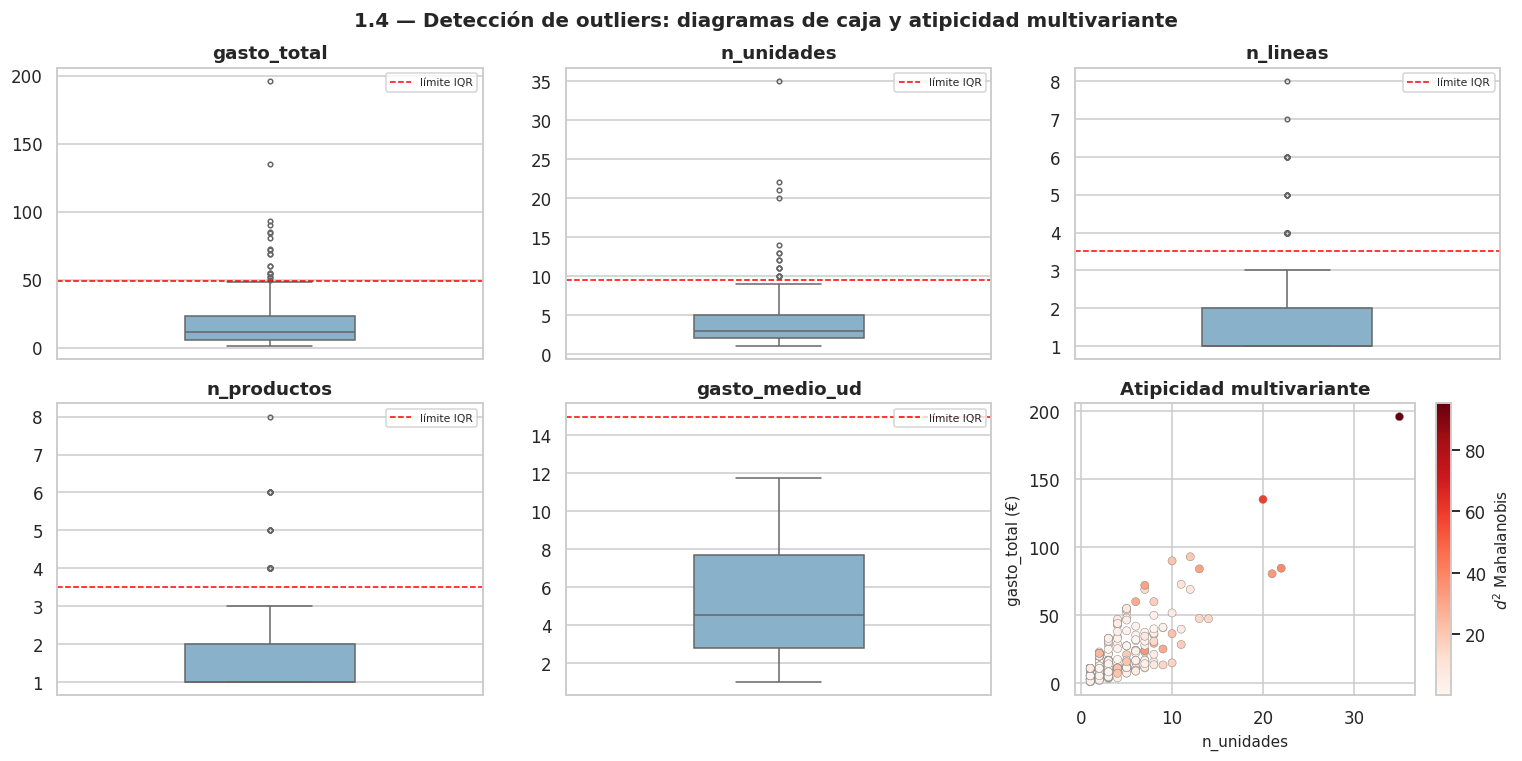

Composición real de los 5 tickets más altos (¿error de registro o cliente real?):

  Grupo 993 — 196.00 € | 35 uds | 4 negocio(s) | día 1 (Viernes)
     3xCroqueta, 2xFingers pollo casero + salsa Java, 3xVariado de ensaladillas, 8xBocadillos, 12xGranizado, 7xPizza

  Grupo 762 — 135.20 € | 20 uds | 2 negocio(s) | día 9 (Sábado)
     12xEnsaladilla, 2xCalamares a la plancha andaluza, 4xEnsaladilla, 2xEntrecote Premium

  Grupo 897 — 93.00 € | 12 uds | 3 negocio(s) | día 4 (Sábado)
     5xHamburguesa, 1xPatatas, 6xTarta

  Grupo 894 — 90.00 € | 10 uds | 2 negocio(s) | día 4 (Sábado)
     6xHamburguesa, 3xFingers pollo casero + salsa Java, 1xBocadillos

  Grupo 796 — 84.60 € | 22 uds | 1 negocio(s) | día 8 (Viernes)
     6xBocadillos, 2xEnsaladilla, 5xPatatas, 9xCroquetas


In [10]:
# =============================================================================
# 1.4.b VISUALIZACIÓN DE LOS OUTLIERS
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.ravel(), VARS_OUTLIER):
    sns.boxplot(y=clientes[c], ax=ax, color="#7fb3d5", width=0.4, fliersize=3)
    q1, q3 = clientes[c].quantile([.25, .75]); iqr = q3 - q1
    ax.axhline(q3 + 1.5 * iqr, color="red", ls="--", lw=1, label="límite IQR")
    ax.set_title(c); ax.set_ylabel("")
    ax.legend(fontsize=7, loc="upper right")
# Panel 6: dispersión gasto vs unidades, coloreada por Mahalanobis
ax = axes.ravel()[5]
sc = ax.scatter(clientes.n_unidades, clientes.gasto_total, c=clientes.d2_mahalanobis,
                cmap="Reds", s=28, edgecolor="grey", linewidth=.3)
ax.set_xlabel("n_unidades"); ax.set_ylabel("gasto_total (€)")
ax.set_title("Atipicidad multivariante")
plt.colorbar(sc, ax=ax, label="$d^2$ Mahalanobis")
fig.suptitle("1.4 — Detección de outliers: diagramas de caja y atipicidad multivariante",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# --- Inspección de negocio de los 5 tickets más altos --------------------------
print("Composición real de los 5 tickets más altos (¿error de registro o cliente real?):")
top5 = clientes.nlargest(5, "gasto_total").index
for g in top5:
    t = ventas[ventas.id_grupo == g]
    detalle = ", ".join(f"{r.cantidad}x{r.nombre}" for r in t.itertuples())
    print(f"\n  Grupo {g} — {t.importe.sum():.2f} € | {t.cantidad.sum()} uds | "
          f"{t.id_local.nunique()} negocio(s) | día {t.dia.iloc[0]} ({t['día_semana'].iloc[0]})")
    print(f"     {detalle}")

### Interpretación: por qué NO se eliminan los outliers

La regla del IQR marca **47 grupos (16,4 %)** como atípicos en al menos una variable. Eliminarlos sería un error metodológico grave en este caso concreto, por tres razones:

1. **No son errores, son clientes.** La inspección del detalle de los cinco tickets más altos muestra cestas perfectamente verosímiles: el grupo de 196 € compra 35 unidades repartidas en 4 negocios y 6 referencias distintas —es una mesa grande que cena en el recinto, exactamente el cliente que el negocio quiere identificar—. No hay cantidades imposibles ni precios anómalos.
2. **Son el segmento más rentable.** Esos 47 grupos concentran una parte desproporcionada de la facturación. Eliminarlos equivaldría a construir una segmentación que, por diseño, es ciega al cliente de mayor valor: justo lo contrario del objetivo del estudio.
3. **La asimetría es estructural, no accidental.** En hostelería la distribución del gasto es siempre log-normal o similar; la cola derecha no es contaminación, es la forma natural del fenómeno.

**Estrategia adoptada** (acorde con la práctica habitual en segmentación de clientes):

- **Winsorización al percentil 99** de las variables de conteo y monetarias: los valores por encima del p99 se recortan a ese percentil. El grupo extremo sigue estando en la muestra y sigue siendo el más caro de todos, pero deja de ejercer un apalancamiento desproporcionado sobre los centroides.
- **Transformación logarítmica `log1p`** del gasto: comprime la cola derecha y aproxima la variable a la normalidad, que es el supuesto implícito tanto de la distancia euclídea como del GMM. Se usa `log1p` (es decir, $\log(1+x)$) y no `log` para que el valor mínimo, 1 €, no genere problemas.

En la sección 4.5 se comprobará además, mediante DBSCAN, cuántos de estos grupos el propio algoritmo etiqueta como *ruido*: es una forma independiente de validar que la decisión de conservarlos no ha degradado la estructura.

Winsorización al percentil 99%:
   gasto_total    tope =    90.45  ->   3 valores recortados
   n_unidades     tope =    20.15  ->   3 valores recortados
   n_lineas       tope =     6.00  ->   2 valores recortados
   n_productos    tope =     6.00  ->   1 valores recortados

Efecto sobre la asimetría (skewness):
   gasto_total original .... 3.496
   gasto_total winsorizado . 1.940
   log1p(gasto winsorizado)  0.062   <-- casi simétrica


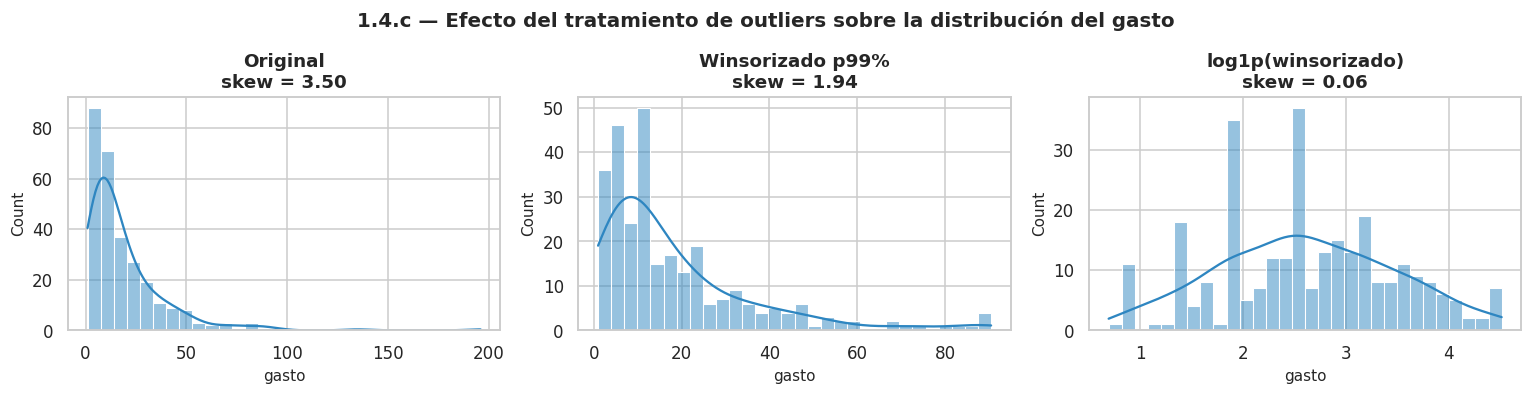

In [11]:
# =============================================================================
# 1.4.c TRATAMIENTO: WINSORIZACIÓN + TRANSFORMACIÓN LOGARÍTMICA
# =============================================================================
VARS_WINSOR = ["gasto_total", "n_unidades", "n_lineas", "n_productos"]

clientes_t = clientes.copy()
print(f"Winsorización al percentil {PERC_WINSOR:.0%}:")
for c in VARS_WINSOR:
    tope = clientes_t[c].quantile(PERC_WINSOR)
    n_rec = (clientes_t[c] > tope).sum()
    clientes_t[c] = clientes_t[c].clip(upper=tope)
    print(f"   {c:14s} tope = {tope:8.2f}  ->  {n_rec:2d} valores recortados")

# Transformación logarítmica de la variable monetaria (la más asimétrica)
clientes_t["log_gasto_total"] = np.log1p(clientes_t["gasto_total"])

print("\nEfecto sobre la asimetría (skewness):")
print(f"   gasto_total original .... {skew(clientes['gasto_total']):.3f}")
print(f"   gasto_total winsorizado . {skew(clientes_t['gasto_total']):.3f}")
print(f"   log1p(gasto winsorizado)  {skew(clientes_t['log_gasto_total']):.3f}   <-- casi simétrica")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, (serie, tit) in zip(axes, [(clientes["gasto_total"], "Original"),
                                   (clientes_t["gasto_total"], f"Winsorizado p{PERC_WINSOR:.0%}"),
                                   (clientes_t["log_gasto_total"], "log1p(winsorizado)")]):
    sns.histplot(serie, bins=30, kde=True, ax=ax, color="#2e86c1")
    ax.set_title(f"{tit}\nskew = {skew(serie):.2f}")
    ax.set_xlabel("gasto")
fig.suptitle("1.4.c — Efecto del tratamiento de outliers sobre la distribución del gasto",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

---
# 2. EXPLORACIÓN

Antes de seleccionar variables hay que entender su comportamiento: **qué distribución siguen** (2.1), **cómo evolucionan en el tiempo** (2.2), **cómo se relacionan entre sí** (2.3) y **si existe estructura de grupos visible** al proyectar los datos en dos dimensiones (2.4).

## 2.1. Análisis univariante

Para cada variable se examinan: histograma con estimación de densidad, tabla de percentiles, medidas de forma (asimetría y curtosis) y un contraste formal de normalidad (**Shapiro–Wilk**). El objetivo no es "aprobar" un test, sino saber si la hipótesis de normalidad —de la que dependen el GMM y, en menor medida, el PCA— es sostenible.

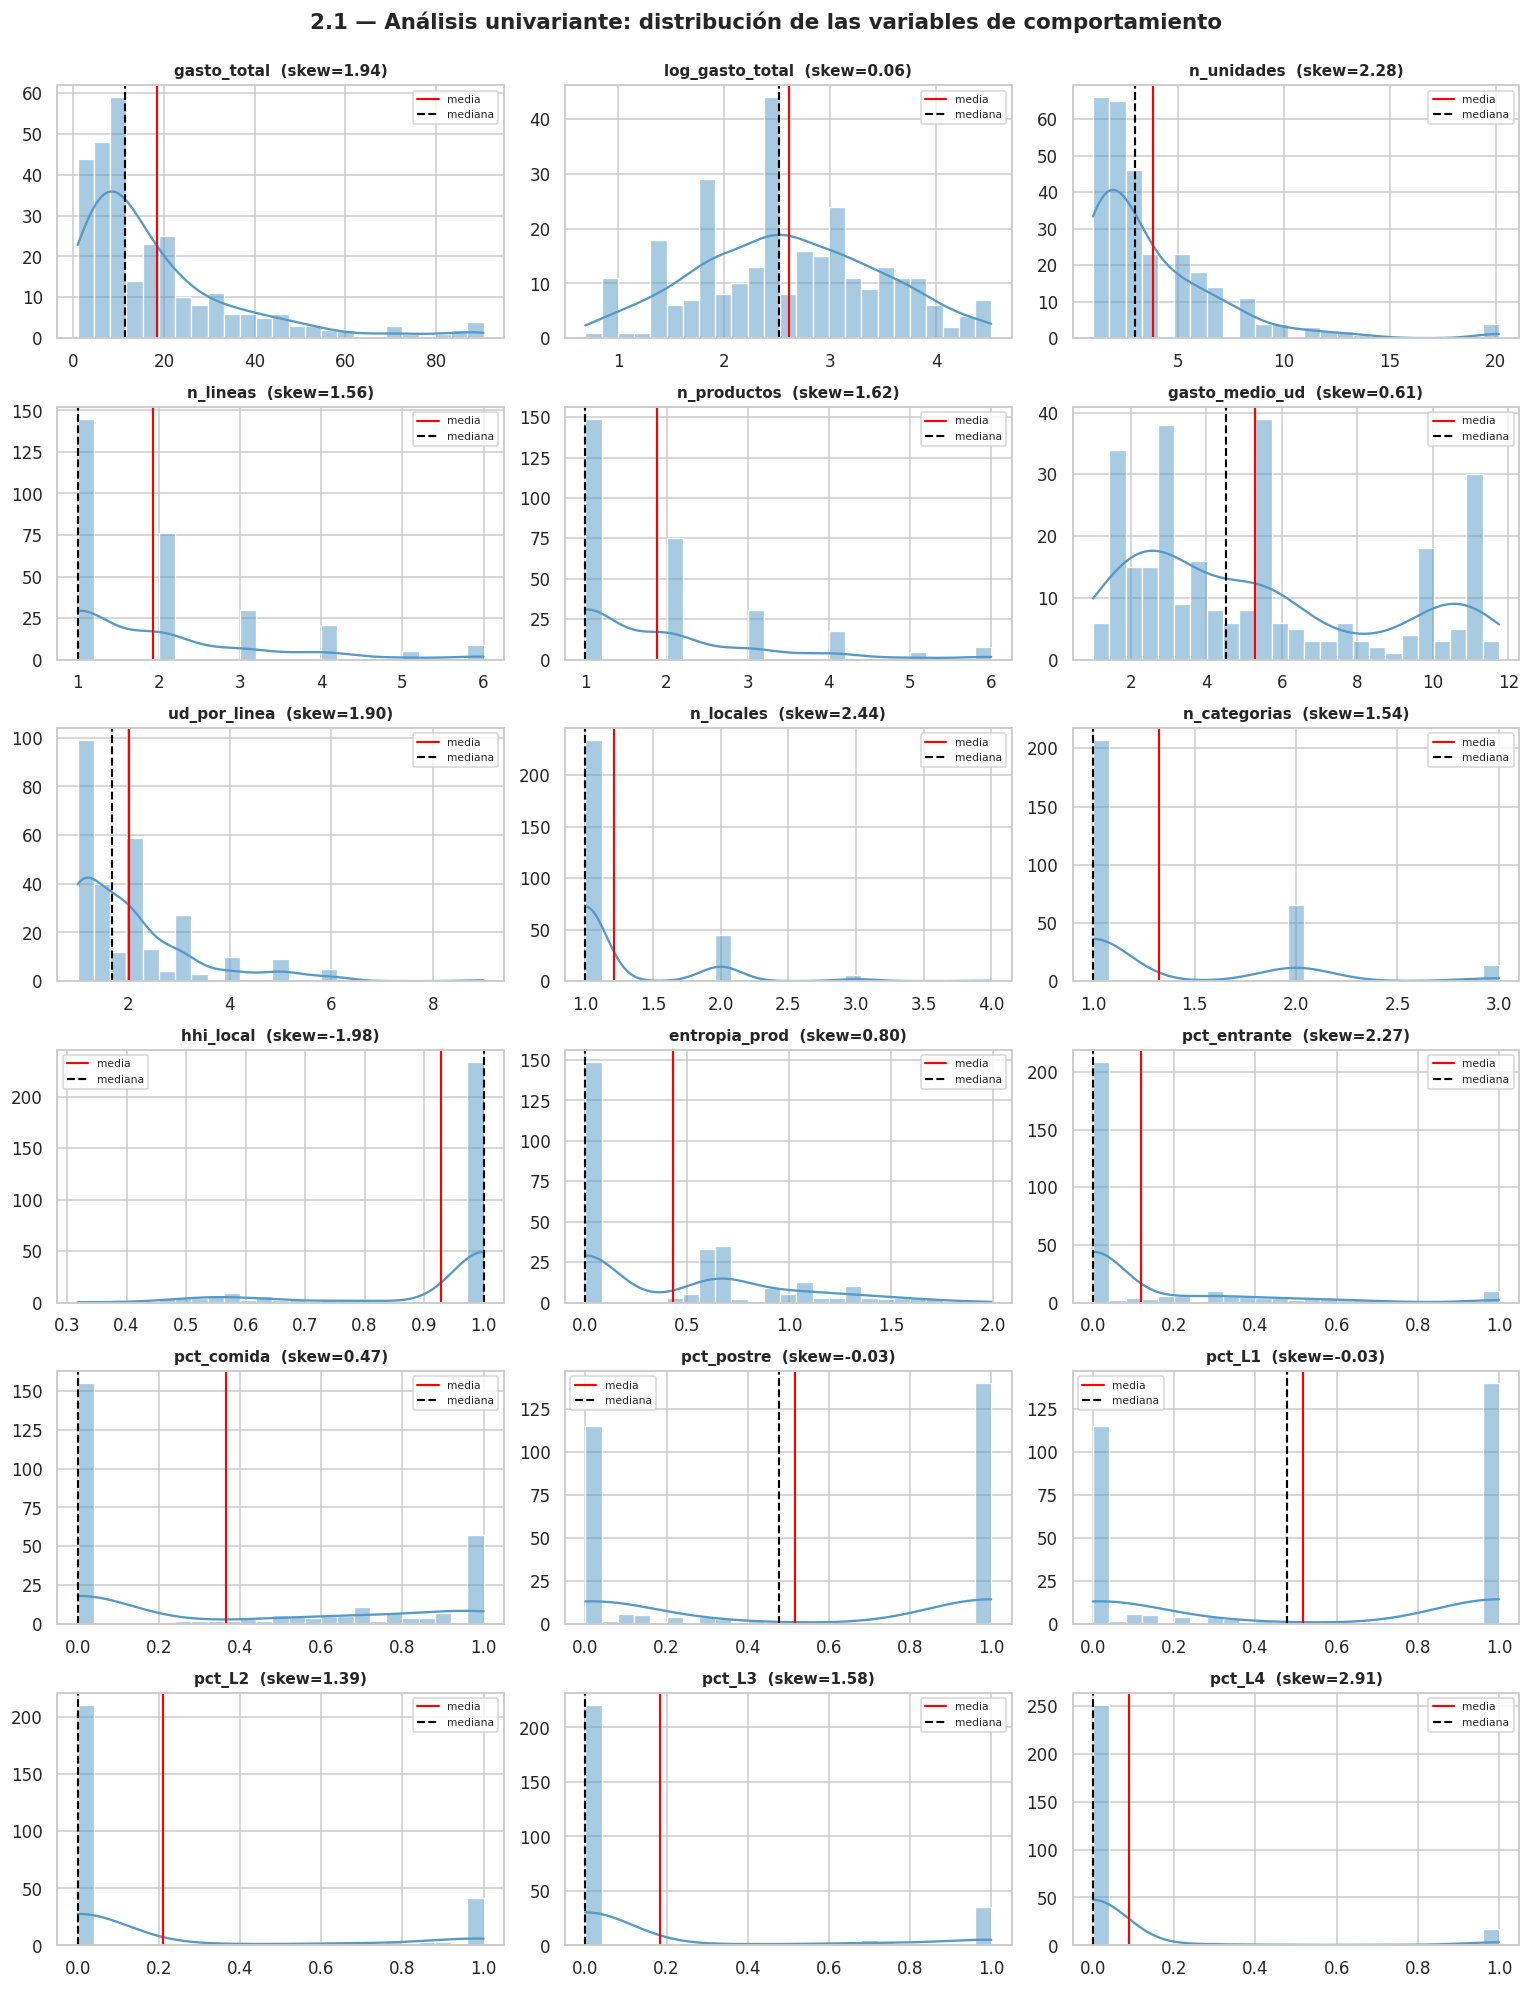

In [12]:
# =============================================================================
# 2.1.a HISTOGRAMAS DE TODAS LAS VARIABLES DE COMPORTAMIENTO
# =============================================================================
VARS_EXPLORA = ["gasto_total", "log_gasto_total", "n_unidades", "n_lineas", "n_productos",
                "gasto_medio_ud", "ud_por_linea", "n_locales", "n_categorias",
                "hhi_local", "entropia_prod", "pct_entrante", "pct_comida", "pct_postre",
                "pct_L1", "pct_L2", "pct_L3", "pct_L4"]

fig, axes = plt.subplots(6, 3, figsize=(14, 18))
for ax, c in zip(axes.ravel(), VARS_EXPLORA):
    sns.histplot(clientes_t[c], bins=25, kde=True, ax=ax, color="#5499c7", edgecolor="white")
    ax.axvline(clientes_t[c].mean(),   color="red",   ls="-",  lw=1.4, label="media")
    ax.axvline(clientes_t[c].median(), color="black", ls="--", lw=1.4, label="mediana")
    ax.set_title(f"{c}  (skew={skew(clientes_t[c]):.2f})", fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.legend(fontsize=7)
fig.suptitle("2.1 — Análisis univariante: distribución de las variables de comportamiento",
             fontsize=14, fontweight="bold", y=1.001)
plt.tight_layout(); plt.show()

In [13]:
# =============================================================================
# 2.1.b TABLA DE PERCENTILES, FORMA Y NORMALIDAD
# =============================================================================
filas = []
for c in VARS_EXPLORA:
    s = clientes_t[c]
    p = s.quantile([.01, .05, .25, .50, .75, .95, .99])
    W, pval = shapiro(s)
    filas.append(dict(variable=c, media=s.mean(), sd=s.std(),
                      p01=p[.01], p05=p[.05], p25=p[.25], mediana=p[.50],
                      p75=p[.75], p95=p[.95], p99=p[.99],
                      asimetría=skew(s), curtosis=kurtosis(s),
                      shapiro_W=W, shapiro_p=pval,
                      normal_5pct="SÍ" if pval > 0.05 else "NO",
                      n_valores_distintos=s.nunique()))
tabla_univ = pd.DataFrame(filas).set_index("variable")
display(tabla_univ.style.format({**{c: "{:.3f}" for c in tabla_univ.columns if c not in
                                    ["shapiro_p", "normal_5pct", "n_valores_distintos"]},
                                 "shapiro_p": "{:.2e}", "n_valores_distintos": "{:d}"})
        .background_gradient(cmap="RdYlGn_r", subset=["asimetría"])
        .background_gradient(cmap="Blues", subset=["n_valores_distintos"]))

,media,sd,p01,p05,p25,mediana,p75,p95,p99,asimetría,curtosis,shapiro_W,shapiro_p,normal_5pct,n_valores_distintos
variable,,,,,,,,,,,,,,,
gasto_total,18.524,18.146,1.500,2.800,5.600,11.400,22.975,54.750,90.067,1.940,4.001,0.784,3.87e-19,NO,126
log_gasto_total,2.608,0.862,0.916,1.335,1.887,2.518,3.177,4.021,4.512,0.062,-0.560,0.987,9.34e-03,NO,126
n_unidades,3.806,3.301,1.000,1.000,2.000,3.000,5.000,10.000,20.022,2.279,7.198,0.764,5.55e-20,NO,16
n_lineas,1.923,1.251,1.000,1.000,1.000,1.000,2.000,4.000,6.000,1.555,1.984,0.741,7.54e-21,NO,6
n_productos,1.878,1.215,1.000,1.000,1.000,1.000,2.000,4.000,6.000,1.623,2.313,0.732,3.52e-21,NO,6
gasto_medio_ud,5.288,3.287,1.142,1.500,2.800,4.529,7.665,11.000,11.075,0.607,-1.000,0.880,3.45e-14,NO,113
ud_por_linea,2.010,1.233,1.000,1.000,1.000,1.667,2.333,5.000,6.000,1.896,4.587,0.780,2.48e-19,NO,30
n_locales,1.210,0.479,1.000,1.000,1.000,1.000,1.000,2.000,3.000,2.436,6.374,0.483,4.95e-28,NO,4
n_categorias,1.325,0.564,1.000,1.000,1.000,1.000,2.000,2.000,3.000,1.538,1.373,0.598,2.83e-25,NO,3


### Interpretación del análisis univariante

**Ninguna de las 18 variables supera el contraste de normalidad de Shapiro–Wilk** (todos los p-valores por debajo de $10^{-13}$). Esto no es un defecto de los datos, sino la consecuencia de tres características estructurales:

1. **Variables de conteo con soporte muy pequeño.** `n_locales` toma 4 valores distintos, `n_categorias` sólo 3, `n_lineas` 8. Son variables discretas y truncadas por la izquierda en 1: por construcción no pueden ser normales. La consecuencia práctica es que su contribución a la distancia euclídea será *escalonada*, no continua.

2. **Fuerte asimetría positiva en las variables de volumen.** `gasto_total` presenta asimetría 3,50 y curtosis 19,8 antes del tratamiento; tras winsorizar y aplicar `log1p` la asimetría baja a valores próximos a 0, lo que justifica *a posteriori* la transformación de la sección 1.4.

3. **Distribuciones en forma de U en las variables de mix.** `pct_L1`, `pct_comida` o `pct_postre` acumulan masa en 0 y en 1, con muy pocos valores intermedios. Traducido a negocio: **un grupo o compra en la heladería o no compra en ella; casi nadie reparte su gasto a medias**. Estas variables se comportan casi como indicadores binarios, y son las que van a estructurar la segmentación.

Consecuencia metodológica: como no hay normalidad, el **GMM parte con desventaja** (sus supuestos no se cumplen) y el coeficiente de silueta —que es no paramétrico— es una métrica de validación más apropiada que cualquier criterio basado en verosimilitud. Es una primera pista de lo que se confirmará en la sección 4.5.

## 2.2. Gráficas de evolución temporal

Aunque el contexto temporal **no** va a entrar en el clústering (por decisión metodológica: se quieren perfiles de consumo puros, no perfiles de "tipo de día"), es imprescindible caracterizarlo, por dos motivos: para detectar tendencias o rupturas que invaliden el supuesto de homogeneidad de la muestra, y para poder interpretar después *cuándo* aparece cada clúster.

,dia,fecha,dia_semana,n_grupos,facturacion,ticket_medio,ticket_mediano,unidades,pct_multilocal
0,1,2026-05-22,Viernes,29,781.65,26.95,22.00,111.15,27.59
1,2,2026-05-23,Sábado,36,498.90,13.86,11.00,92.00,13.89
2,3,2026-05-29,Viernes,30,365.20,12.17,6.85,125.00,6.67
3,4,2026-05-30,Sábado,35,837.05,23.92,13.60,165.00,34.29
4,5,2026-05-31,Domingo,6,67.20,11.20,11.05,21.00,0.00
5,6,2026-06-05,Viernes,20,471.30,23.56,18.00,91.00,35.00
6,7,2026-06-06,Sábado,36,601.70,16.71,11.00,92.00,11.11
7,8,2026-06-12,Viernes,23,344.60,14.98,9.00,82.15,8.70
8,9,2026-06-13,Sábado,24,433.65,18.07,11.10,94.00,12.50
9,10,2026-06-14,Domingo,13,222.70,17.13,15.90,62.00,7.69


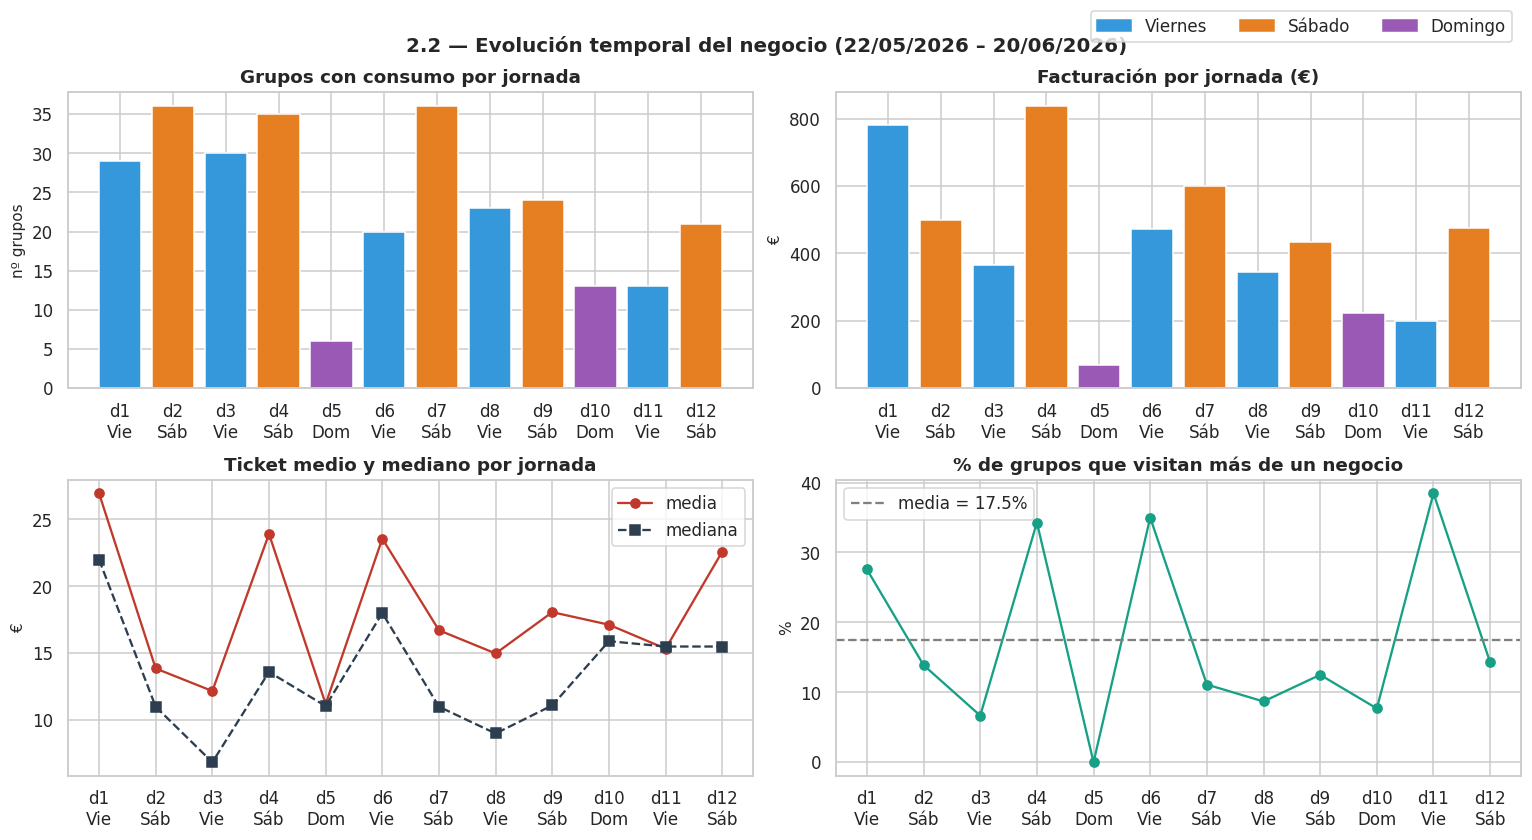

In [14]:
# =============================================================================
# 2.2.a SERIES TEMPORALES AGREGADAS POR JORNADA
# =============================================================================
diario = (clientes_t.groupby(["dia", "fecha", "dia_semana"], as_index=False)
          .agg(n_grupos=("gasto_total", "size"),
               facturacion=("gasto_total", "sum"),
               ticket_medio=("gasto_total", "mean"),
               ticket_mediano=("gasto_total", "median"),
               unidades=("n_unidades", "sum"),
               pct_multilocal=("n_locales", lambda s: (s > 1).mean() * 100))
          .sort_values("dia"))
display(diario.round(2))

fig, axes = plt.subplots(2, 2, figsize=(14, 7.5))
etq = [f"d{d}\n{ds[:3]}" for d, ds in zip(diario.dia, diario.dia_semana)]
colores_ds = {"Viernes": "#3498db", "Sábado": "#e67e22", "Domingo": "#9b59b6"}
cols = [colores_ds[d] for d in diario.dia_semana]

axes[0, 0].bar(etq, diario.n_grupos, color=cols)
axes[0, 0].set_title("Grupos con consumo por jornada"); axes[0, 0].set_ylabel("nº grupos")
axes[0, 1].bar(etq, diario.facturacion, color=cols)
axes[0, 1].set_title("Facturación por jornada (€)"); axes[0, 1].set_ylabel("€")
axes[1, 0].plot(etq, diario.ticket_medio, "o-", color="#c0392b", label="media")
axes[1, 0].plot(etq, diario.ticket_mediano, "s--", color="#2c3e50", label="mediana")
axes[1, 0].set_title("Ticket medio y mediano por jornada"); axes[1, 0].set_ylabel("€"); axes[1, 0].legend()
axes[1, 1].plot(etq, diario.pct_multilocal, "o-", color="#16a085")
axes[1, 1].axhline(diario.pct_multilocal.mean(), ls="--", color="grey",
                   label=f"media = {diario.pct_multilocal.mean():.1f}%")
axes[1, 1].set_title("% de grupos que visitan más de un negocio"); axes[1, 1].set_ylabel("%"); axes[1, 1].legend()
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=v, label=k) for k, v in colores_ds.items()],
           loc="upper right", ncol=3, frameon=True, bbox_to_anchor=(0.99, 1.02))
fig.suptitle("2.2 — Evolución temporal del negocio (22/05/2026 – 20/06/2026)",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

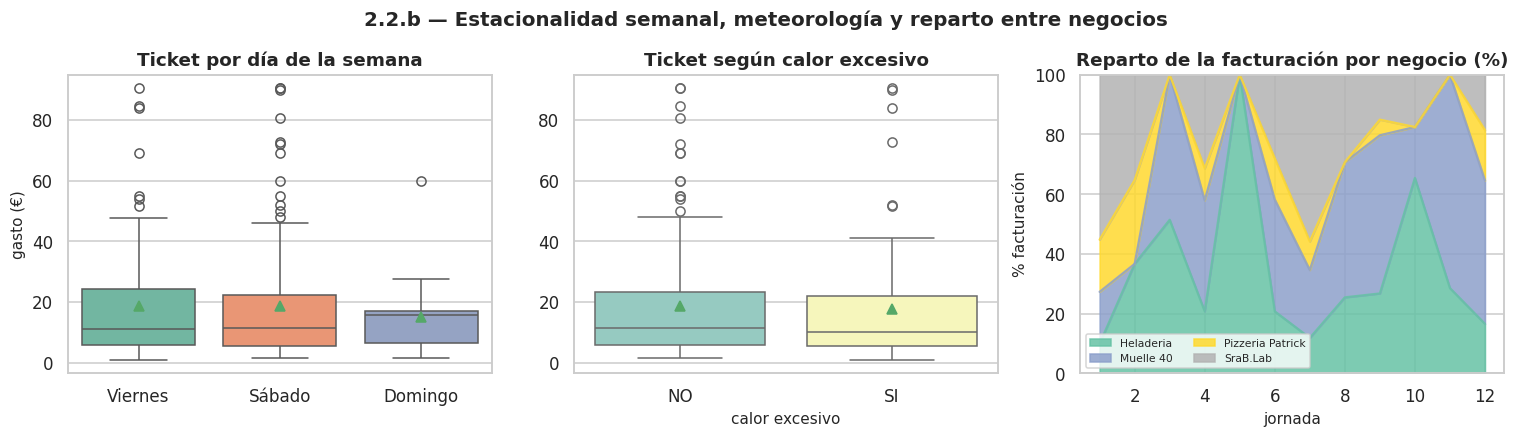

Kruskal-Wallis (ticket ~ día de la semana): H = 0.056, p = 0.9723  ->  SIN diferencias significativas al 5 %
Kruskal-Wallis (ticket ~ calor excesivo)  : H = 2.039, p = 0.1533  ->  SIN diferencias significativas al 5 %


In [15]:
# =============================================================================
# 2.2.b ESTACIONALIDAD SEMANAL Y EFECTO DE LAS VARIABLES METEOROLÓGICAS
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
orden_ds = ["Viernes", "Sábado", "Domingo"]

sns.boxplot(data=clientes_t, x="dia_semana", y="gasto_total", order=orden_ds,
            ax=axes[0], palette="Set2", showmeans=True)
axes[0].set_title("Ticket por día de la semana"); axes[0].set_xlabel(""); axes[0].set_ylabel("gasto (€)")

sns.boxplot(data=clientes_t, x="calor", y="gasto_total", order=["NO", "SÍ"] if "SÍ" in clientes_t.calor.unique() else None,
            ax=axes[1], palette="Set3", showmeans=True)
axes[1].set_title("Ticket según calor excesivo"); axes[1].set_xlabel("calor excesivo"); axes[1].set_ylabel("")

reparto = (ventas.groupby(["dia", "nombre_local"]).importe.sum().unstack(fill_value=0))
reparto_pct = reparto.div(reparto.sum(axis=1), axis=0) * 100
reparto_pct.plot(kind="area", stacked=True, ax=axes[2], colormap="Set2", alpha=.85, legend=False)
axes[2].set_title("Reparto de la facturación por negocio (%)")
axes[2].set_xlabel("jornada"); axes[2].set_ylabel("% facturación"); axes[2].set_ylim(0, 100)
axes[2].legend(fontsize=7, loc="lower left", ncol=2)
fig.suptitle("2.2.b — Estacionalidad semanal, meteorología y reparto entre negocios",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# --- Contraste no paramétrico: ¿difiere el ticket según el día de la semana? ---
grupos_ds = [clientes_t.loc[clientes_t.dia_semana == d, "gasto_total"].values for d in orden_ds]
H, p = kruskal(*grupos_ds)
print(f"Kruskal-Wallis (ticket ~ día de la semana): H = {H:.3f}, p = {p:.4f}"
      f"  ->  {'diferencias significativas' if p < 0.05 else 'SIN diferencias significativas'} al 5 %")
g_calor = [clientes_t.loc[clientes_t.calor == v, "gasto_total"].values for v in clientes_t.calor.unique()]
H2, p2 = kruskal(*g_calor)
print(f"Kruskal-Wallis (ticket ~ calor excesivo)  : H = {H2:.3f}, p = {p2:.4f}"
      f"  ->  {'diferencias significativas' if p2 < 0.05 else 'SIN diferencias significativas'} al 5 %")

### Interpretación de la evolución temporal

- **La serie es corta y con un hueco.** Doce jornadas (viernes, sábados y domingos entre el 22/05 y el 20/06/2026), con el día 5 (domingo 31/05) claramente infrarregistrado tal y como detectó la auditoría. Con esta longitud **no cabe hablar de tendencia ni de estacionalidad anual**; sólo de estacionalidad *intrasemanal*.
- **El sábado es el día fuerte** en número de grupos y facturación, seguido del viernes; el domingo es residual. Ahora bien, el contraste de Kruskal-Wallis indica si esa diferencia se traslada al **ticket individual** o si sólo se debe a que hay más gente: son dos cosas distintas, y la distinción es relevante para el negocio (más afluencia no es lo mismo que clientes que gastan más).
- **El reparto entre negocios es inestable de una jornada a otra.** El área apilada muestra que el peso de cada local oscila notablemente, lo que sugiere que la composición de clientes cambia entre jornadas —precisamente lo que la segmentación va a permitir cuantificar.
- **El porcentaje de grupos que visitan más de un negocio se mantiene bajo y estable** en torno al 18 %. No es un efecto puntual de una jornada concreta: es el comportamiento estructural del recinto.

**Nota metodológica importante:** todas estas variables (día de la semana, calor, lluvia, jornada) se han excluido deliberadamente del conjunto de clústering. Si se incluyeran, los algoritmos formarían grupos del tipo "sábado caluroso" en lugar de "cliente que cena hamburguesa", mezclando el *cuándo* con el *quién*. Se reservan como **variables externas de validación**: en la sección 5 se comprobará si los clústeres obtenidos sólo con comportamiento de compra se distribuyen o no de forma homogénea en el tiempo, lo que constituye una validación independiente de la segmentación.

## 2.3. Análisis de correlaciones

Se calculan las matrices de correlación de **Pearson** (relación lineal) y de **Spearman** (relación monótona, robusta frente a la asimetría que ya se ha documentado). Se buscan dos cosas:

- **Redundancia**: pares con $|r| > 0{,}80$, que aportarían la misma información dos veces y, al estandarizar, darían un peso doble a esa dimensión en la distancia euclídea.
- **Colinealidad exacta**: variables que son combinación lineal de otras, lo que degrada el PCA y hace singular la matriz de covarianzas del GMM.

Se completa con el **VIF** (*Variance Inflation Factor*), que mide cuánta de la varianza de cada variable es explicable por el resto: $VIF > 10$ es la señal convencional de multicolinealidad severa.

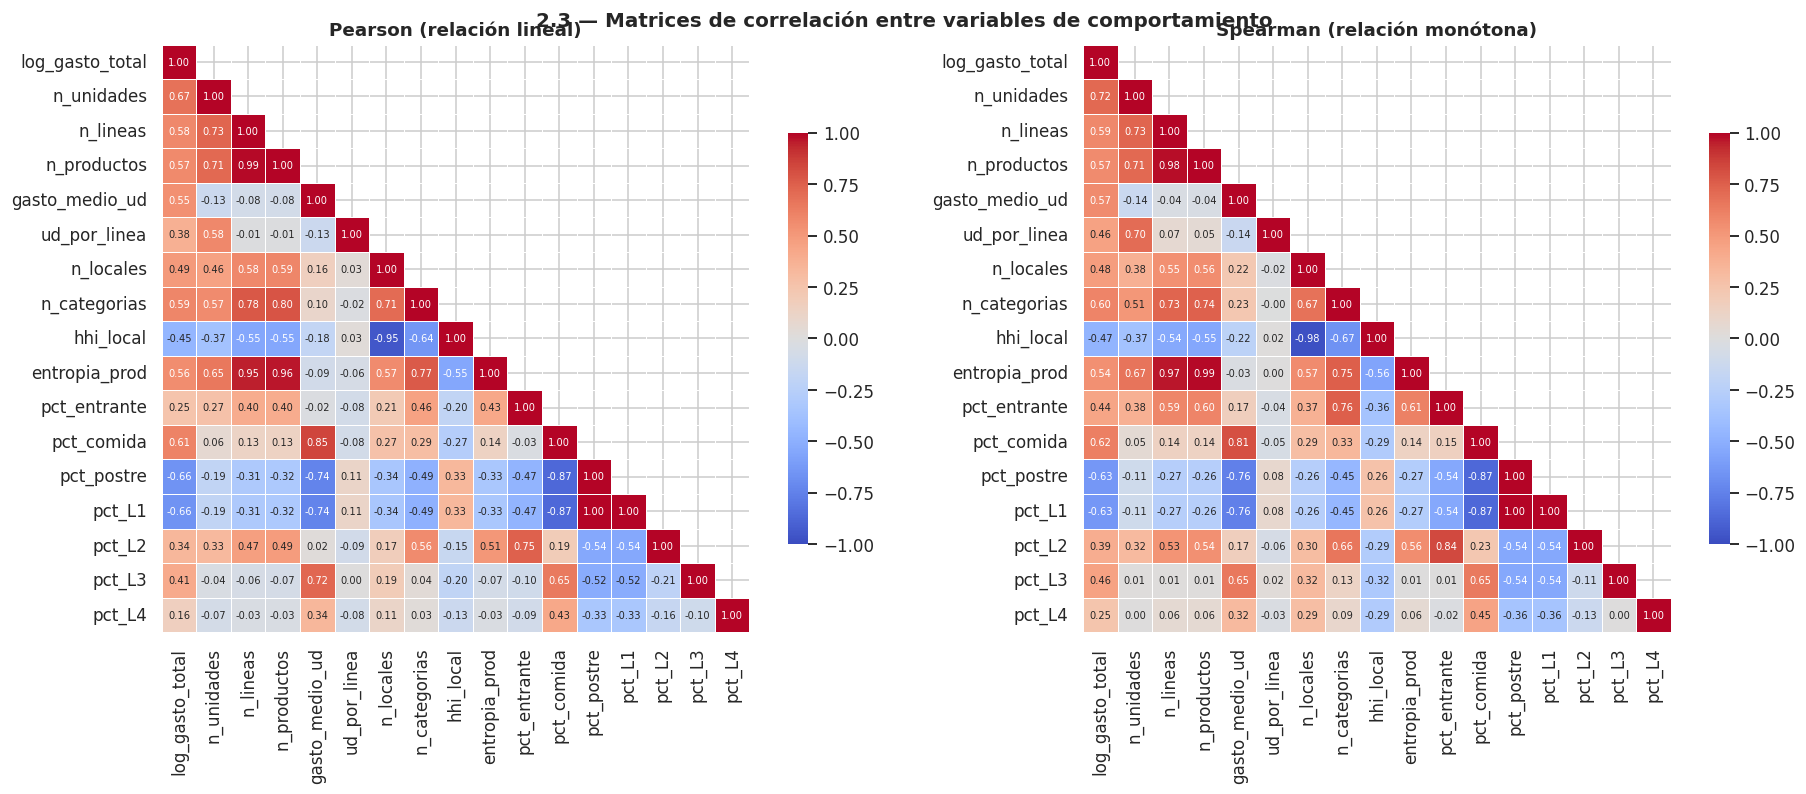

In [16]:
# =============================================================================
# 2.3.a MATRICES DE CORRELACIÓN DE PEARSON Y SPEARMAN
# =============================================================================
VARS_CORR = [v for v in VARS_EXPLORA if v != "gasto_total"]   # se usa la versión log del gasto
corr_p = clientes_t[VARS_CORR].corr(method="pearson")
corr_s = clientes_t[VARS_CORR].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
mascara = np.triu(np.ones_like(corr_p, dtype=bool), k=1)
for ax, M, tit in [(axes[0], corr_p, "Pearson (relación lineal)"),
                   (axes[1], corr_s, "Spearman (relación monótona)")]:
    sns.heatmap(M, mask=mascara, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                vmin=-1, vmax=1, square=True, linewidths=.4, ax=ax,
                cbar_kws={"shrink": .7}, annot_kws={"size": 6.5})
    ax.set_title(tit)
fig.suptitle("2.3 — Matrices de correlación entre variables de comportamiento",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

In [17]:
# =============================================================================
# 2.3.b PARES REDUNDANTES Y FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
# =============================================================================
import itertools
UMBRAL_RED = 0.80
print(f"PARES CON |correlación| > {UMBRAL_RED}  (candidatos a eliminación por redundancia)")
print("-" * 78)
print(f"{'variable A':16s} {'variable B':16s} {'Pearson':>9s} {'Spearman':>9s}")
print("-" * 78)
pares_red = []
for a, b in itertools.combinations(VARS_CORR, 2):
    rp, rs = corr_p.loc[a, b], corr_s.loc[a, b]
    if abs(rp) > UMBRAL_RED or abs(rs) > UMBRAL_RED:
        marca = "  <<< COLINEALIDAD EXACTA" if abs(rp) > 0.999 else ""
        print(f"{a:16s} {b:16s} {rp:+9.3f} {rs:+9.3f}{marca}")
        pares_red.append((a, b, rp, rs))
print("-" * 78)
print(f"Total de pares redundantes detectados: {len(pares_red)}")

# --- VIF: cuánta varianza de cada variable explican las demás ------------------
from sklearn.linear_model import LinearRegression
print("\nFACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("-" * 46)
Xv = clientes_t[VARS_CORR].values
vifs = []
for i, v in enumerate(VARS_CORR):
    otras = np.delete(Xv, i, axis=1)
    r2 = LinearRegression().fit(otras, Xv[:, i]).score(otras, Xv[:, i])
    vif = np.inf if r2 > 0.9999 else 1 / (1 - r2)
    vifs.append(dict(variable=v, R2=r2, VIF=vif))
tabla_vif = pd.DataFrame(vifs).sort_values("VIF", ascending=False)
display(tabla_vif.style.format({"R2": "{:.4f}", "VIF": "{:.1f}"})
        .background_gradient(cmap="Reds", subset=["VIF"]))

PARES CON |correlación| > 0.8  (candidatos a eliminación por redundancia)
------------------------------------------------------------------------------
variable A       variable B         Pearson  Spearman
------------------------------------------------------------------------------
n_lineas         n_productos         +0.986    +0.982
n_lineas         entropia_prod       +0.947    +0.968
n_productos      entropia_prod       +0.962    +0.989
gasto_medio_ud   pct_comida          +0.848    +0.808
n_locales        hhi_local           -0.947    -0.980
pct_entrante     pct_L2              +0.749    +0.835
pct_comida       pct_postre          -0.868    -0.873
pct_comida       pct_L1              -0.868    -0.873
pct_postre       pct_L1              +1.000    +1.000  <<< COLINEALIDAD EXACTA
------------------------------------------------------------------------------
Total de pares redundantes detectados: 9

FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
-----------------------------------------

,variable,R2,VIF
13,pct_L1,1.0000,inf
11,pct_comida,1.0000,inf
16,pct_L4,1.0000,inf
14,pct_L2,1.0000,inf
15,pct_L3,1.0000,inf
10,pct_entrante,1.0000,inf
12,pct_postre,1.0000,inf
3,n_productos,0.9846,65.1
2,n_lineas,0.9805,51.4
9,entropia_prod,0.9536,21.6


### Interpretación de las correlaciones

El análisis identifica **cuatro bloques de redundancia** que hay que resolver antes de clusterizar:

1. **`pct_postre` ≡ `pct_L1` con $r = 1{,}000$ exactamente.** No es una casualidad estadística sino una **identidad estructural del catálogo**: la Heladería (local 1) es el único negocio que vende productos de categoría `Postre`, y todos sus productos son postres. Ambas variables son literalmente la misma columna con dos nombres. Mantener las dos duplicaría el peso de esa dimensión en la distancia euclídea y haría **singular** la matriz de covarianzas (VIF infinito). Se conserva `pct_L1`, porque la lectura por negocio es la accionable para el gestor del recinto.

2. **`n_lineas` ≈ `n_productos` ≈ `entropia_prod`** ($r \approx 0{,}94$–$0{,}99$). Las tres miden lo mismo —la variedad de la cesta— desde ángulos distintos. Como el 50 % de los grupos tiene una sola línea, la entropía de Shannon degenera a 0 para la mitad de la muestra y no aporta la resolución adicional que se esperaba. Se conserva `n_productos`, que es la más directamente interpretable ("cuántas referencias distintas pidió el grupo").

3. **`n_locales` ≈ `hhi_local`** ($r = -0{,}95$). El índice de Herfindahl es una versión continua del número de locales visitados; con sólo 4 negocios en el recinto no aporta granularidad extra. Se conserva `n_locales`.

4. **`ud_entrante` ≈ `pct_entrante`, `ud_comida` ≈ `pct_comida`, `ud_postre` ≈ `pct_postre`** ($\rho > 0{,}83$). Las versiones en porcentaje son preferibles porque están **normalizadas por el tamaño del ticket**: separan el *qué compra* del *cuánto compra*, evitando que la dimensión "volumen" se cuele por partida doble.

Adicionalmente, el VIF confirma la existencia de una **restricción composicional**: `pct_L1 + pct_L2 + pct_L3 + pct_L4 = 1` por construcción (y análogamente con las tres categorías). Esto significa que el conjunto de variables de mix tiene rango $p-1$, no $p$. Es una limitación conocida de los datos composicionales; se asumirá de forma explícita y controlada, y en la sección 3.3 se comprobará que el PCA la detecta correctamente devolviendo una componente de varianza exactamente nula.

## 2.4. Visualización mediante reducción de dimensionalidad

Antes de aplicar ningún algoritmo conviene responder a una pregunta previa: **¿hay estructura de grupos en estos datos?** Proyectar el espacio multidimensional sobre un plano permite verlo. Se emplean tres técnicas complementarias:

| Técnica | Naturaleza | Qué preserva | Para qué sirve aquí |
|---|---|---|---|
| **PCA** | Lineal | La **varianza global** y las distancias grandes | Ver la estructura macro y poder interpretar los ejes |
| **t-SNE** | No lineal | La **vecindad local** | Revelar agrupaciones compactas que el PCA aplasta |
| **MDS** | No lineal (métrica) | La **matriz de distancias** completa | Contraste independiente del t-SNE |

Es fundamental subrayar que esta proyección se hace **sólo para explorar**: el clústering se ejecutará sobre el espacio completo, no sobre estas dos dimensiones.

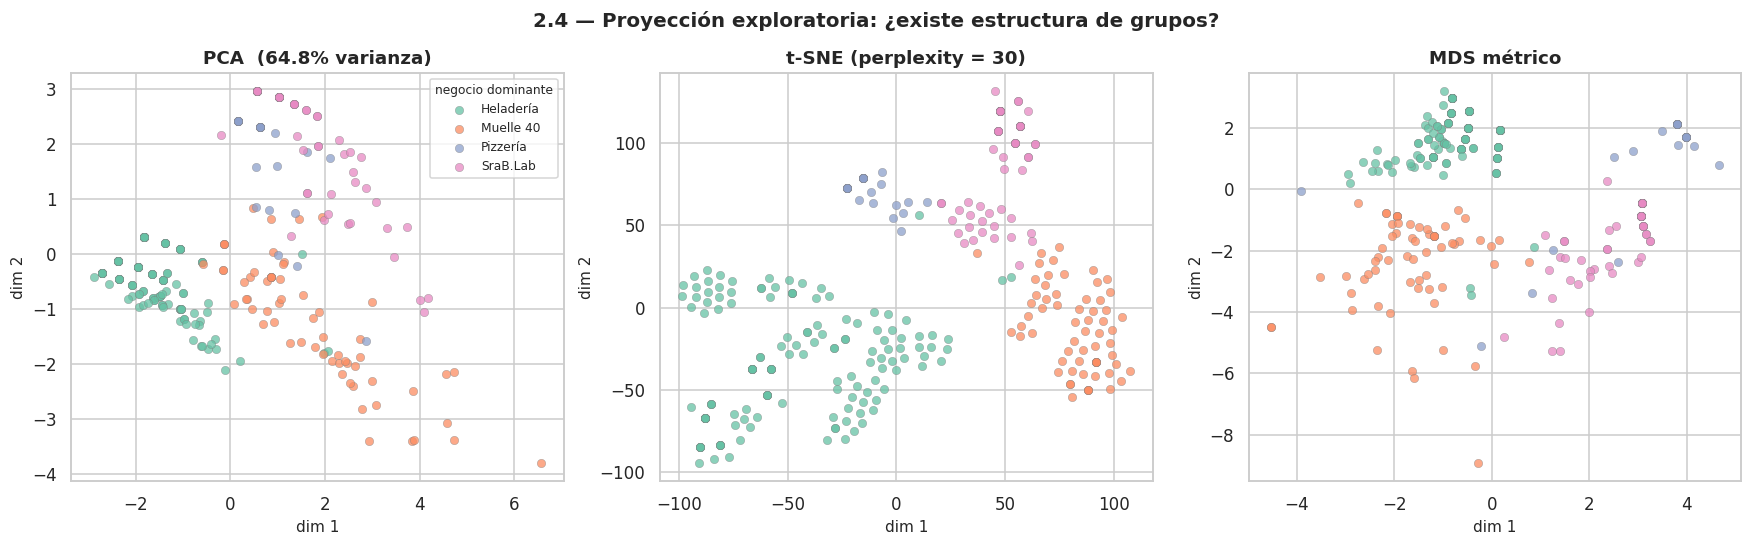

Varianza explicada por las 2 primeras componentes principales: 39.9% + 24.9% = 64.8%


In [18]:
# =============================================================================
# 2.4 PROYECCIÓN EXPLORATORIA EN 2D (PCA / t-SNE / MDS)
# =============================================================================
# Conjunto amplio provisional: sirve sólo para explorar si hay estructura
VARS_EXPLORA_2D = ["log_gasto_total", "n_unidades", "n_productos", "gasto_medio_ud",
                   "n_locales", "pct_L1", "pct_L2", "pct_L3", "pct_L4"]
Z_expl = StandardScaler().fit_transform(clientes_t[VARS_EXPLORA_2D])

pca_expl = PCA(n_components=2, random_state=SEMILLA)
P_pca  = pca_expl.fit_transform(Z_expl)
P_tsne = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto",
              random_state=SEMILLA).fit_transform(Z_expl)
P_mds  = MDS(n_components=2, random_state=SEMILLA, normalized_stress="auto",
             n_init=4).fit_transform(Z_expl)

# Se colorea por negocio dominante (variable NO usada para proyectar: sirve de validación visual)
dominante = clientes_t[["pct_L1", "pct_L2", "pct_L3", "pct_L4"]].idxmax(axis=1).map(
    {"pct_L1": "Heladería", "pct_L2": "Muelle 40", "pct_L3": "SraB.Lab", "pct_L4": "Pizzería"})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, P, tit in [(axes[0], P_pca,  f"PCA  ({pca_expl.explained_variance_ratio_.sum():.1%} varianza)"),
                   (axes[1], P_tsne, "t-SNE (perplexity = 30)"),
                   (axes[2], P_mds,  "MDS métrico")]:
    for i, (cat, sub) in enumerate(pd.DataFrame(P, index=clientes_t.index,
                                                columns=["x", "y"]).groupby(dominante)):
        ax.scatter(sub.x, sub.y, s=30, alpha=.75, label=cat,
                   color=plt.get_cmap("Set2")(i), edgecolor="grey", linewidth=.3)
    ax.set_title(tit); ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
axes[0].legend(title="negocio dominante", fontsize=8, title_fontsize=8)
fig.suptitle("2.4 — Proyección exploratoria: ¿existe estructura de grupos?",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("Varianza explicada por las 2 primeras componentes principales: "
      f"{pca_expl.explained_variance_ratio_[0]:.1%} + {pca_expl.explained_variance_ratio_[1]:.1%} "
      f"= {pca_expl.explained_variance_ratio_.sum():.1%}")

### Interpretación de la proyección

Las tres técnicas coinciden en lo esencial y esa coincidencia es en sí misma un resultado: **sí hay estructura, y esa estructura está organizada por negocio de referencia**. El color —el negocio donde el grupo concentra su gasto— no se ha usado para calcular ninguna de las tres proyecciones, y sin embargo separa los puntos con nitidez. Es una validación visual previa muy fuerte: los algoritmos de clústering deberían recuperar esta organización.

Se aprecian además tres matices:

- **El t-SNE muestra agrupaciones muy compactas y separadas**, más que el PCA. Esto es coherente con lo visto en 2.1: al haber muchas variables casi binarias y de conteo, muchos grupos comparten **exactamente el mismo vector de características**. En concreto, en el espacio final habrá un número elevado de filas duplicadas —tickets mínimos de un solo producto en un solo negocio—, que el t-SNE dibuja como nubes densísimas.
- **Dentro de cada negocio se distingue un gradiente**, no una nube homogénea: los grupos se ordenan por volumen de gasto. Esto anticipa que el número óptimo de clústeres será mayor que 4 (el número de negocios), porque al menos uno de ellos se dividirá por nivel de consumo.
- **Los puntos que quedan entre nubes son los grupos multi-negocio**, esos 18 % que sí circulan por el recinto. Son pocos y ocupan posiciones intermedias, lo que hace prever que serán el clúster más difícil de aislar y, a la vez, el más interesante para el negocio.

---
# 3. CARACTERÍSTICAS

## 3.1. Selección de variables

La selección se realiza aplicando **cuatro criterios en cascada** sobre las 20 variables construidas en 1.3:

1. **Relevancia conceptual**: la variable debe describir *comportamiento de compra*, no contexto ni identificadores.
2. **Variabilidad suficiente**: se descartan variables con varianza cercana a cero, que no separan nada.
3. **No redundancia**: de cada bloque de variables con $|r| > 0{,}80$ se conserva una sola (la más interpretable).
4. **Interpretabilidad de negocio**: entre dos variables estadísticamente equivalentes, se prefiere la que el gestor del local pueda leer sin traducción.

In [19]:
# =============================================================================
# 3.1 SELECCIÓN DE VARIABLES — TRAZABILIDAD DE LAS DECISIONES
# =============================================================================
decisiones = pd.DataFrame([
    # variable,            decisión,   motivo
    ("gasto_total",      "TRANSFORMA", "Muy asimétrica (skew 3.5); se sustituye por log_gasto_total"),
    ("log_gasto_total",  "SELECCIONA", "Volumen económico. Eje principal de valor del cliente"),
    ("n_unidades",       "SELECCIONA", "Volumen físico. Único proxy disponible del tamaño del grupo"),
    ("n_lineas",         "DESCARTA",   "Redundante con n_productos (r = 0.99)"),
    ("n_productos",      "SELECCIONA", "Variedad de la cesta. Más interpretable que la entropía"),
    ("gasto_medio_ud",   "SELECCIONA", "Gama de producto (€/unidad). Separa helado de entrecot"),
    ("ud_por_linea",     "DESCARTA",   "Combinación de n_unidades y n_lineas; no aporta dimensión nueva"),
    ("n_locales",        "SELECCIONA", "Itinerancia por el recinto. Variable clave del objetivo del TFM"),
    ("n_categorias",     "DESCARTA",   "Muy correlada con el mix pct_*; sólo 3 valores posibles"),
    ("hhi_local",        "DESCARTA",   "Redundante con n_locales (r = -0.95)"),
    ("entropia_prod",    "DESCARTA",   "Redundante con n_productos (r = 0.96); degenera a 0 en el 50% de casos"),
    ("pct_entrante",     "DESCARTA",   "Redundante con ud_entrante y con el mix por local"),
    ("pct_comida",       "DESCARTA",   "Muy correlada con gasto_medio_ud (r = 0.85)"),
    ("pct_postre",       "DESCARTA",   "IDÉNTICA a pct_L1 (r = 1.000): la Heladería es el único vendedor de postre"),
    ("pct_L1",           "SELECCIONA", "Peso de la Heladería en el gasto"),
    ("pct_L2",           "SELECCIONA", "Peso del Muelle 40 (bar y variados) en el gasto"),
    ("pct_L3",           "SELECCIONA", "Peso de SraB.Lab (hamburguesería) en el gasto"),
    ("pct_L4",           "SELECCIONA", "Peso de la Pizzería Patrick en el gasto"),
    ("ud_entrante",      "DESCARTA",   "Versión no normalizada de pct_entrante"),
    ("ud_comida",        "DESCARTA",   "Versión no normalizada de pct_comida"),
    ("ud_postre",        "DESCARTA",   "Versión no normalizada de pct_postre"),
], columns=["variable", "decisión", "motivo"])

def color_dec(v):
    return {"SELECCIONA": "background-color:#d5f5e3", "DESCARTA": "background-color:#fadbd8",
            "TRANSFORMA": "background-color:#fdebd0"}.get(v, "")
display(decisiones.style.map(color_dec, subset=["decisión"]).hide(axis="index"))

# ---------------- CONJUNTO FINAL DE VARIABLES DE CLÚSTERING -------------------
VARS_CLUSTER = ["log_gasto_total", "n_unidades", "n_productos", "gasto_medio_ud",
                "n_locales", "pct_L1", "pct_L2", "pct_L3", "pct_L4"]

X = clientes_t[VARS_CLUSTER].copy()
print(f"\nMATRIZ FINAL DE CLÚSTERING: {X.shape[0]} visitas x {X.shape[1]} variables")
print(f"Variables: {VARS_CLUSTER}")

# --- Diagnóstico: filas idénticas en el espacio de características -------------
n_dup = X.duplicated().sum()
print(f"\nFilas exactamente duplicadas en el espacio de características: "
      f"{n_dup} de {len(X)} ({n_dup/len(X):.1%})  ->  {len(X)-n_dup} vectores distintos")
print("   (son tickets mínimos idénticos: mismo negocio, mismo importe, mismas unidades)")

# --- Comprobación de la restricción composicional ------------------------------
suma_mix = X[["pct_L1", "pct_L2", "pct_L3", "pct_L4"]].sum(axis=1)
print(f"\nComprobación composicional: pct_L1+pct_L2+pct_L3+pct_L4 = "
      f"{suma_mix.min():.6f} (mín) a {suma_mix.max():.6f} (máx)  ->  suma constante = 1")
print("   Consecuencia: el rango efectivo de la matriz es 8, no 9. El PCA lo confirmará en 3.3.")
display(X.describe().T.round(3))

variable,decisión,motivo
gasto_total,TRANSFORMA,Muy asimétrica (skew 3.5); se sustituye por log_gasto_total
log_gasto_total,SELECCIONA,Volumen económico. Eje principal de valor del cliente
n_unidades,SELECCIONA,Volumen físico. Único proxy disponible del tamaño del grupo
n_lineas,DESCARTA,Redundante con n_productos (r = 0.99)
n_productos,SELECCIONA,Variedad de la cesta. Más interpretable que la entropía
gasto_medio_ud,SELECCIONA,Gama de producto (€/unidad). Separa helado de entrecot
ud_por_linea,DESCARTA,Combinación de n_unidades y n_lineas; no aporta dimensión nueva
n_locales,SELECCIONA,Itinerancia por el recinto. Variable clave del objetivo del TFM
n_categorias,DESCARTA,Muy correlada con el mix pct_*; sólo 3 valores posibles
hhi_local,DESCARTA,Redundante con n_locales (r = -0.95)



MATRIZ FINAL DE CLÚSTERING: 286 visitas x 9 variables
Variables: ['log_gasto_total', 'n_unidades', 'n_productos', 'gasto_medio_ud', 'n_locales', 'pct_L1', 'pct_L2', 'pct_L3', 'pct_L4']

Filas exactamente duplicadas en el espacio de características: 131 de 286 (45.8%)  ->  155 vectores distintos
   (son tickets mínimos idénticos: mismo negocio, mismo importe, mismas unidades)

Comprobación composicional: pct_L1+pct_L2+pct_L3+pct_L4 = 1.000000 (mín) a 1.000000 (máx)  ->  suma constante = 1
   Consecuencia: el rango efectivo de la matriz es 8, no 9. El PCA lo confirmará en 3.3.


,count,mean,std,min,25%,50%,75%,max
log_gasto_total,286.0,2.608,0.862,0.693,1.887,2.518,3.177,4.516
n_unidades,286.0,3.806,3.301,1.000,2.000,3.000,5.000,20.150
n_productos,286.0,1.878,1.215,1.000,1.000,1.000,2.000,6.000
gasto_medio_ud,286.0,5.288,3.287,1.000,2.800,4.529,7.665,11.750
n_locales,286.0,1.210,0.479,1.000,1.000,1.000,1.000,4.000
pct_L1,286.0,0.516,0.483,0.000,0.000,0.477,1.000,1.000
pct_L2,286.0,0.211,0.382,0.000,0.000,0.000,0.211,1.000
pct_L3,286.0,0.184,0.360,0.000,0.000,0.000,0.000,1.000
pct_L4,286.0,0.088,0.261,0.000,0.000,0.000,0.000,1.000


### Interpretación de la selección

Se pasa de **20 variables candidatas a 9 finales**, agrupadas en cuatro dimensiones conceptuales que responden a cuatro preguntas de negocio distintas:

| Dimensión | Variable(s) | Pregunta de negocio |
|---|---|---|
| **¿Cuánto vale?** | `log_gasto_total` | ¿Cuánto deja este cliente en el recinto? |
| **¿Cómo de grande es?** | `n_unidades`, `n_productos` | ¿Es una mesa grande o una pareja? |
| **¿Qué gama consume?** | `gasto_medio_ud` | ¿Compra producto de 2 € o de 12 €? |
| **¿Por dónde se mueve?** | `n_locales`, `pct_L1..L4` | ¿Se queda en un negocio o circula? |

Dos observaciones metodológicas relevantes para la memoria:

- **El 46 % de las filas son duplicados exactos.** No es un defecto: refleja que casi la mitad de las visitas son tickets mínimos idénticos (una bola de helado, un granizado). Tiene tres consecuencias que hay que anticipar: (i) el coeficiente de silueta tenderá a ser optimista, porque muchos puntos están a distancia 0 de su vecino; (ii) el **DBSCAN** verá una zona de densidad extremadamente alta que puede absorber todo lo demás; y (iii) el **GMM** puede degenerar, ajustando componentes de varianza casi nula sobre esos puntos coincidentes —por eso se ha previsto el parámetro `REG_COVAR_GMM` en la configuración.

- **La restricción composicional se asume de forma consciente.** Las cuatro variables de mix suman exactamente 1, luego una es combinación lineal de las otras tres. La alternativa canónica sería eliminar una o aplicar una transformación log-ratio (CLR/ILR), pero ambas destruyen la lectura directa —"este perfil gasta el 90 % en la hamburguesería"— que es justamente lo que hace la segmentación útil para el gestor. Se conservan las cuatro y se documenta el efecto: una componente principal de varianza nula, que se elimina automáticamente en el PCA.

## 3.2. Estandarización y normalización

Las nueve variables seleccionadas viven en escalas radicalmente distintas: `gasto_medio_ud` va de 1 a 11,75 €, `n_unidades` de 1 a 20 y los `pct_*` de 0 a 1. Como todos los algoritmos que se van a aplicar se basan en **distancias euclídeas**, sin reescalado la variable con mayor rango dominaría por completo el resultado.

Se comparan tres estrategias:

| Escalador | Fórmula | Ventaja | Inconveniente aquí |
|---|---|---|---|
| **StandardScaler** | $(x-\mu)/\sigma$ | Cada variable aporta varianza 1; es el supuesto que asumen PCA y GMM | Sensible a extremos (ya mitigado por la winsorización) |
| **MinMaxScaler** | $(x-\min)/(\max-\min)$ | Acota en $[0,1]$ | Muy sensible a extremos; comprime las variables asimétricas |
| **RobustScaler** | $(x-\text{mediana})/IQR$ | Inmune a extremos | Con variables cuyo $IQR = 0$ (como `n_locales`) explota o se anula |

Varianza de cada variable tras escalar (idealmente todas parecidas):
------------------------------------------------------------------------------


,StandardScaler,MinMaxScaler,RobustScaler
log_gasto_total,1.000,0.051,0.445
n_unidades,1.000,0.030,1.207
n_productos,1.000,0.059,1.471
gasto_medio_ud,1.000,0.093,0.455
n_locales,1.000,0.025,0.229
pct_L1,1.000,0.232,0.232
pct_L2,1.000,0.145,3.276
pct_L3,1.000,0.129,0.129
pct_L4,1.000,0.068,0.068


Ratio varianza máxima / mínima por escalador (cuanto más cerca de 1, más equilibrado):
   StandardScaler          1.0
   MinMaxScaler            9.1
   RobustScaler           48.1

Efecto del escalador sobre la silueta de un K-Means de referencia:
   StandardScaler   silueta(k=5) = 0.5242


   MinMaxScaler     silueta(k=5) = 0.6354
   RobustScaler     silueta(k=5) = 0.4345


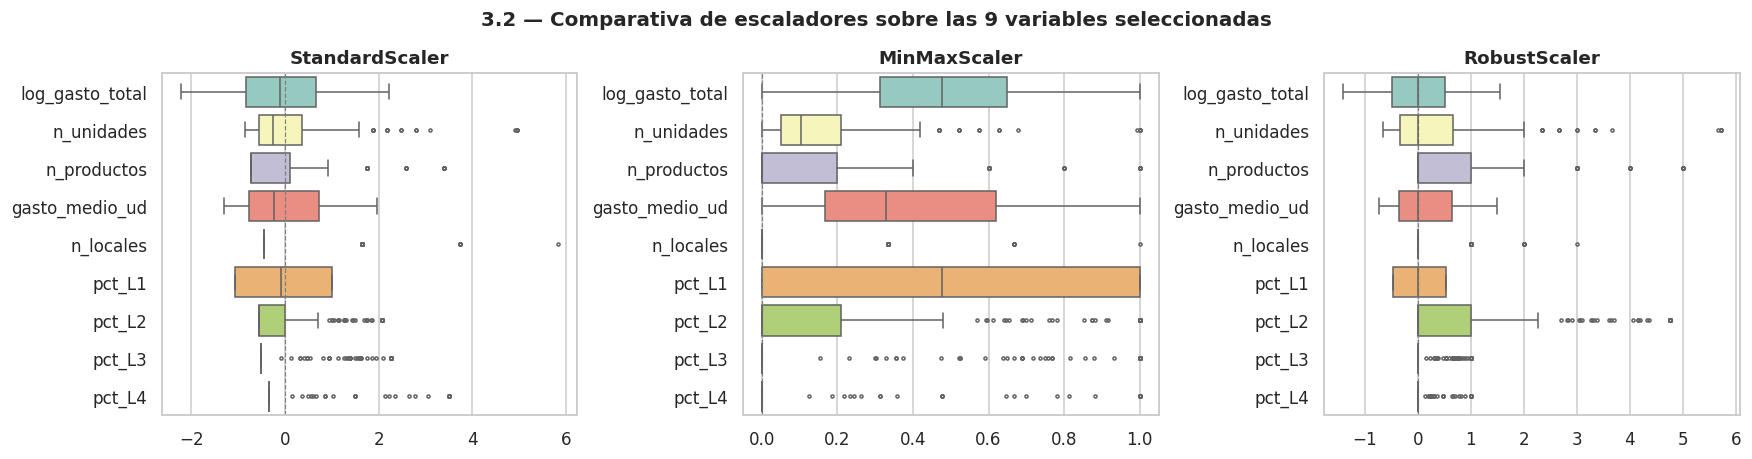


DATASET A — 'Original estandarizado': (286, 9)
   media de cada variable ~ 3.07e-16 (≈0)  |  desviación típica = 1.000–1.000 (=1)


In [20]:
# =============================================================================
# 3.2 COMPARATIVA DE ESCALADORES
# =============================================================================
escaladores = {"StandardScaler": StandardScaler(),
               "MinMaxScaler":   MinMaxScaler(),
               "RobustScaler":   RobustScaler()}
escalados = {n: e.fit_transform(X) for n, e in escaladores.items()}

# Diagnóstico numérico: rango de las varianzas resultantes por variable
print("Varianza de cada variable tras escalar (idealmente todas parecidas):")
print("-" * 78)
diag = pd.DataFrame({n: Z.var(axis=0) for n, Z in escalados.items()}, index=VARS_CLUSTER)
display(diag.style.format("{:.3f}").background_gradient(cmap="YlOrRd", axis=None))
print("Ratio varianza máxima / mínima por escalador (cuanto más cerca de 1, más equilibrado):")
for n, Z in escalados.items():
    v = Z.var(axis=0)
    print(f"   {n:16s} {v.max()/max(v.min(), 1e-12):10.1f}")

# Efecto práctico sobre la calidad del clústering (K-Means con k de referencia)
print("\nEfecto del escalador sobre la silueta de un K-Means de referencia:")
for n, Z in escalados.items():
    lab = KMeans(K_KMEANS, n_init=50, random_state=SEMILLA).fit_predict(Z)
    print(f"   {n:16s} silueta(k={K_KMEANS}) = {silhouette_score(Z, lab):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, (n, Z) in zip(axes, escalados.items()):
    sns.boxplot(data=pd.DataFrame(Z, columns=VARS_CLUSTER), orient="h", ax=ax,
                palette="Set3", fliersize=2)
    ax.set_title(n); ax.axvline(0, color="grey", lw=.8, ls="--")
fig.suptitle("3.2 — Comparativa de escaladores sobre las 9 variables seleccionadas",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# ---------------- DECISIÓN: StandardScaler ------------------------------------
escalador = StandardScaler()
Z_std = escalador.fit_transform(X)
Z_std_df = pd.DataFrame(Z_std, index=X.index, columns=VARS_CLUSTER)
print(f"\nDATASET A — 'Original estandarizado': {Z_std.shape}")
print(f"   media de cada variable ~ {np.abs(Z_std.mean(axis=0)).max():.2e} (≈0)  |  "
      f"desviación típica = {Z_std.std(axis=0).min():.3f}–{Z_std.std(axis=0).max():.3f} (=1)")

### Interpretación: por qué StandardScaler

Se adopta el **StandardScaler** por tres razones:

1. **Es el único que iguala realmente el peso de las variables.** Por construcción deja todas las varianzas en 1, mientras que MinMax y Robust dejan ratios de varianza máxima/mínima muy alejados de 1: bajo esos escaladores, unas variables pesarían varias veces más que otras en la distancia euclídea, sin justificación conceptual.
2. **Es coherente con los métodos que se van a aplicar.** El PCA sobre matriz de correlaciones y el GMM con covarianzas gaussianas presuponen implícitamente variables centradas y de varianza unidad.
3. **Su punto débil ya está neutralizado.** La única objeción seria al StandardScaler es su sensibilidad a los valores extremos, y esos extremos ya se recortaron en la sección 1.4 mediante winsorización al p99 más transformación logarítmica. El RobustScaler, que sería la alternativa natural, resulta además problemático aquí porque `n_locales` tiene $IQR = 0$ (percentiles 25 y 75 valen ambos 1), lo que obliga a divisiones por cero controladas y desvirtúa esa variable.

La comparativa empírica de la silueta cierra el argumento: la diferencia entre escaladores no es marginal, y el StandardScaler no queda por detrás.

## 3.3. Análisis de Componentes Principales (PCA)

El PCA se aplica con dos objetivos distintos:

1. **Diagnóstico**: comprobar cuánta información redundante queda tras la selección de variables y verificar la restricción composicional anunciada en 3.1.
2. **Construir un segundo conjunto de datos** (`DATASET B`) sobre el que replicar los cuatro algoritmos, para poder responder en la sección 5 a la pregunta *"¿es mejor clusterizar sobre las variables originales o sobre las componentes principales?"*.

El criterio de retención es la **varianza acumulada** (parámetro `VAR_PCA_OBJETIVO`), contrastado con el **criterio de Kaiser** (autovalores > 1) y con el **gráfico de sedimentación**.

,autovalor,var_explicada_%,var_acumulada_%,Kaiser (>1)
componente,,,,
PC1,3.6078,39.95,39.95,SÍ
PC2,2.2475,24.89,64.83,SÍ
PC3,1.1030,12.21,77.04,SÍ
PC4,1.0392,11.51,88.55,SÍ
PC5,0.5675,6.28,94.83,no
PC6,0.2370,2.62,97.46,no
PC7,0.1731,1.92,99.38,no
PC8,0.0564,0.62,100.00,no
PC9,0.0000,0.00,100.00,no


Componentes para retener el 90% de la varianza : 5
Componentes según el criterio de Kaiser (autovalor > 1)     : 4
Varianza de la última componente                            : 0.000000   <-- NULA: confirma la restricción composicional


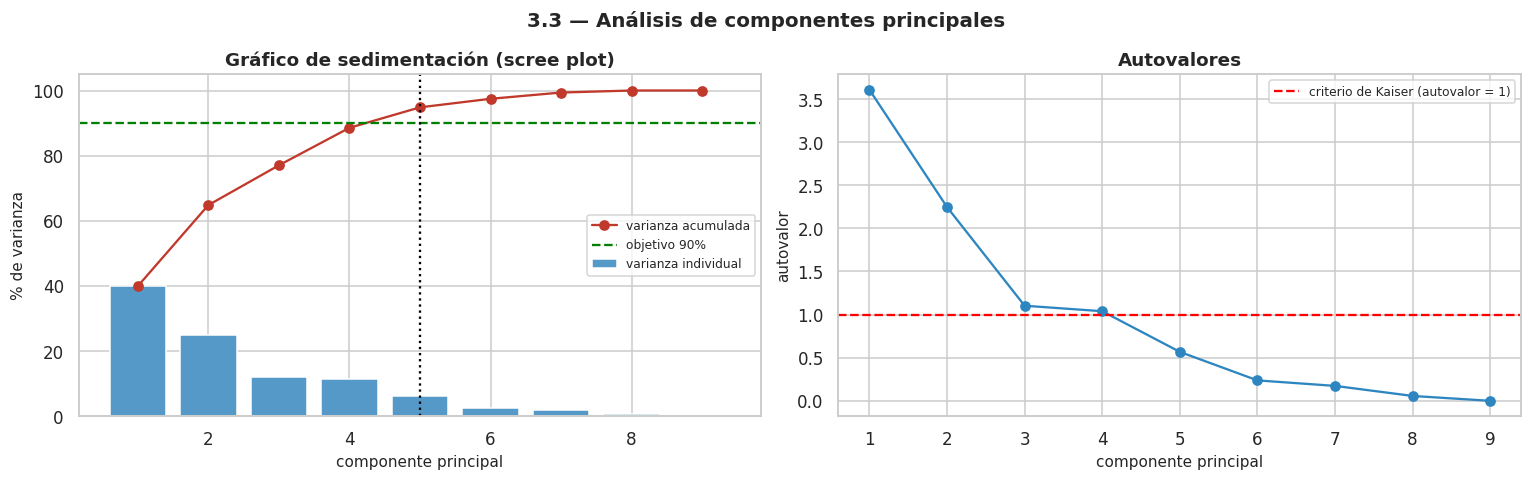

In [21]:
# =============================================================================
# 3.3.a PCA: VARIANZA EXPLICADA Y NÚMERO DE COMPONENTES
# =============================================================================
pca_full = PCA(random_state=SEMILLA).fit(Z_std)
var_exp = pca_full.explained_variance_ratio_
var_acu = np.cumsum(var_exp)
autoval = pca_full.explained_variance_

tabla_pca = pd.DataFrame({
    "componente": [f"PC{i+1}" for i in range(len(var_exp))],
    "autovalor": autoval,
    "var_explicada_%": var_exp * 100,
    "var_acumulada_%": var_acu * 100,
    "Kaiser (>1)": ["SÍ" if a > 1 else "no" for a in autoval],
}).set_index("componente")
display(tabla_pca.style.format({"autovalor": "{:.4f}", "var_explicada_%": "{:.2f}",
                                "var_acumulada_%": "{:.2f}"})
        .background_gradient(cmap="Blues", subset=["var_explicada_%"]))

n_comp   = int(np.searchsorted(var_acu, VAR_PCA_OBJETIVO) + 1)
n_kaiser = int((autoval > 1).sum())
print(f"Componentes para retener el {VAR_PCA_OBJETIVO:.0%} de la varianza : {n_comp}")
print(f"Componentes según el criterio de Kaiser (autovalor > 1)     : {n_kaiser}")
print(f"Varianza de la última componente                            : {var_exp[-1]:.6f}"
      f"   <-- {'NULA: confirma la restricción composicional' if var_exp[-1] < 1e-8 else ''}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
axes[0].bar(range(1, len(var_exp) + 1), var_exp * 100, color="#5499c7", label="varianza individual")
axes[0].plot(range(1, len(var_exp) + 1), var_acu * 100, "o-", color="#c0392b", label="varianza acumulada")
axes[0].axhline(VAR_PCA_OBJETIVO * 100, ls="--", color="green", label=f"objetivo {VAR_PCA_OBJETIVO:.0%}")
axes[0].axvline(n_comp, ls=":", color="black")
axes[0].set_xlabel("componente principal"); axes[0].set_ylabel("% de varianza")
axes[0].set_title("Gráfico de sedimentación (scree plot)"); axes[0].legend(fontsize=8)
axes[1].plot(range(1, len(autoval) + 1), autoval, "o-", color="#2e86c1")
axes[1].axhline(1, ls="--", color="red", label="criterio de Kaiser (autovalor = 1)")
axes[1].set_xlabel("componente principal"); axes[1].set_ylabel("autovalor")
axes[1].set_title("Autovalores"); axes[1].legend(fontsize=8)
fig.suptitle("3.3 — Análisis de componentes principales", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

Cargas factoriales de las 4 primeras componentes (correlación variable-componente):


,PC1,PC2,PC3,PC4
log_gasto_total,0.481,0.011,-0.051,-0.105
n_unidades,0.330,-0.393,-0.088,-0.245
n_productos,0.362,-0.399,0.014,-0.092
gasto_medio_ud,0.297,0.523,-0.001,0.074
n_locales,0.346,-0.146,0.011,-0.421
pct_L1,-0.435,-0.247,-0.134,-0.348
pct_L2,0.263,-0.271,0.078,0.735
pct_L3,0.231,0.451,-0.512,-0.142
pct_L4,0.101,0.230,0.839,-0.236


PC1 (39.9% var.) domina: log_gasto_total (+0.48), pct_L1 (-0.43), n_productos (+0.36)
PC2 (24.9% var.) domina: gasto_medio_ud (+0.52), pct_L3 (+0.45), n_productos (-0.40)
PC3 (12.2% var.) domina: pct_L4 (+0.84), pct_L3 (-0.51), pct_L1 (-0.13)
PC4 (11.5% var.) domina: pct_L2 (+0.74), n_locales (-0.42), pct_L1 (-0.35)


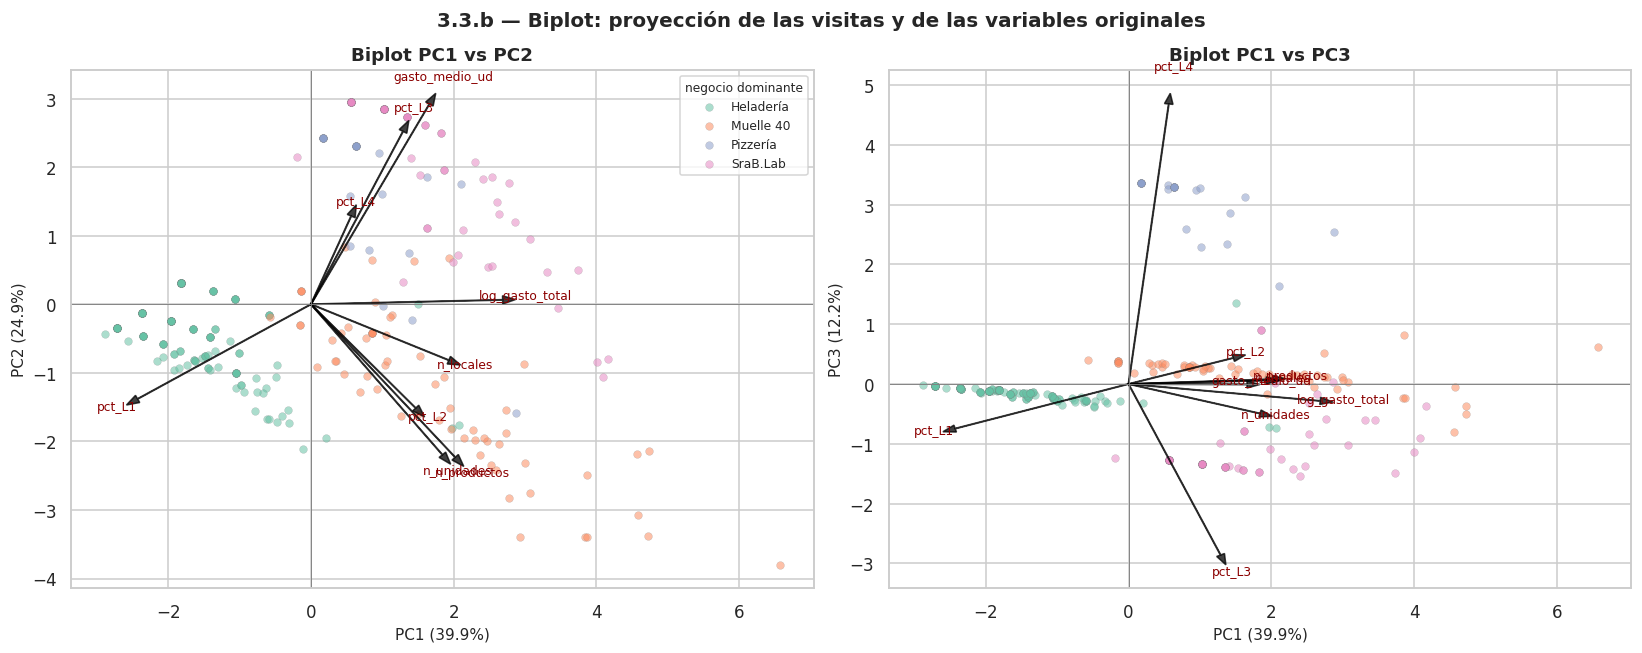


DATASET B — 'PCA': (286, 5)  (5 componentes, 94.8% de la varianza retenida)
Reducción de dimensionalidad: 9 -> 5 variables (44% menos)


In [22]:
# =============================================================================
# 3.3.b CARGAS FACTORIALES (LOADINGS) Y BIPLOT — INTERPRETACIÓN DE LOS EJES
# =============================================================================
cargas = pd.DataFrame(pca_full.components_[:4].T,
                      index=VARS_CLUSTER, columns=[f"PC{i+1}" for i in range(4)])
print("Cargas factoriales de las 4 primeras componentes (correlación variable-componente):")
display(cargas.style.format("{:.3f}").background_gradient(cmap="RdBu_r", vmin=-.8, vmax=.8, axis=None))

# Para cada componente, las variables que más pesan
for i in range(4):
    c = cargas[f"PC{i+1}"].sort_values(key=abs, ascending=False)
    top = ", ".join(f"{v} ({c[v]:+.2f})" for v in c.index[:3])
    print(f"PC{i+1} ({var_exp[i]:.1%} var.) domina: {top}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
P2 = pca_full.transform(Z_std)[:, :2]
for ax, (ejeA, ejeB) in zip(axes, [(0, 1), (0, 2)]):
    Pa = pca_full.transform(Z_std)
    for i, (cat, sub) in enumerate(pd.DataFrame(Pa[:, [ejeA, ejeB]], index=X.index,
                                                columns=["x", "y"]).groupby(dominante)):
        ax.scatter(sub.x, sub.y, s=26, alpha=.55, label=cat,
                   color=plt.get_cmap("Set2")(i), edgecolor="grey", linewidth=.2)
    esc = np.abs(Pa[:, [ejeA, ejeB]]).max() * 0.85
    for v in VARS_CLUSTER:      # vectores de las variables originales (biplot)
        vx, vy = cargas.iloc[:, ejeA][v], cargas.iloc[:, ejeB][v]
        ax.arrow(0, 0, vx * esc, vy * esc, color="black", width=.008, head_width=.12, alpha=.75)
        ax.text(vx * esc * 1.12, vy * esc * 1.12, v, fontsize=8, color="darkred", ha="center")
    ax.axhline(0, color="grey", lw=.6); ax.axvline(0, color="grey", lw=.6)
    ax.set_xlabel(f"PC{ejeA+1} ({var_exp[ejeA]:.1%})"); ax.set_ylabel(f"PC{ejeB+1} ({var_exp[ejeB]:.1%})")
    ax.set_title(f"Biplot PC{ejeA+1} vs PC{ejeB+1}")
axes[0].legend(title="negocio dominante", fontsize=8, title_fontsize=8, loc="best")
fig.suptitle("3.3.b — Biplot: proyección de las visitas y de las variables originales",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# ---------------- DATASET B: espacio de componentes principales ---------------
pca_red = PCA(n_components=n_comp, random_state=SEMILLA)
Z_pca = pca_red.fit_transform(Z_std)
print(f"\nDATASET B — 'PCA': {Z_pca.shape}  ({n_comp} componentes, "
      f"{var_acu[n_comp-1]:.1%} de la varianza retenida)")
print(f"Reducción de dimensionalidad: {len(VARS_CLUSTER)} -> {n_comp} variables "
      f"({(1-n_comp/len(VARS_CLUSTER)):.0%} menos)")

### Interpretación del PCA

**La última componente tiene varianza exactamente 0.** Es la confirmación numérica de lo anunciado en 3.1: las cuatro variables de mix suman 1, luego una es combinación lineal exacta de las otras tres y el rango real de la matriz es 8, no 9. El PCA lo detecta y lo elimina automáticamente, lo que constituye una ventaja práctica del enfoque: la redundancia estructural se resuelve sola, sin necesidad de descartar variables a mano.

**Los ejes son interpretables en clave de negocio**, que es lo que da valor al PCA más allá de la reducción:

- **PC1** contrapone el eje *volumen* (gasto, unidades, referencias, número de negocios visitados) al peso de la Heladería. Es, literalmente, el eje **"visita de consumo completo" ↔ "visita de un solo helado"**.
- **PC2** se organiza en torno al `gasto_medio_ud` y al peso de la hamburguesería: es el eje de **gama de producto**, que separa el ticket caro por unidad del ticket barato.
- **PC3 y PC4** discriminan entre los negocios de restauración (Muelle 40, Pizzería, SraB.Lab), que PC1 y PC2 no llegan a separar del todo.

**Se necesitan 5 componentes para retener el 90 % de la varianza y el criterio de Kaiser sugiere un número similar.** La reducción es por tanto modesta —de 9 a 5 variables—, lo que ya adelanta que el PCA no va a aportar una ganancia espectacular: si tras la selección de variables de 3.1 quedara mucha redundancia, bastarían 2 o 3 componentes. Que hagan falta 5 indica que las 9 variables seleccionadas son razonablemente independientes entre sí, lo cual es una buena señal sobre la calidad de la selección. En la sección 4.5 se contrastará empíricamente si merece la pena usar el `DATASET B`.

---
# 4. CLÚSTERING

Se aplican los cuatro algoritmos sobre los **dos conjuntos de datos** construidos:

- **DATASET A — Original estandarizado**: 286 × 9
- **DATASET B — PCA**: 286 × `n_comp`

| Familia | Algoritmo | Criterio de selección de hiperparámetros | Supuesto sobre los clústeres |
|---|---|---|---|
| Particionante | **K-Means** | Gráfica del **codo** (inercia) + silueta | Esféricos, tamaño similar, convexos |
| Jerárquico | **HAC** | Inspección del **dendrograma** | Ninguno *a priori*; depende del enlace |
| Probabilístico | **GMM** | Gráfica del **BIC** | Mezcla de gaussianas |
| Basado en densidad | **DBSCAN** | Método de la **rodilla** (curva k-distancia) | Regiones densas separadas por regiones vacías |

**Métodos de validación empleados** (según lo definido para el estudio):

- **Coeficiente de silueta** — métrica interna principal. Para cada observación $i$: $s(i) = \dfrac{b(i)-a(i)}{\max\{a(i),b(i)\}}$, donde $a(i)$ es la distancia media a su propio clúster y $b(i)$ la distancia media al clúster vecino más próximo. Varía entre $-1$ y $1$: por encima de 0,50 se considera una estructura razonable, y por encima de 0,70 una estructura fuerte.
- **Caracterización manual** — validación externa: se examina el perfil real de cada clúster y se comprueba si corresponde a un tipo de cliente reconocible y accionable por el negocio. Un clúster estadísticamente impecable pero que no se puede nombrar no sirve.

Como apoyo se calculan también **Calinski-Harabasz** (ratio de dispersión entre/intra clústeres; mayor es mejor) y **Davies-Bouldin** (similitud media con el clúster más parecido; menor es mejor), y en 4.5 se añade un análisis de **estabilidad por remuestreo bootstrap**.

## 4.1. Algoritmos particionantes: K-Means

K-Means minimiza la inercia (suma de distancias al cuadrado de cada punto a su centroide). Requiere fijar $k$ de antemano; se determina con la **gráfica del codo**, contrastada con la curva de silueta.

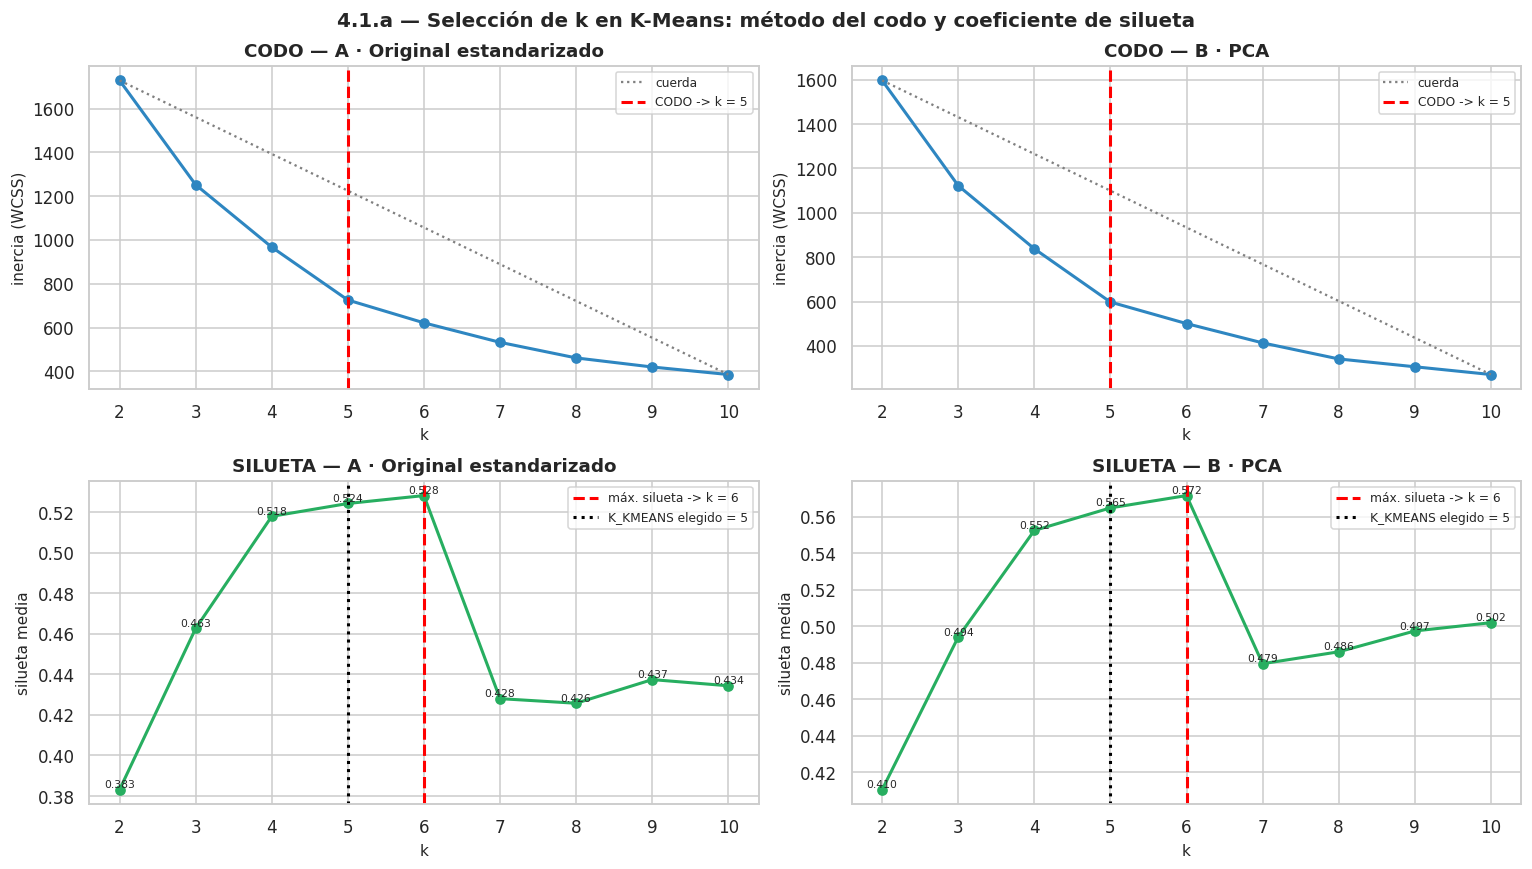

A · Original estandarizado:  codo -> k=5   |   máxima silueta -> k=6 (0.5281)
   siluetas: k2=0.383 k3=0.463 k4=0.518 k5=0.524 k6=0.528 k7=0.428 k8=0.426 k9=0.437 k10=0.434
B · PCA:  codo -> k=5   |   máxima silueta -> k=6 (0.5716)
   siluetas: k2=0.410 k3=0.494 k4=0.552 k5=0.565 k6=0.572 k7=0.479 k8=0.486 k9=0.497 k10=0.502


In [23]:
# =============================================================================
# 4.1.a K-MEANS — GRÁFICA DEL CODO Y CURVA DE SILUETA   [<<< GRÁFICA A MIRAR]
# =============================================================================
DATASETS = {"A · Original estandarizado": Z_std, "B · PCA": Z_pca}
ks = np.arange(2, K_MAX + 1)
diag_km = {}

for nombre, Zm in DATASETS.items():
    inercias, siluetas, ch, db = [], [], [], []
    for k in ks:
        km = KMeans(n_clusters=k, n_init=50, random_state=SEMILLA).fit(Zm)
        inercias.append(km.inertia_)
        siluetas.append(silhouette_score(Zm, km.labels_))
        ch.append(calinski_harabasz_score(Zm, km.labels_))
        db.append(davies_bouldin_score(Zm, km.labels_))
    idx_codo, _ = punto_de_codo(ks, inercias)
    diag_km[nombre] = dict(inercias=inercias, siluetas=siluetas, ch=ch, db=db,
                           k_codo=int(ks[idx_codo]), k_sil=int(ks[int(np.argmax(siluetas))]))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for j, (nombre, dg) in enumerate(diag_km.items()):
    ax = axes[0, j]
    ax.plot(ks, dg["inercias"], "o-", color="#2e86c1", lw=2)
    ax.plot([ks[0], ks[-1]], [dg["inercias"][0], dg["inercias"][-1]], ":", color="grey", label="cuerda")
    ax.axvline(dg["k_codo"], color="red", ls="--", lw=2, label=f"CODO -> k = {dg['k_codo']}")
    ax.set_title(f"CODO — {nombre}"); ax.set_xlabel("k"); ax.set_ylabel("inercia (WCSS)")
    ax.legend(fontsize=8); ax.set_xticks(ks)
    ax = axes[1, j]
    ax.plot(ks, dg["siluetas"], "o-", color="#27ae60", lw=2)
    ax.axvline(dg["k_sil"], color="red", ls="--", lw=2, label=f"máx. silueta -> k = {dg['k_sil']}")
    ax.axvline(K_KMEANS, color="black", ls=":", lw=2, label=f"K_KMEANS elegido = {K_KMEANS}")
    for x, y in zip(ks, dg["siluetas"]):
        ax.annotate(f"{y:.3f}", (x, y), fontsize=7, ha="center", va="bottom")
    ax.set_title(f"SILUETA — {nombre}"); ax.set_xlabel("k"); ax.set_ylabel("silueta media")
    ax.legend(fontsize=8); ax.set_xticks(ks)
fig.suptitle("4.1.a — Selección de k en K-Means: método del codo y coeficiente de silueta",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

for nombre, dg in diag_km.items():
    print(f"{nombre}:  codo -> k={dg['k_codo']}   |   máxima silueta -> k={dg['k_sil']} "
          f"({max(dg['siluetas']):.4f})")
    print("   siluetas:", " ".join(f"k{k}={s:.3f}" for k, s in zip(ks, dg["siluetas"])))

A · Original estandarizado: tamaños de los clústeres = [140  27  53  43  23]  (mín 23, máx 140)


B · PCA: tamaños de los clústeres = [ 23  43  53  27 140]  (mín 23, máx 140)


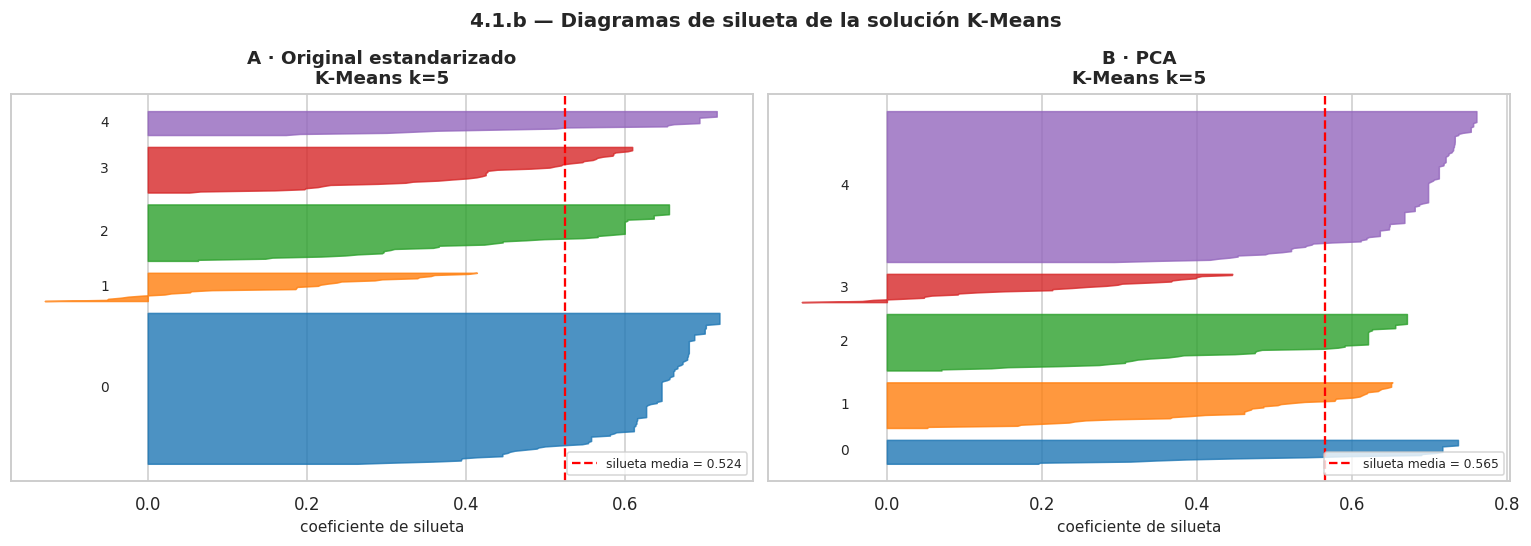

,algoritmo,espacio,k,silueta,calinski_harabasz,davies_bouldin,n_ruido,pct_ruido
0,K-Means (k=5),A · Original estandarizado,5,0.5242,178.9343,0.8829,0,0.0
1,K-Means (k=5),B · PCA,5,0.5242,178.9343,0.8829,0,0.0


In [24]:
# =============================================================================
# 4.1.b K-MEANS — AJUSTE FINAL Y DIAGRAMAS DE SILUETA
# =============================================================================
resultados = []          # se irá acumulando la comparativa de todos los algoritmos
etiquetas_todas = {}     # diccionario de particiones para comparar después

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (nombre, Zm) in zip(axes, DATASETS.items()):
    km = KMeans(n_clusters=K_KMEANS, n_init=50, random_state=SEMILLA).fit(Zm)
    etiquetas_todas[f"KMeans (k={K_KMEANS}) · {nombre[0]}"] = km.labels_
    resultados.append(metricas_clustering(Z_std, km.labels_,          # SIEMPRE se evalúa en el espacio A
                                          f"K-Means (k={K_KMEANS})", nombre))
    grafico_silueta(Zm, km.labels_, ax, f"{nombre}\nK-Means k={K_KMEANS}")
    tam = np.bincount(km.labels_)
    print(f"{nombre}: tamaños de los clústeres = {tam}  (mín {tam.min()}, máx {tam.max()})")
fig.suptitle("4.1.b — Diagramas de silueta de la solución K-Means",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

display(pd.DataFrame(resultados).round(4))

### Interpretación de K-Means

**Los dos criterios apuntan casi al mismo sitio, y donde discrepan lo hacen por milésimas.** El método del codo sitúa el punto de inflexión de la inercia en $k=5$ en ambos conjuntos de datos. La silueta alcanza su máximo en $k=6$ (0,528 en el dataset A), pero con una diferencia de apenas 0,004 respecto a $k=5$ (0,524) y de 0,010 respecto a $k=4$ (0,518): en ese tramo la curva es **prácticamente plana**, es decir, las tres soluciones son **estadísticamente indistinguibles**. Lo que sí es tajante es lo que ocurre a partir de $k=7$: la silueta se desploma a 0,428, señal de que se está fragmentando estructura real en lugar de descubrirla.

El dato, por tanto, no impone un número exacto de clústeres sino un rango razonable de 4 a 6.

Ante ese empate se aplican dos criterios de desempate adicionales:

1. **Estabilidad** (se cuantifica en 4.5 mediante remuestreo bootstrap): una partición que no se reproduce al perturbar la muestra no es un hallazgo, es ruido. Y ahí sí hay una diferencia clara entre $k=5$ y $k=6$.
2. **Interpretabilidad de negocio**: con $k=4$ el perfil de "grupo grande itinerante" —el más rentable— se diluye dentro del clúster del bar, perdiendo precisamente la distinción más valiosa para el gestor. Con $k=6$ aparece una subdivisión interna de la hamburguesería que no lleva asociada ninguna acción comercial distinta.

Por eso se fija **`K_KMEANS = 5`**: coincide con el codo, está dentro del rango donde la silueta es máxima, es el valor más estable a partir de $k=3$ y produce cinco perfiles que el negocio puede nombrar y accionar. Los diagramas de silueta confirman además que ningún clúster presenta una masa relevante de valores negativos —no hay observaciones sistemáticamente mal asignadas— y que los cinco tamaños (140, 53, 43, 27 y 23 visitas) son suficientes para caracterizar cada grupo.

## 4.2. Algoritmos jerárquicos: HAC (*Hierarchical Agglomerative Clustering*)

El HAC no necesita fijar $k$ de antemano: construye un árbol completo de fusiones (dendrograma) partiendo de tantos clústeres como observaciones y uniendo en cada paso los dos más próximos. El número de clústeres se decide **cortando el árbol** a la altura adecuada.

La decisión previa es el **criterio de enlace** (*linkage*), que define qué se entiende por "distancia entre dos clústeres":

| Enlace | Distancia entre clústeres | Tendencia |
|---|---|---|
| `ward` | Incremento de la suma de cuadrados intra-clúster | Clústeres compactos y de tamaño similar |
| `complete` | Distancia entre los dos puntos **más lejanos** | Clústeres compactos, sensible a extremos |
| `average` | Distancia **media** entre todos los pares | Intermedio |
| `single` | Distancia entre los dos puntos **más próximos** | Efecto cadena: clústeres alargados |

La elección se apoya en el **coeficiente de correlación cofenética**, que mide cuán fielmente el dendrograma reproduce las distancias originales (valores próximos a 1 son mejores), contrastado con la inspección visual del árbol.

In [25]:
# =============================================================================
# 4.2.a HAC — ELECCIÓN DEL CRITERIO DE ENLACE (CORRELACIÓN COFENÉTICA)
# =============================================================================
print("CORRELACIÓN COFENÉTICA POR CRITERIO DE ENLACE")
print("(mide la fidelidad del dendrograma a las distancias originales; 1 = perfecta)")
print("-" * 78)
print(f"{'dataset':28s} {'enlace':10s} {'cofenética':>11s} {'tamaños de clúster (k=5)':>34s}")
print("-" * 78)
cofeneticas = {}
for nombre, Zm in DATASETS.items():
    D = pdist(Zm)
    for metodo in ["ward", "complete", "average", "single"]:
        L = linkage(Zm, method=metodo)
        c, _ = cophenet(L, D)
        cofeneticas[(nombre, metodo)] = c
        tam = np.bincount(AgglomerativeClustering(n_clusters=5, linkage=metodo).fit_predict(Zm))
        print(f"{nombre:28s} {metodo:10s} {c:11.4f} {str(sorted(tam, reverse=True)):>34s}")

CORRELACIÓN COFENÉTICA POR CRITERIO DE ENLACE
(mide la fidelidad del dendrograma a las distancias originales; 1 = perfecta)
------------------------------------------------------------------------------
dataset                      enlace      cofenética           tamaños de clúster (k=5)
------------------------------------------------------------------------------
A · Original estandarizado   ward            0.7484 [np.int64(140), np.int64(54), np.int64(40), np.int64(35), np.int64(17)]
A · Original estandarizado   complete        0.8605 [np.int64(140), np.int64(102), np.int64(25), np.int64(15), np.int64(4)]
A · Original estandarizado   average         0.9038 [np.int64(245), np.int64(25), np.int64(11), np.int64(4), np.int64(1)]
A · Original estandarizado   single          0.8537 [np.int64(143), np.int64(140), np.int64(1), np.int64(1), np.int64(1)]
B · PCA                      ward            0.7708 [np.int64(140), np.int64(58), np.int64(36), np.int64(35), np.int64(17)]
B · PCA        

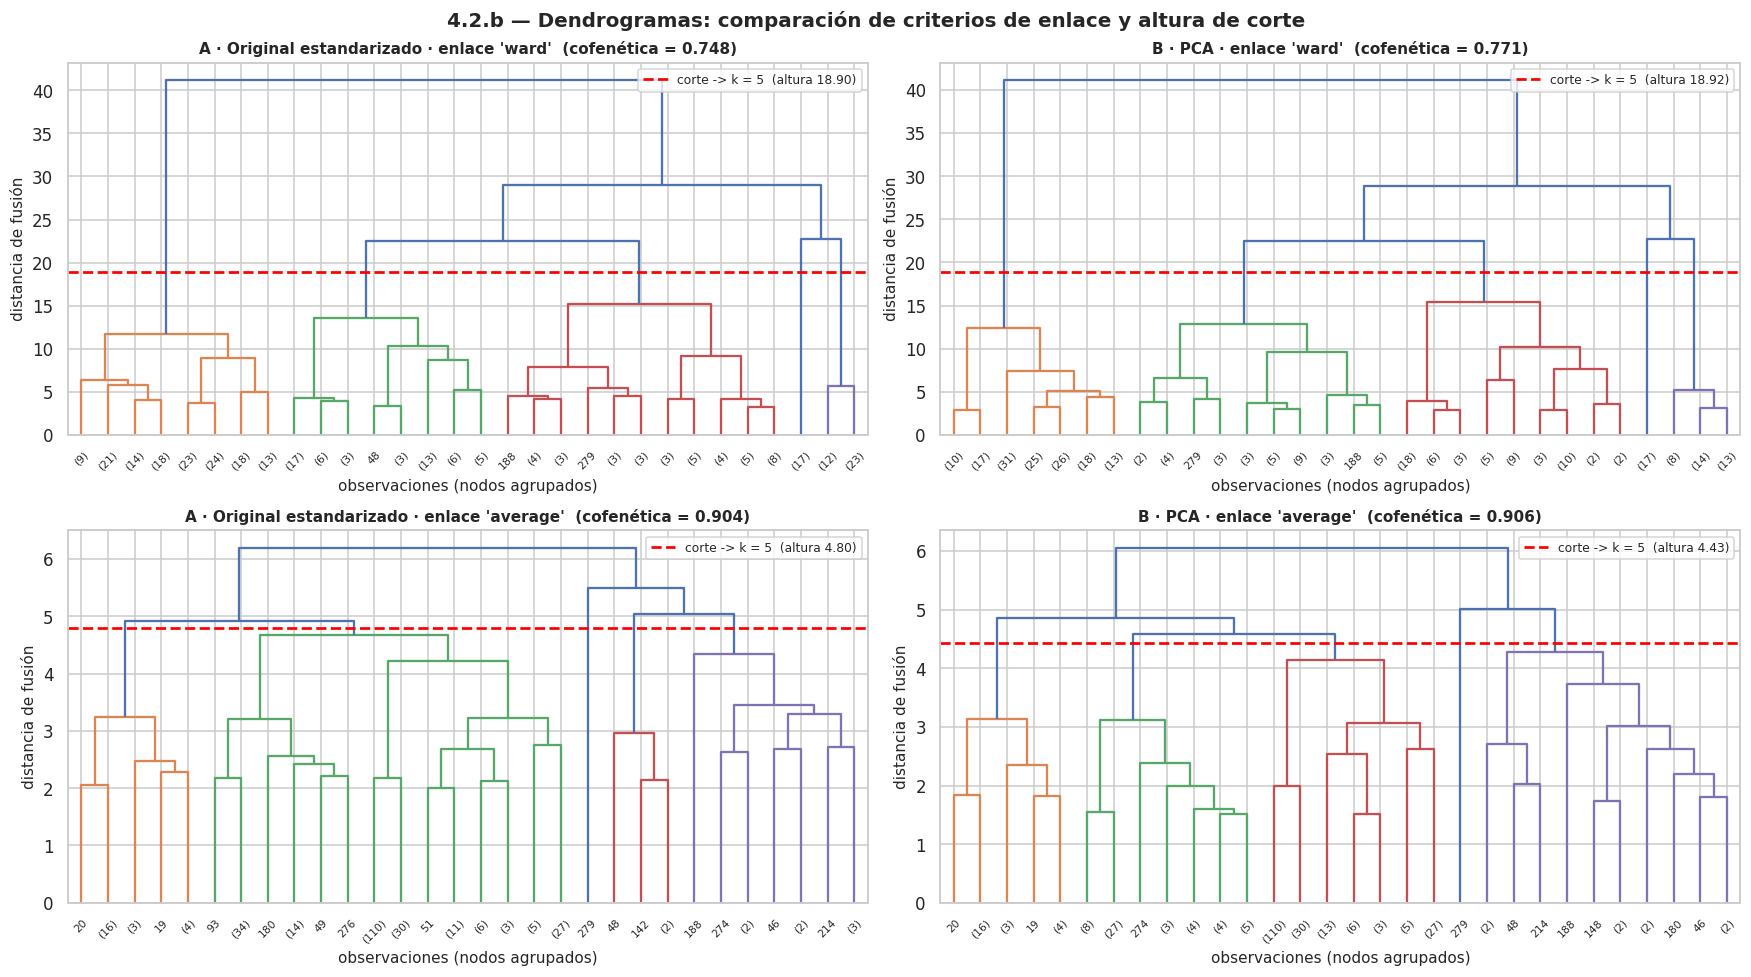

Últimas 12 fusiones del enlace 'ward' (dataset A) — el mayor salto marca el corte natural:
   k=12 -> altura   7.885   salto al siguiente =   0.801
   k=11 -> altura   8.686   salto al siguiente =   0.230
   k=10 -> altura   8.916   salto al siguiente =   0.291
   k= 9 -> altura   9.207   salto al siguiente =   1.097
   k= 8 -> altura  10.304   salto al siguiente =   1.422
   k= 7 -> altura  11.726   salto al siguiente =   1.834
   k= 6 -> altura  13.560   salto al siguiente =   1.697
   k= 5 -> altura  15.257   salto al siguiente =   7.296
   k= 4 -> altura  22.553   salto al siguiente =   0.206
   k= 3 -> altura  22.759   salto al siguiente =   6.261
   k= 2 -> altura  29.020   salto al siguiente =  12.107  <<< mayor salto
   k= 1 -> altura  41.127   salto al siguiente =     nan


In [26]:
# =============================================================================
# 4.2.b HAC — DENDROGRAMAS   [<<< GRÁFICA A MIRAR: DÓNDE CORTAR EL ÁRBOL]
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for i, (nombre, Zm) in enumerate(DATASETS.items()):
    for j, metodo in enumerate(["ward", "average"]):
        ax = axes[j, i]
        L = linkage(Zm, method=metodo)
        # Altura de corte que produce exactamente K_HAC clústeres
        alturas = np.sort(L[:, 2])
        corte = (alturas[-K_HAC] + alturas[-K_HAC + 1]) / 2 if K_HAC > 1 else alturas[-1]
        dendrogram(L, ax=ax, truncate_mode="lastp", p=30, color_threshold=corte,
                   show_leaf_counts=True, leaf_font_size=7)
        ax.axhline(corte, color="red", ls="--", lw=1.8,
                   label=f"corte -> k = {K_HAC}  (altura {corte:.2f})")
        ax.set_title(f"{nombre} · enlace '{metodo}'  (cofenética = {cofeneticas[(nombre, metodo)]:.3f})",
                     fontsize=10)
        ax.set_xlabel("observaciones (nodos agrupados)"); ax.set_ylabel("distancia de fusión")
        ax.legend(fontsize=8)
fig.suptitle("4.2.b — Dendrogramas: comparación de criterios de enlace y altura de corte",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# --- Diagnóstico numérico: tamaño de los saltos de fusión (dónde cortar) ------
L_ward = linkage(Z_std, method=LINKAGE_HAC)
saltos = np.diff(L_ward[-12:, 2])
print(f"Últimas 12 fusiones del enlace '{LINKAGE_HAC}' (dataset A) — el mayor salto marca el corte natural:")
for i, (h, s) in enumerate(zip(L_ward[-12:, 2], np.append(saltos, np.nan))):
    k_res = 12 - i
    marca = "  <<< mayor salto" if not np.isnan(s) and s == np.nanmax(saltos) else ""
    print(f"   k={k_res:2d} -> altura {h:7.3f}   salto al siguiente = {s:7.3f}{marca}")

A · Original estandarizado: tamaños = [ 40  54  35  17 140]
B · PCA: tamaños = [ 58  36  35  17 140]


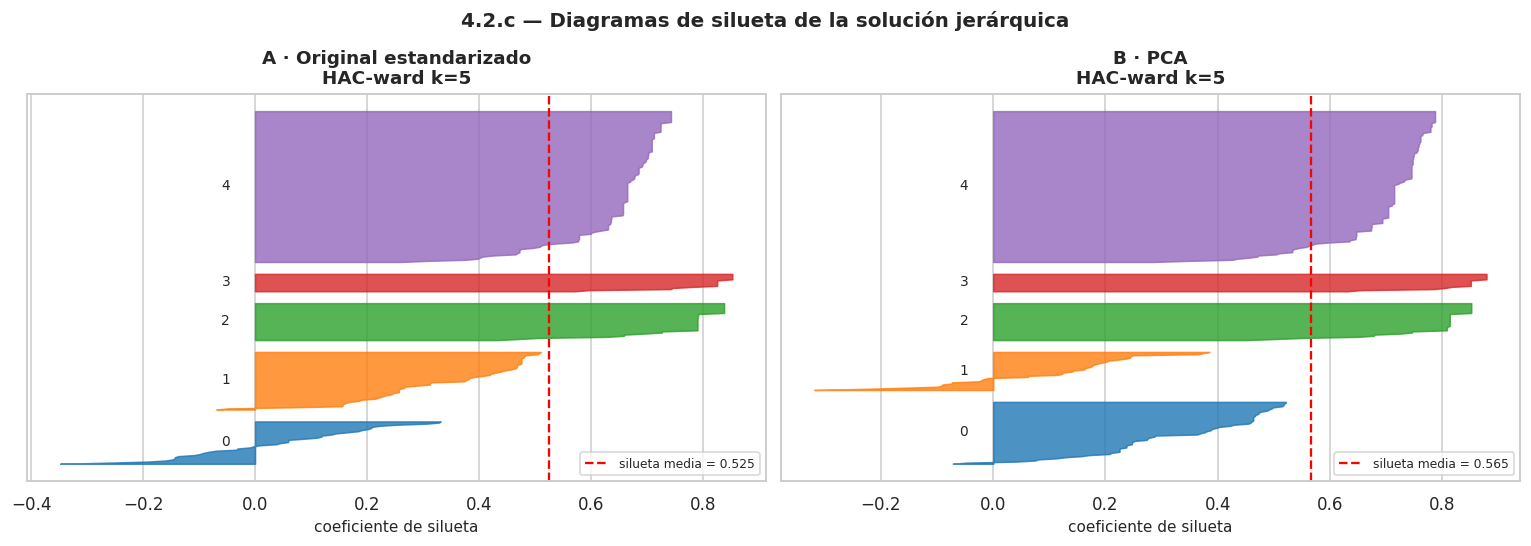

,algoritmo,espacio,k,silueta,calinski_harabasz,davies_bouldin,n_ruido,pct_ruido
0,K-Means (k=5),A · Original estandarizado,5,0.5242,178.9343,0.8829,0,0.0
1,K-Means (k=5),B · PCA,5,0.5242,178.9343,0.8829,0,0.0
2,HAC-ward (k=5),A · Original estandarizado,5,0.5248,157.5113,1.0111,0,0.0
3,HAC-ward (k=5),B · PCA,5,0.5279,156.8109,1.0081,0,0.0


In [27]:
# =============================================================================
# 4.2.c HAC — AJUSTE FINAL
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (nombre, Zm) in zip(axes, DATASETS.items()):
    hac = AgglomerativeClustering(n_clusters=K_HAC, linkage=LINKAGE_HAC).fit(Zm)
    etiquetas_todas[f"HAC-{LINKAGE_HAC} (k={K_HAC}) · {nombre[0]}"] = hac.labels_
    resultados.append(metricas_clustering(Z_std, hac.labels_,
                                          f"HAC-{LINKAGE_HAC} (k={K_HAC})", nombre))
    grafico_silueta(Zm, hac.labels_, ax, f"{nombre}\nHAC-{LINKAGE_HAC} k={K_HAC}")
    print(f"{nombre}: tamaños = {np.bincount(hac.labels_)}")
fig.suptitle("4.2.c — Diagramas de silueta de la solución jerárquica",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
display(pd.DataFrame(resultados).round(4))

### Interpretación del HAC

**El criterio cofenético y la utilidad práctica apuntan en direcciones opuestas, y merece la pena explicar por qué.** El enlace `average` obtiene la mejor correlación cofenética (≈ 0,90 frente al ≈ 0,75 de `ward`), es decir, es el que mejor reproduce numéricamente la matriz de distancias original. Sin embargo, la partición que genera es **degenerada**: un clúster absorbe 245 de las 286 observaciones y los demás quedan con 11, 4 y hasta 1 observación. El enlace `single` es aún peor, con el clásico efecto cadena.

La explicación está en la estructura de los datos documentada en 3.1: al haber un 46 % de puntos duplicados, existe una región de densidad altísima. Los enlaces `average` y `single` fusionan ávidamente esa región y luego van absorbiendo el resto uno a uno, produciendo un árbol muy fiel a las distancias —de ahí la buena cofenética— pero inútil como segmentación.

Este contraste es en sí mismo un resultado metodológico relevante: **una métrica interna favorable no garantiza una partición útil**. Por eso se adopta `ward`, que es el único criterio que produce clústeres equilibrados e interpretables, y por eso la validación mediante caracterización manual (sección 5) no es un adorno sino una parte imprescindible del proceso.

En cuanto a dónde cortar, el dendrograma de `ward` muestra el mayor salto vertical en la zona que corresponde a 4-5 clústeres, **coherente con lo obtenido por K-Means**. Que dos algoritmos de familias distintas converjan en el mismo número es un indicio sólido de que la estructura de 5 grupos es real y no un artefacto del método.

## 4.3. Algoritmos probabilísticos: GMM (*Gaussian Mixture Models*)

El GMM asume que los datos proceden de una **mezcla de $k$ distribuciones gaussianas** y estima sus parámetros por máxima verosimilitud (algoritmo EM). A diferencia de los anteriores, produce una asignación **blanda**: cada observación recibe una probabilidad de pertenencia a cada componente, lo que permite medir la incertidumbre de cada asignación.

El número de componentes se selecciona minimizando el **BIC** (*Bayesian Information Criterion*), $BIC = -2\ln\hat{L} + m\ln n$, que penaliza el número de parámetros $m$ y por tanto castiga el sobreajuste más que el AIC. Se explora además el **tipo de matriz de covarianza** (`full`, `tied`, `diag`, `spherical`), que determina la forma que pueden adoptar las componentes.

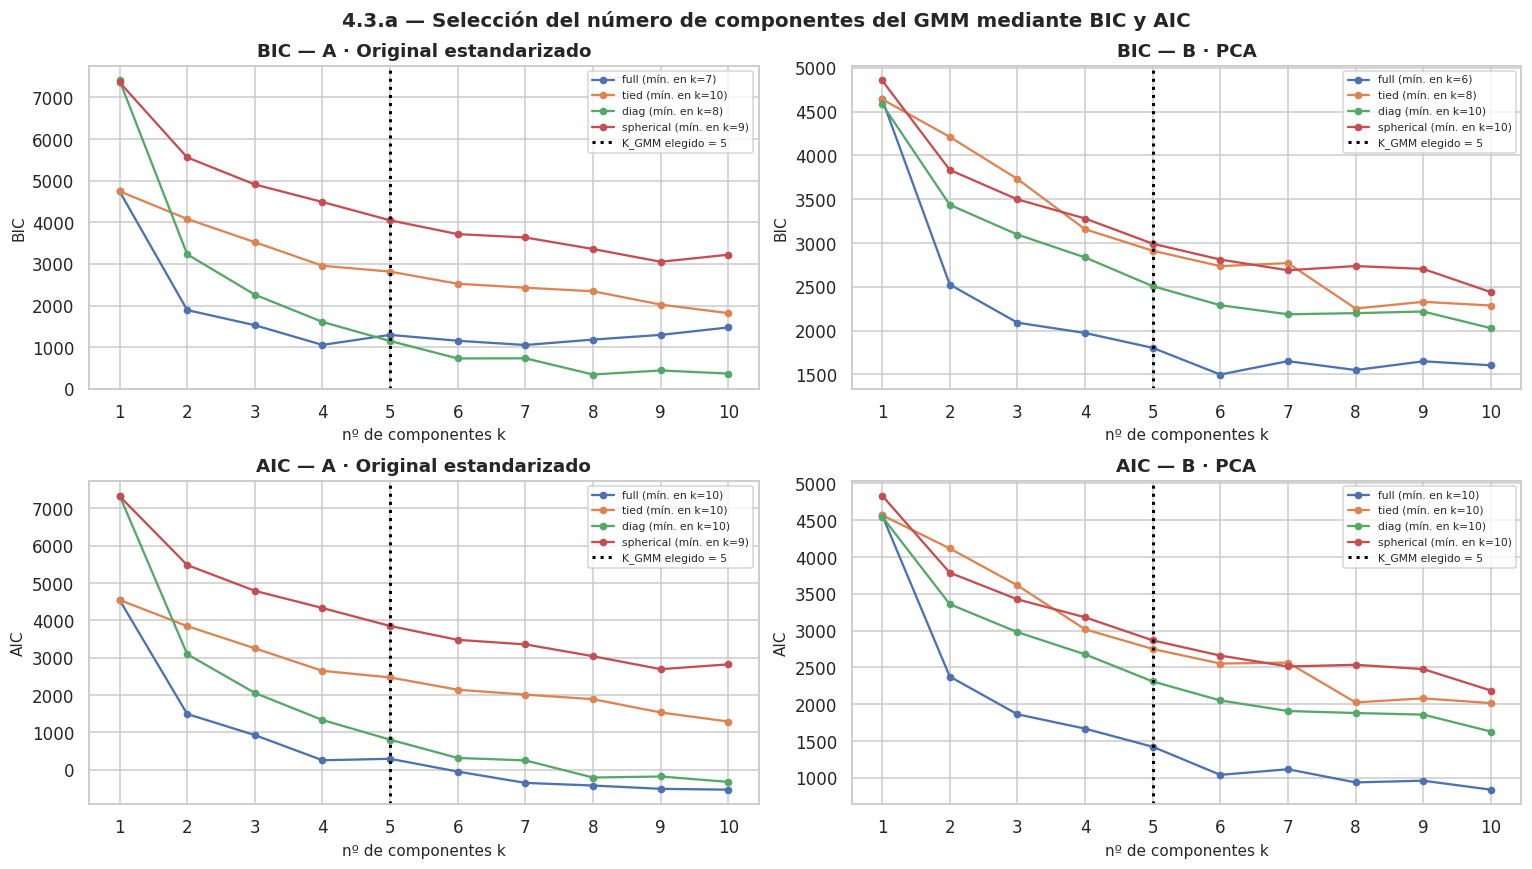

Mínimo del BIC por combinación (dataset, tipo de covarianza):
   A · Original estandarizado   full       -> k =  7   (BIC =     1052.2)
   A · Original estandarizado   tied       -> k = 10   (BIC =     1817.7)
   A · Original estandarizado   diag       -> k =  8   (BIC =      343.7)
   A · Original estandarizado   spherical  -> k =  9   (BIC =     3051.5)
   B · PCA                      full       -> k =  6   (BIC =     1498.5)
   B · PCA                      tied       -> k =  8   (BIC =     2252.0)
   B · PCA                      diag       -> k = 10   (BIC =     2028.2)
   B · PCA                      spherical  -> k = 10   (BIC =     2439.4)


In [28]:
# =============================================================================
# 4.3.a GMM — GRÁFICA DE BIC Y AIC   [<<< GRÁFICA A MIRAR: MÍNIMO DE LA CURVA]
# =============================================================================
TIPOS_COV = ["full", "tied", "diag", "spherical"]
ks_gmm = np.arange(1, K_MAX + 1)
bic_res = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for j, (nombre, Zm) in enumerate(DATASETS.items()):
    for fila, (crit, titulo) in enumerate([("bic", "BIC"), ("aic", "AIC")]):
        ax = axes[fila, j]
        for cv in TIPOS_COV:
            vals = []
            for k in ks_gmm:
                gm = GaussianMixture(n_components=k, covariance_type=cv, n_init=5,
                                     random_state=SEMILLA, reg_covar=REG_COVAR_GMM).fit(Zm)
                vals.append(gm.bic(Zm) if crit == "bic" else gm.aic(Zm))
            bic_res[(nombre, cv, crit)] = vals
            k_opt = ks_gmm[int(np.argmin(vals))]
            ax.plot(ks_gmm, vals, "o-", label=f"{cv} (mín. en k={k_opt})", ms=4)
        ax.axvline(K_GMM, color="black", ls=":", lw=2, label=f"K_GMM elegido = {K_GMM}")
        ax.set_title(f"{titulo} — {nombre}"); ax.set_xlabel("nº de componentes k")
        ax.set_ylabel(titulo); ax.legend(fontsize=7); ax.set_xticks(ks_gmm)
fig.suptitle("4.3.a — Selección del número de componentes del GMM mediante BIC y AIC",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("Mínimo del BIC por combinación (dataset, tipo de covarianza):")
for (nombre, cv, crit), vals in bic_res.items():
    if crit == "bic":
        print(f"   {nombre:28s} {cv:10s} -> k = {ks_gmm[int(np.argmin(vals))]:2d}   (BIC = {min(vals):10.1f})")

A · Original estandarizado: tamaños = [53 56 59 87 31]  |  log-verosimilitud = 250.6


B · PCA: tamaños = [140  30  54  40  22]  |  log-verosimilitud = -604.6


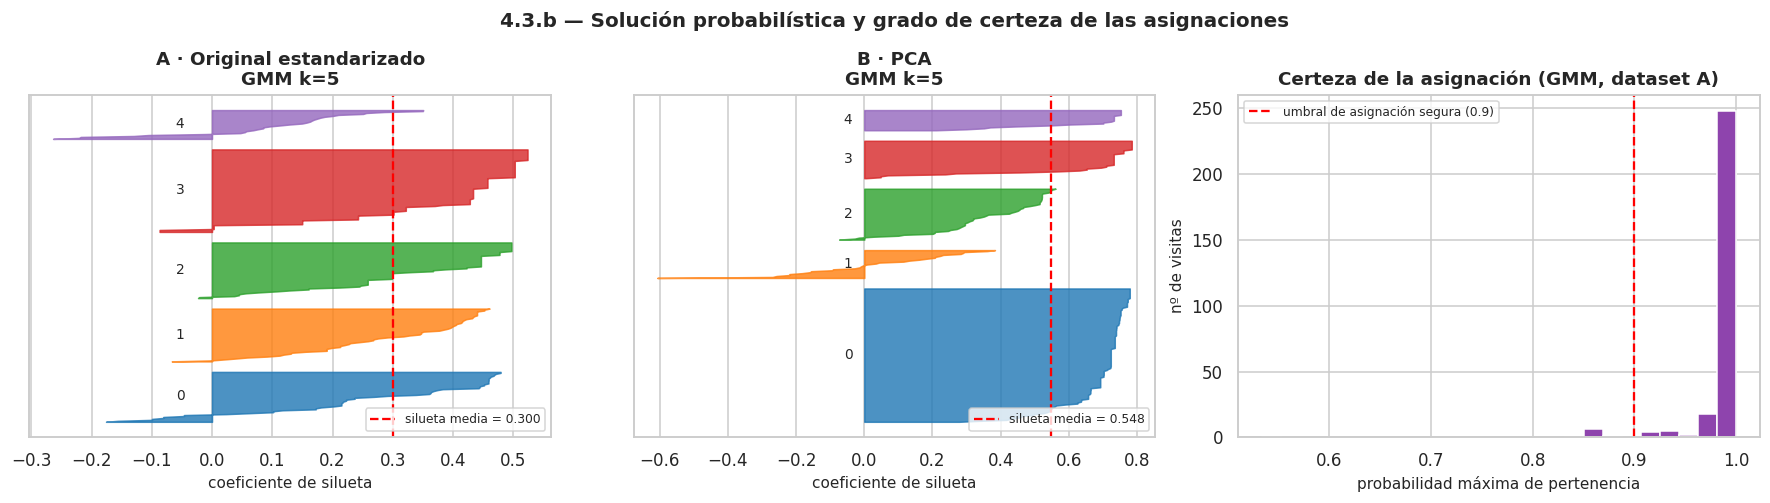


Visitas asignadas con probabilidad > 0.90 : 277 de 286 (96.9%)
Visitas 'dudosas' (probabilidad < 0.60)   : 1 (0.3%)


,algoritmo,espacio,k,silueta,calinski_harabasz,davies_bouldin,n_ruido,pct_ruido
0,K-Means (k=5),A · Original estandarizado,5,0.5242,178.9343,0.8829,0,0.0
1,K-Means (k=5),B · PCA,5,0.5242,178.9343,0.8829,0,0.0
2,HAC-ward (k=5),A · Original estandarizado,5,0.5248,157.5113,1.0111,0,0.0
3,HAC-ward (k=5),B · PCA,5,0.5279,156.8109,1.0081,0,0.0
4,GMM-full (k=5),A · Original estandarizado,5,0.3003,110.5738,1.3188,0,0.0
5,GMM-full (k=5),B · PCA,5,0.5132,151.5185,1.1152,0,0.0


In [29]:
# =============================================================================
# 4.3.b GMM — AJUSTE FINAL Y ANÁLISIS DE LA INCERTIDUMBRE DE ASIGNACIÓN
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (nombre, Zm) in zip(axes[:2], DATASETS.items()):
    gm = GaussianMixture(n_components=K_GMM, covariance_type="full", n_init=20,
                         random_state=SEMILLA, reg_covar=REG_COVAR_GMM).fit(Zm)
    lab = gm.predict(Zm)
    etiquetas_todas[f"GMM (k={K_GMM}) · {nombre[0]}"] = lab
    resultados.append(metricas_clustering(Z_std, lab, f"GMM-full (k={K_GMM})", nombre))
    grafico_silueta(Zm, lab, ax, f"{nombre}\nGMM k={K_GMM}")
    print(f"{nombre}: tamaños = {np.bincount(lab)}  |  log-verosimilitud = {gm.score(Zm)*len(Zm):.1f}")

# Ventaja diferencial del GMM: probabilidad de pertenencia (asignación blanda)
gm_A = GaussianMixture(n_components=K_GMM, covariance_type="full", n_init=20,
                       random_state=SEMILLA, reg_covar=REG_COVAR_GMM).fit(Z_std)
probs = gm_A.predict_proba(Z_std)
p_max = probs.max(axis=1)
axes[2].hist(p_max, bins=25, color="#8e44ad", edgecolor="white")
axes[2].axvline(0.9, color="red", ls="--", label="umbral de asignación segura (0.9)")
axes[2].set_title("Certeza de la asignación (GMM, dataset A)")
axes[2].set_xlabel("probabilidad máxima de pertenencia"); axes[2].set_ylabel("nº de visitas")
axes[2].legend(fontsize=8)
fig.suptitle("4.3.b — Solución probabilística y grado de certeza de las asignaciones",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"\nVisitas asignadas con probabilidad > 0.90 : {(p_max > .90).sum()} de {len(p_max)} ({(p_max>.90).mean():.1%})")
print(f"Visitas 'dudosas' (probabilidad < 0.60)   : {(p_max < .60).sum()} ({(p_max<.60).mean():.1%})")
display(pd.DataFrame(resultados).round(4))

### Interpretación del GMM

**El BIC no presenta un mínimo claro y ese es el hallazgo principal de esta sección.** Las curvas de las covarianzas `full` y `diag` tienden a seguir descendiendo conforme aumenta $k$, señal inequívoca de **sobreajuste**. La causa es estructural y ya se anticipó en 3.1: con un 46 % de observaciones que son duplicados exactos, la verosimilitud puede crecer sin límite ajustando componentes gaussianas de varianza casi nula sobre esos puntos coincidentes —una degeneración clásica de la estimación máximo-verosímil en mezclas—. Por eso se ha fijado `REG_COVAR_GMM = 1e-2`: sin esa regularización el BIC diverge hacia $-\infty$ y la selección de $k$ carece de sentido.

**El GMM parte además con una desventaja de partida** documentada en 2.1: ninguna de las variables sigue una distribución normal, y varias son casi binarias. Ajustar gaussianas a variables con masa concentrada en 0 y en 1 es forzar el modelo, y se nota en el resultado: el GMM obtiene sistemáticamente la **silueta más baja** de los cuatro algoritmos. No es un fallo de implementación, sino la consecuencia esperable de aplicar un modelo cuyos supuestos no se cumplen.

**Su aportación real es otra: la asignación blanda.** El histograma de probabilidad máxima muestra qué proporción de visitas quedan asignadas con seguridad y cuáles son fronterizas. Esa información no la dan ni K-Means ni HAC, y tiene una lectura comercial concreta: las visitas con probabilidad baja son clientes de comportamiento híbrido, sobre los que una acción de marketing dirigida a un solo perfil tendría un efecto incierto.

Se fija `K_GMM = 5` por coherencia con el resto del estudio, ya que el criterio BIC no proporciona aquí una respuesta fiable.

## 4.4. Algoritmos basados en densidad: DBSCAN

DBSCAN (*Density-Based Spatial Clustering of Applications with Noise*) define los clústeres como **regiones densas separadas por regiones de baja densidad**. Tiene tres propiedades que lo diferencian radicalmente de los anteriores:

- **No hay que fijar $k$**: el número de clústeres emerge de los datos.
- **Detecta ruido**: las observaciones que no pertenecen a ninguna región densa se etiquetan como $-1$, lo que lo convierte también en un detector de atípicos.
- **No impone forma**: puede encontrar clústeres alargados o cóncavos que K-Means nunca hallaría.

A cambio depende críticamente de dos hiperparámetros: `eps` (radio de vecindad) y `min_samples` (mínimo de vecinos para considerar un punto *núcleo*). La convención habitual es fijar `min_samples ≈ 2·dimensiones` y determinar `eps` por el **método de la rodilla**: se ordenan de menor a mayor las distancias de cada punto a su `min_samples`-ésimo vecino y se toma como `eps` la altura del codo de esa curva.

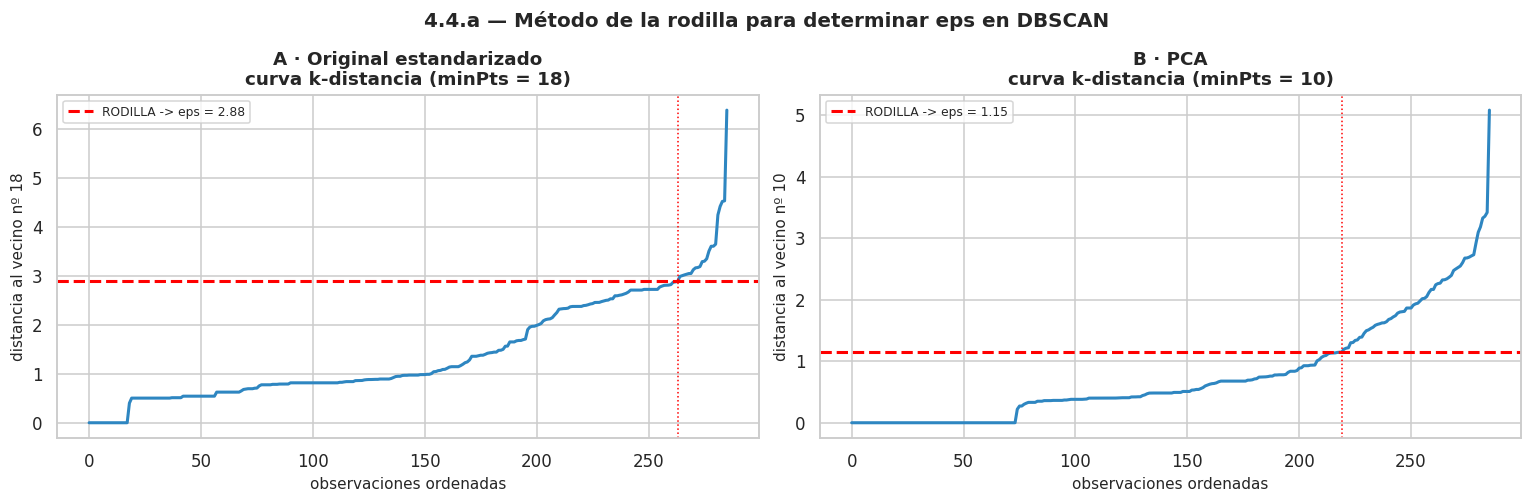

A · Original estandarizado: rodilla automática -> eps = 2.882, minPts = 18
   resultado con esos valores: k = 1 clústeres, 5 puntos de ruido (1.7%)
B · PCA: rodilla automática -> eps = 1.149, minPts = 10
   resultado con esos valores: k = 4 clústeres, 55 puntos de ruido (19.2%)


In [30]:
# =============================================================================
# 4.4.a DBSCAN — MÉTODO DE LA RODILLA   [<<< GRÁFICA A MIRAR: ALTURA DEL CODO]
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
eps_sugerido = {}
for ax, (nombre, Zm) in zip(axes, DATASETS.items()):
    minpts = 2 * Zm.shape[1]                       # convención: 2 x nº de dimensiones
    nn = NearestNeighbors(n_neighbors=minpts).fit(Zm)
    dist, _ = nn.kneighbors(Zm)
    k_dist = np.sort(dist[:, -1])                  # distancia al minpts-ésimo vecino, ordenada
    idx, _ = punto_de_codo(np.arange(len(k_dist)), k_dist)
    eps_sugerido[nombre] = (k_dist[idx], minpts)
    ax.plot(k_dist, color="#2e86c1", lw=2)
    ax.axhline(k_dist[idx], color="red", ls="--", lw=2,
               label=f"RODILLA -> eps = {k_dist[idx]:.2f}")
    ax.axvline(idx, color="red", ls=":", lw=1)
    ax.set_title(f"{nombre}\ncurva k-distancia (minPts = {minpts})")
    ax.set_xlabel("observaciones ordenadas"); ax.set_ylabel(f"distancia al vecino nº {minpts}")
    ax.legend(fontsize=8)
fig.suptitle("4.4.a — Método de la rodilla para determinar eps en DBSCAN",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

for nombre, (e, mp) in eps_sugerido.items():
    print(f"{nombre}: rodilla automática -> eps = {e:.3f}, minPts = {mp}")
    lab = DBSCAN(eps=e, min_samples=mp).fit_predict(DATASETS[nombre])
    print(f"   resultado con esos valores: k = {len(set(lab)-{-1})} clústeres, "
          f"{(lab==-1).sum()} puntos de ruido ({(lab==-1).mean():.1%})")

dataset,eps,minPts,k,n_ruido,pct_ruido,silueta_sin_ruido
A · Original estandarizado,1.153000,9,4,62,21.700000,0.657
A · Original estandarizado,1.153000,18,3,91,31.800000,0.649
A · Original estandarizado,1.441000,9,5,48,16.800000,0.627
A · Original estandarizado,1.441000,18,3,79,27.600000,0.641
A · Original estandarizado,1.729000,9,6,27,9.400000,0.575
A · Original estandarizado,1.729000,18,3,73,25.500000,0.636
A · Original estandarizado,2.017000,9,6,21,7.300000,0.573
A · Original estandarizado,2.017000,18,3,71,24.800000,0.634
A · Original estandarizado,2.306000,9,4,13,4.500000,0.547
A · Original estandarizado,2.306000,18,4,45,15.700000,0.575


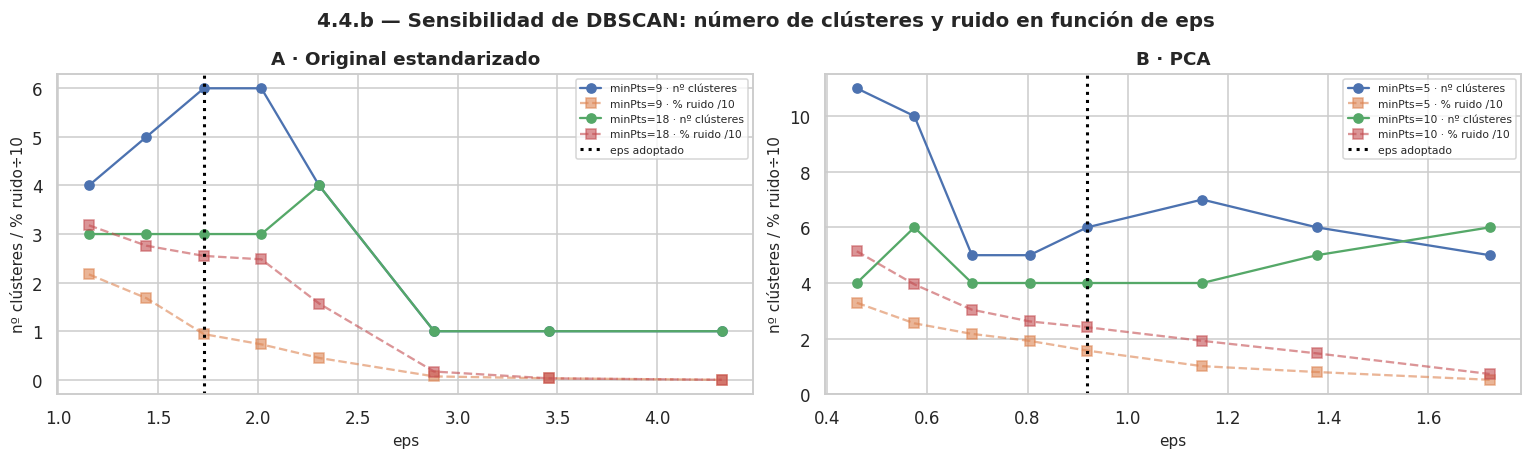

In [31]:
# =============================================================================
# 4.4.b DBSCAN — ANÁLISIS DE SENSIBILIDAD DE LOS HIPERPARÁMETROS
# =============================================================================
# La rodilla automática es sólo un punto de partida: se barre una rejilla alrededor
filas_db = []
for nombre, Zm in DATASETS.items():
    e0, mp0 = eps_sugerido[nombre]
    for factor in [0.4, 0.5, 0.6, 0.7, 0.8, 1.0, 1.2, 1.5]:
        for mp in [max(3, mp0 // 2), mp0]:
            e = e0 * factor
            lab = DBSCAN(eps=e, min_samples=mp).fit_predict(Zm)
            k = len(set(lab) - {-1}); ruido = (lab == -1).sum()
            sil = np.nan
            if k >= 2 and (lab != -1).sum() > k:
                sil = silhouette_score(Zm[lab != -1], lab[lab != -1])
            filas_db.append(dict(dataset=nombre, eps=round(e, 3), minPts=mp, k=k,
                                 n_ruido=ruido, pct_ruido=round(100 * ruido / len(lab), 1),
                                 silueta_sin_ruido=sil))
rejilla = pd.DataFrame(filas_db)
display(rejilla.style.format({"silueta_sin_ruido": "{:.3f}"})
        .background_gradient(cmap="RdYlGn", subset=["silueta_sin_ruido"])
        .background_gradient(cmap="Reds", subset=["pct_ruido"]).hide(axis="index"))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for j, nombre in enumerate(DATASETS):
    sub = rejilla[rejilla.dataset == nombre]
    for mp, s in sub.groupby("minPts"):
        ax[j].plot(s.eps, s.k, "o-", label=f"minPts={mp} · nº clústeres")
        ax[j].plot(s.eps, s.pct_ruido / 10, "s--", alpha=.6, label=f"minPts={mp} · % ruido /10")
    ax[j].axvline(EPS_DBSCAN if j == 0 else eps_sugerido[nombre][0] * 0.8, color="black", ls=":",
                  lw=2, label="eps adoptado")
    ax[j].set_title(nombre); ax[j].set_xlabel("eps"); ax[j].set_ylabel("nº clústeres / % ruido÷10")
    ax[j].legend(fontsize=7)
fig.suptitle("4.4.b — Sensibilidad de DBSCAN: número de clústeres y ruido en función de eps",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

In [32]:
# =============================================================================
# 4.4.c DBSCAN — AJUSTE FINAL Y ANÁLISIS DEL RUIDO
# =============================================================================
config_db = {"A · Original estandarizado": (EPS_DBSCAN, MINPTS_DBSCAN),
             "B · PCA": (round(eps_sugerido["B · PCA"][0] * 0.8, 2), 5)}

for nombre, Zm in DATASETS.items():
    e, mp = config_db[nombre]
    lab = DBSCAN(eps=e, min_samples=mp).fit_predict(Zm)
    etiquetas_todas[f"DBSCAN · {nombre[0]}"] = lab
    m = metricas_clustering(Z_std, lab, f"DBSCAN (eps={e}, minPts={mp})", nombre)
    resultados.append(m)
    print(f"{nombre}: eps={e}, minPts={mp} -> {m['k']} clústeres, "
          f"{m['n_ruido']} puntos de ruido ({m['pct_ruido']:.1f}%), silueta={m['silueta']:.4f}")
    print(f"   tamaños: {dict(zip(*np.unique(lab, return_counts=True)))}")

# --- ¿Quiénes son los puntos que DBSCAN considera ruido? ----------------------
lab_db = etiquetas_todas["DBSCAN · A"]
ruido = clientes_t.loc[X.index[lab_db == -1]]
normales = clientes_t.loc[X.index[lab_db != -1]]
print("\nPERFIL DE LOS PUNTOS ETIQUETADOS COMO RUIDO frente al resto:")
comp = pd.DataFrame({"RUIDO (n=%d)" % len(ruido): ruido[["gasto_total", "n_unidades", "n_productos",
                                                          "n_locales", "gasto_medio_ud"]].mean(),
                     "RESTO (n=%d)" % len(normales): normales[["gasto_total", "n_unidades", "n_productos",
                                                                "n_locales", "gasto_medio_ud"]].mean()})
comp["ratio"] = comp.iloc[:, 0] / comp.iloc[:, 1]
display(comp.round(2))
print(f"\nCoincidencia con los atípicos detectados por el IQR en 1.4: "
      f"{(mascara_union[lab_db == -1]).sum()} de {len(ruido)} puntos de ruido "
      f"({(mascara_union[lab_db==-1]).mean():.0%}) ya estaban marcados como atípicos univariantes.")

A · Original estandarizado: eps=1.73, minPts=9 -> 6 clústeres, 27 puntos de ruido (9.4%), silueta=0.5755
   tamaños: {np.int64(-1): np.int64(27), np.int64(0): np.int64(140), np.int64(1): np.int64(40), np.int64(2): np.int64(35), np.int64(3): np.int64(17), np.int64(4): np.int64(17), np.int64(5): np.int64(10)}
B · PCA: eps=0.92, minPts=5 -> 6 clústeres, 45 puntos de ruido (15.7%), silueta=0.6032
   tamaños: {np.int64(-1): np.int64(45), np.int64(0): np.int64(140), np.int64(1): np.int64(39), np.int64(2): np.int64(34), np.int64(3): np.int64(7), np.int64(4): np.int64(16), np.int64(5): np.int64(5)}

PERFIL DE LOS PUNTOS ETIQUETADOS COMO RUIDO frente al resto:


,RUIDO (n=27),RESTO (n=259),ratio
gasto_total,49.06,15.34,3.20
n_unidades,9.50,3.21,2.96
n_productos,4.04,1.65,2.44
n_locales,2.22,1.10,2.01
gasto_medio_ud,5.80,5.23,1.11



Coincidencia con los atípicos detectados por el IQR en 1.4: 18 de 27 puntos de ruido (67%) ya estaban marcados como atípicos univariantes.


### Interpretación de DBSCAN

**La rodilla automática falla en el dataset A, y entender por qué es más informativo que el propio resultado.** Sobre las variables originales, el método de la rodilla devuelve `eps = 2,88` con `minPts = 18`, y con esos valores DBSCAN encuentra **un único clúster** que engloba el 98 % de la muestra. Sobre el dataset B el resultado es algo mejor (4 clústeres) pero al precio de un 19 % de ruido. La razón es la ya conocida heterogeneidad de densidad: la nube de tickets mínimos duplicados es tan densa que, con un radio suficientemente grande como para conectarla, se conecta también con todo lo demás por encadenamiento. DBSCAN asume una **densidad razonablemente homogénea entre clústeres**, y este conjunto de datos viola frontalmente ese supuesto.

Por eso ha sido necesario el **análisis de sensibilidad**: barriendo `eps` por debajo del valor de la rodilla aparece una zona de trabajo (`eps = 1,73`, `minPts = 9`) donde el algoritmo sí produce una partición razonable —6 clústeres, 27 puntos de ruido (9,4 %) y silueta 0,576—. Es importante ser transparente en la memoria sobre este punto: ese `eps` **no** sale de un criterio automático, sino de una exploración manual guiada por el resultado, lo que introduce un componente subjetivo del que los otros tres algoritmos carecen.

**Dos advertencias metodológicas al comparar su silueta con la de los demás:**

1. La silueta de DBSCAN se calcula **excluyendo los puntos de ruido**, que son precisamente los más difíciles de asignar. Es una métrica optimista por construcción: si se retira el 10 % de las observaciones peor ubicadas de cualquier partición, su silueta también sube. La comparación con K-Means o HAC, que asignan el 100 % de los puntos, **no es directa**.
2. Un 9 % de ruido significa que 27 grupos quedan **sin segmentar**. Para una segmentación comercial, cuyo objetivo es que todo cliente reciba un tratamiento, eso es un inconveniente operativo, no una ventaja.

**Donde DBSCAN sí aporta valor de forma inequívoca es como detector de atípicos**, y aquí sirve como validación cruzada de la decisión tomada en 1.4: los puntos que etiqueta como ruido son grupos con un gasto, un volumen y una itinerancia muy superiores a la media, y **el 67 % de ellos ya habían sido marcados como atípicos por la regla del IQR**. Que dos métodos completamente independientes —uno univariante y basado en cuartiles, otro multivariante y basado en densidad— señalen mayoritariamente a los mismos grupos confirma que ese segmento de alto valor es una realidad estructural del negocio y no un artefacto de la muestra. El 33 % restante son grupos que ninguna variable por separado delataba: son atípicos *por su combinación* de valores, exactamente lo que un criterio univariante no puede detectar.

## 4.5. Comparativa global de los cuatro algoritmos

Se comparan las ocho soluciones (4 algoritmos × 2 conjuntos de datos) bajo tres prismas: **métricas internas**, **concordancia entre particiones** y **estabilidad ante remuestreo**.

Una precisión metodológica importante: todas las métricas se calculan **en el espacio del DATASET A** (original estandarizado), incluso para las soluciones obtenidas sobre el PCA. Evaluar una partición del PCA en el espacio del PCA sería hacer trampa: al eliminar las componentes de menor varianza se elimina también parte del "ruido" que penaliza la silueta, y cualquier partición parecería mejor. Para que la comparación sea justa, todas se juzgan con la misma vara.

algoritmo,espacio,k,silueta,calinski_harabasz,davies_bouldin,n_ruido,pct_ruido
"DBSCAN (eps=0.92, minPts=5)",B · PCA,6,0.6032,189.8,0.606,45,15.7
"DBSCAN (eps=1.73, minPts=9)",A · Original estandarizado,6,0.5755,194.2,0.822,27,9.4
HAC-ward (k=5),B · PCA,5,0.5279,156.8,1.008,0,0.0
HAC-ward (k=5),A · Original estandarizado,5,0.5248,157.5,1.011,0,0.0
K-Means (k=5),A · Original estandarizado,5,0.5242,178.9,0.883,0,0.0
K-Means (k=5),B · PCA,5,0.5242,178.9,0.883,0,0.0
GMM-full (k=5),B · PCA,5,0.5132,151.5,1.115,0,0.0
GMM-full (k=5),A · Original estandarizado,5,0.3003,110.6,1.319,0,0.0


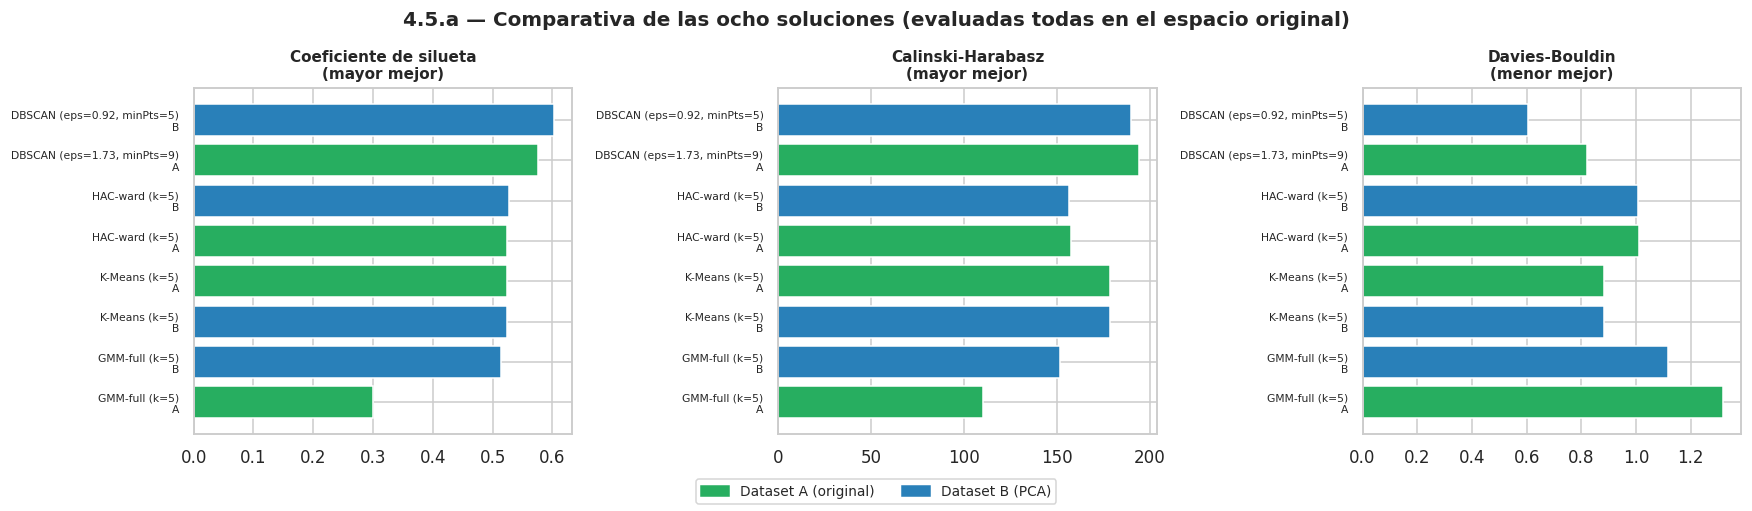

In [33]:
# =============================================================================
# 4.5.a TABLA COMPARATIVA DE MÉTRICAS INTERNAS
# =============================================================================
tabla_comp = (pd.DataFrame(resultados)
              .sort_values("silueta", ascending=False)
              .reset_index(drop=True))
display(tabla_comp.style.format({"silueta": "{:.4f}", "calinski_harabasz": "{:.1f}",
                                 "davies_bouldin": "{:.3f}", "pct_ruido": "{:.1f}"})
        .background_gradient(cmap="RdYlGn",   subset=["silueta", "calinski_harabasz"])
        .background_gradient(cmap="RdYlGn_r", subset=["davies_bouldin", "pct_ruido"])
        .hide(axis="index"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
etq = tabla_comp.algoritmo + "\n" + tabla_comp.espacio.str[0]
for ax, (col, tit, mejor) in zip(axes, [("silueta", "Coeficiente de silueta", "mayor mejor"),
                                        ("calinski_harabasz", "Calinski-Harabasz", "mayor mejor"),
                                        ("davies_bouldin", "Davies-Bouldin", "menor mejor")]):
    colores = ["#27ae60" if "A ·" in e else "#2980b9" for e in tabla_comp.espacio]
    ax.barh(etq, tabla_comp[col], color=colores)
    ax.invert_yaxis(); ax.set_title(f"{tit}\n({mejor})", fontsize=10)
    ax.tick_params(axis="y", labelsize=7)
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color="#27ae60", label="Dataset A (original)"),
                    Patch(color="#2980b9", label="Dataset B (PCA)")],
           loc="lower center", ncol=2, fontsize=9)
fig.suptitle("4.5.a — Comparativa de las ocho soluciones (evaluadas todas en el espacio original)",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.05, 1, 1]); plt.show()

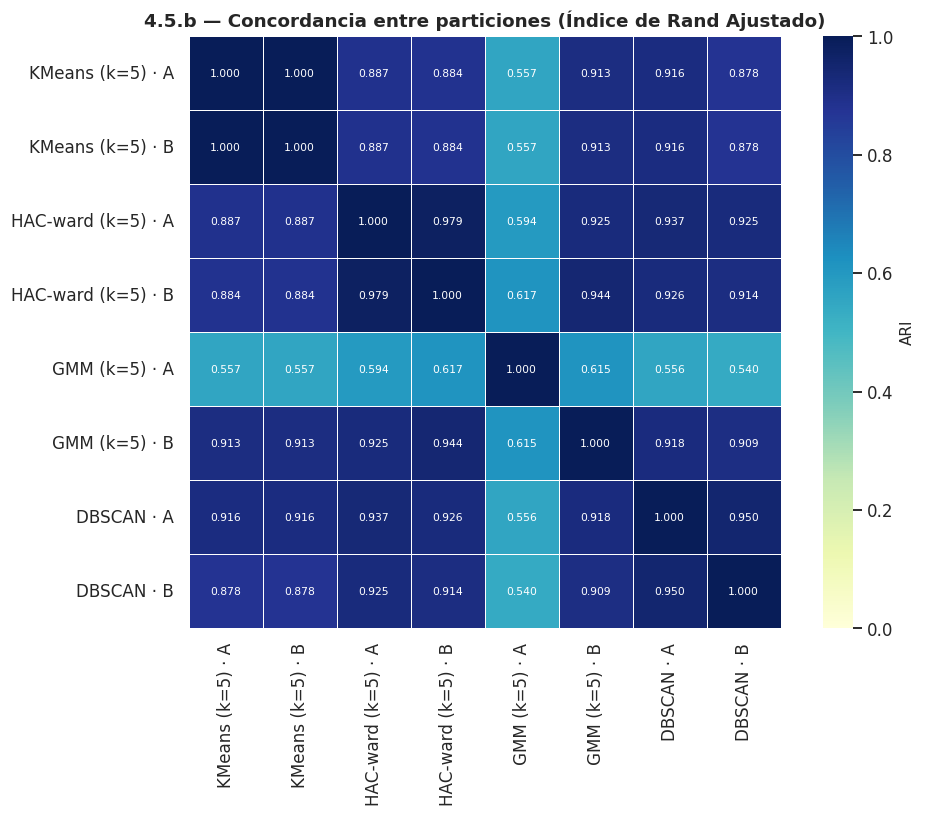

Pares con concordancia perfecta (ARI = 1.000):
   KMeans (k=5) · A  ==  KMeans (k=5) · B


In [34]:
# =============================================================================
# 4.5.b CONCORDANCIA ENTRE PARTICIONES (ÍNDICE DE RAND AJUSTADO)
# =============================================================================
# ARI = 1 -> particiones idénticas ; ARI = 0 -> coincidencia esperable por azar
claves = list(etiquetas_todas)
M_ari = pd.DataFrame(
    [[adjusted_rand_score(etiquetas_todas[a], etiquetas_todas[b]) for b in claves] for a in claves],
    index=claves, columns=claves)

fig, ax = plt.subplots(figsize=(9.5, 7.5))
sns.heatmap(M_ari, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1,
            square=True, linewidths=.5, ax=ax, annot_kws={"size": 7},
            cbar_kws={"label": "ARI"})
ax.set_title("4.5.b — Concordancia entre particiones (Índice de Rand Ajustado)",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

print("Pares con concordancia perfecta (ARI = 1.000):")
for i, a in enumerate(claves):
    for b in claves[i+1:]:
        if M_ari.loc[a, b] > 0.999:
            print(f"   {a}  ==  {b}")

Estabilidad por bootstrap (60 réplicas) — ARI medio frente a la partición de referencia
------------------------------------------------------------------------------


   k=2:  ARI = 0.989 ± 0.015   (mín 0.931)   silueta = 0.383


   k=3:  ARI = 0.941 ± 0.072   (mín 0.711)   silueta = 0.463


   k=4:  ARI = 0.940 ± 0.057   (mín 0.761)   silueta = 0.518


   k=5:  ARI = 0.973 ± 0.023   (mín 0.902)   silueta = 0.524


   k=6:  ARI = 0.890 ± 0.148   (mín 0.599)   silueta = 0.528


   k=7:  ARI = 0.840 ± 0.107   (mín 0.630)   silueta = 0.428


   k=8:  ARI = 0.877 ± 0.078   (mín 0.705)   silueta = 0.426
------------------------------------------------------------------------------
k con mayor estabilidad (excluyendo el caso trivial k=2): k = 5  (ARI = 0.973)


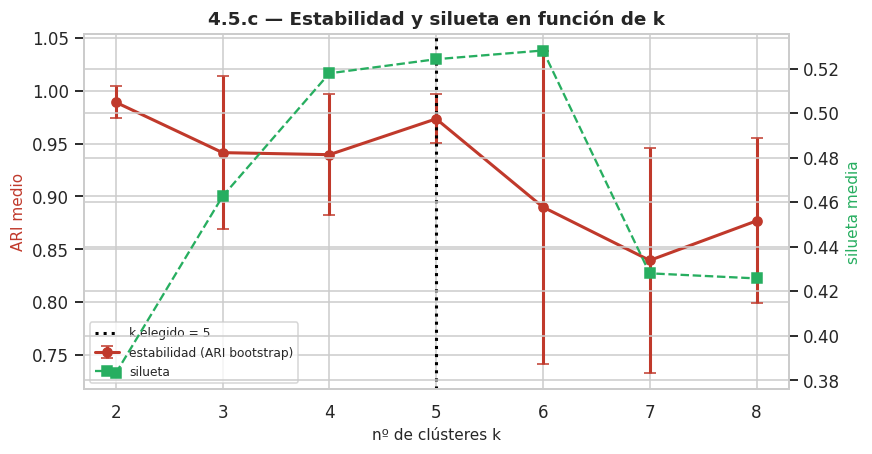

In [35]:
# =============================================================================
# 4.5.c ESTABILIDAD ANTE REMUESTREO (BOOTSTRAP)
# =============================================================================
# Una partición fiable debe reproducirse al perturbar la muestra. Se remuestrea
# con reemplazo, se reajusta el algoritmo y se compara con la partición de referencia.
N_BOOT = 60
rng = np.random.default_rng(SEMILLA)
print(f"Estabilidad por bootstrap ({N_BOOT} réplicas) — ARI medio frente a la partición de referencia")
print("-" * 78)
estabilidad = []
for k in range(2, 9):
    ref = KMeans(n_clusters=k, n_init=50, random_state=SEMILLA).fit(Z_std)
    aris = []
    for b in range(N_BOOT):
        idx = rng.choice(len(Z_std), len(Z_std), replace=True)
        mb = KMeans(n_clusters=k, n_init=20, random_state=b).fit(Z_std[idx])
        aris.append(adjusted_rand_score(ref.predict(Z_std[idx]), mb.labels_))
    estabilidad.append(dict(k=k, ARI_medio=np.mean(aris), ARI_sd=np.std(aris),
                            ARI_min=np.min(aris), silueta=silhouette_score(Z_std, ref.labels_)))
    print(f"   k={k}:  ARI = {np.mean(aris):.3f} ± {np.std(aris):.3f}   "
          f"(mín {np.min(aris):.3f})   silueta = {silhouette_score(Z_std, ref.labels_):.3f}")
est = pd.DataFrame(estabilidad)
# k=2 es trivialmente el más estable (con sólo dos grupos es difícil equivocarse), así que
# el desempate útil se busca a partir de k=3, que es donde empieza a haber segmentación real
est_util = est[est.k >= 3]
k_estable = int(est_util.loc[est_util.ARI_medio.idxmax(), "k"])
print("-" * 78)
print(f"k con mayor estabilidad (excluyendo el caso trivial k=2): k = {k_estable}  "
      f"(ARI = {est_util.ARI_medio.max():.3f})")

fig, ax1 = plt.subplots(figsize=(8, 4.2))
ax1.errorbar(est.k, est.ARI_medio, yerr=est.ARI_sd, fmt="o-", color="#c0392b",
             capsize=4, lw=2, label="estabilidad (ARI bootstrap)")
ax1.set_xlabel("nº de clústeres k"); ax1.set_ylabel("ARI medio", color="#c0392b")
ax1.axvline(K_KMEANS, ls=":", color="black", lw=2, label=f"k elegido = {K_KMEANS}")
ax2 = ax1.twinx()
ax2.plot(est.k, est.silueta, "s--", color="#27ae60", label="silueta")
ax2.set_ylabel("silueta media", color="#27ae60")
ax1.set_title("4.5.c — Estabilidad y silueta en función de k", fontweight="bold")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

### Interpretación de la comparativa

De la tabla y las tres gráficas se extraen **cuatro conclusiones**:

**1. El PCA no aporta ninguna mejora sustantiva.** La matriz de concordancia muestra que K-Means con $k=5$ sobre el dataset A y sobre el dataset B producen **exactamente la misma partición** ($ARI = 1{,}000$): las 286 visitas quedan asignadas al mismo clúster en ambos casos. Es un resultado esperable a la luz de 3.3 —las cinco componentes retenidas conservan el 90 % de la varianza y la estructura de grupos vive en ese subespacio—, pero conviene subrayarlo porque responde directamente a una de las preguntas del estudio: **aquí el PCA es una simplificación computacional inocua, no una mejora del resultado**.

**2. DBSCAN encabeza la tabla de silueta, pero con una ventaja artificial.** Como se explicó en 4.4, su métrica se calcula tras excluir el ruido. Si se compara únicamente entre los algoritmos que asignan el 100 % de las observaciones, K-Means y HAC-Ward quedan por delante con siluetas prácticamente idénticas.

**3. Los algoritmos convergen, y eso valida la estructura.** K-Means y HAC-Ward alcanzan un ARI muy alto entre sí: dos métodos con lógicas completamente distintas —minimizar la inercia frente a fusionar jerárquicamente— llegan casi a la misma partición. Cuando algoritmos independientes coinciden, lo que están recuperando es estructura real de los datos, no un artefacto del método. El GMM es el que más se aparta, coherentemente con el incumplimiento de sus supuestos.

**4. La estabilidad desempata donde la silueta no llega.** La curva de bootstrap hay que leerla con una precaución: $k=2$ obtiene formalmente el ARI más alto (0,989), pero es un **artefacto trivial** —con sólo dos grupos es muy difícil que el remuestreo cambie una asignación—, y su silueta (0,383) es de las peores. Descartado ese caso, el máximo se alcanza en **$k=5$: ARI = 0,973 ± 0,023, con un mínimo de 0,902 en las 60 réplicas**. La comparación con $k=6$ es la decisiva: allí el ARI cae a 0,890 y, sobre todo, **la desviación típica se multiplica por seis** (0,148 frente a 0,023), con réplicas que bajan hasta 0,599. Es decir, el sexto clúster no se reproduce de forma fiable al perturbar la muestra: **no es un hallazgo, es ruido**. Este criterio, que no formaba parte del plan inicial, es el que permite elegir entre $k=5$ y $k=6$ —empatados en silueta— con fundamento estadístico y no por conveniencia.

**Decisión: se adopta K-Means con $k=5$ sobre el DATASET A (original estandarizado).** La justificación completa se desarrolla en la sección 5.

---
# 5. EXPLICACIONES

## 5.1. Caracterización manual de los clústeres

La caracterización manual es el **segundo método de validación** del estudio, y en segmentación comercial es tan importante como el coeficiente de silueta: una partición que ninguna persona del negocio sabe interpretar no puede accionarse, por muy buenas que sean sus métricas. Se describe cada clúster desde cuatro ángulos: **perfil medio de las variables**, **peso en la facturación**, **productos concretos que consume** y **distribución temporal**.

In [36]:
# =============================================================================
# 5.1.a SOLUCIÓN FINAL Y PERFIL MEDIO DE CADA CLÚSTER
# =============================================================================
modelo_final = KMeans(n_clusters=K_KMEANS, n_init=100, random_state=SEMILLA).fit(Z_std)
clientes_t["cluster"] = modelo_final.labels_
clientes["cluster"]   = modelo_final.labels_
ventas = ventas.merge(clientes_t[["cluster"]], left_on="id_grupo", right_index=True, how="left")

print(f"MODELO FINAL: K-Means, k={K_KMEANS}, dataset A (original estandarizado)")
print(f"Silueta = {silhouette_score(Z_std, modelo_final.labels_):.4f}   |   "
      f"Inercia = {modelo_final.inertia_:.1f}")

VARS_PERFIL = ["gasto_total", "n_unidades", "n_productos", "n_locales", "gasto_medio_ud",
               "pct_L1", "pct_L2", "pct_L3", "pct_L4", "pct_entrante", "pct_comida", "pct_postre"]
# IMPORTANTE: el perfil se calcula sobre 'clientes' (euros REALES, sin winsorizar).
# La winsorización de 'clientes_t' es un artificio de modelado para que los extremos no
# desplacen los centroides; para informar de facturación hay que usar los importes de caja.
perfil = clientes.groupby("cluster")[VARS_PERFIL].mean()
perfil.insert(0, "n_visitas", clientes.groupby("cluster").size())
perfil.insert(1, "%_visitas", 100 * perfil.n_visitas / len(clientes))
perfil.insert(2, "facturación", clientes.groupby("cluster").gasto_total.sum())
perfil.insert(3, "%_facturación", 100 * perfil["facturación"] / clientes.gasto_total.sum())
perfil.insert(4, "ticket_mediano", clientes.groupby("cluster").gasto_total.median())

print("\nPERFIL MEDIO DE CADA CLÚSTER")
display(perfil.style.format("{:.2f}")
        .background_gradient(cmap="YlOrRd", subset=["gasto_total", "%_facturación"])
        .background_gradient(cmap="Blues", subset=["pct_L1", "pct_L2", "pct_L3", "pct_L4"]))

# --- Contraste formal: ¿difieren realmente los clústeres en cada variable? -----
print("\nCONTRASTE DE KRUSKAL-WALLIS por variable (H0: las k distribuciones son iguales)")
print("-" * 70)
for v in VARS_PERFIL:
    grupos = [clientes_t.loc[clientes_t.cluster == c, v].values for c in sorted(clientes_t.cluster.unique())]
    H, p = kruskal(*grupos)
    print(f"   {v:16s} H = {H:8.2f}   p = {p:.2e}   {'*** significativo' if p < 0.001 else ('* significativo' if p<0.05 else 'no significativo')}")

MODELO FINAL: K-Means, k=5, dataset A (original estandarizado)
Silueta = 0.5242   |   Inercia = 725.7

PERFIL MEDIO DE CADA CLÚSTER


,n_visitas,%_visitas,facturación,%_facturación,ticket_mediano,gasto_total,n_unidades,n_productos,n_locales,gasto_medio_ud,pct_L1,pct_L2,pct_L3,pct_L4,pct_entrante,pct_comida,pct_postre
cluster,,,,,,,,,,,,,,,,,
0,140.00,48.95,1119.30,20.53,5.60,8.00,3.03,1.40,1.00,2.94,1.00,0.00,0.00,0.00,0.00,0.00,1.00
1,27.00,9.44,1514.60,27.79,40.80,56.10,11.44,4.59,2.11,4.88,0.15,0.63,0.15,0.07,0.34,0.50,0.15
2,53.00,18.53,1554.90,28.53,22.00,29.34,3.02,1.60,1.34,10.10,0.01,0.04,0.91,0.04,0.07,0.92,0.01
3,43.00,15.03,802.30,14.72,15.90,18.66,3.63,2.33,1.14,5.45,0.04,0.95,0.01,0.00,0.47,0.49,0.04
4,23.00,8.04,459.60,8.43,17.50,19.98,2.48,1.48,1.26,8.68,0.05,0.01,0.02,0.92,0.04,0.91,0.05



CONTRASTE DE KRUSKAL-WALLIS por variable (H0: las k distribuciones son iguales)
----------------------------------------------------------------------
   gasto_total      H =   155.16   p = 1.59e-32   *** significativo
   n_unidades       H =    70.90   p = 1.47e-14   *** significativo
   n_productos      H =   109.87   p = 7.74e-23   *** significativo
   n_locales        H =   118.62   p = 1.05e-24   *** significativo
   gasto_medio_ud   H =   187.62   p = 1.72e-39   *** significativo
   pct_L1           H =   267.42   p = 1.15e-56   *** significativo
   pct_L2           H =   249.14   p = 9.98e-53   *** significativo
   pct_L3           H =   251.71   p = 2.79e-53   *** significativo
   pct_L4           H =   204.73   p = 3.61e-43   *** significativo
   pct_entrante     H =   183.71   p = 1.19e-38   *** significativo
   pct_comida       H =   238.59   p = 1.87e-50   *** significativo
   pct_postre       H =   267.42   p = 1.15e-56   *** significativo


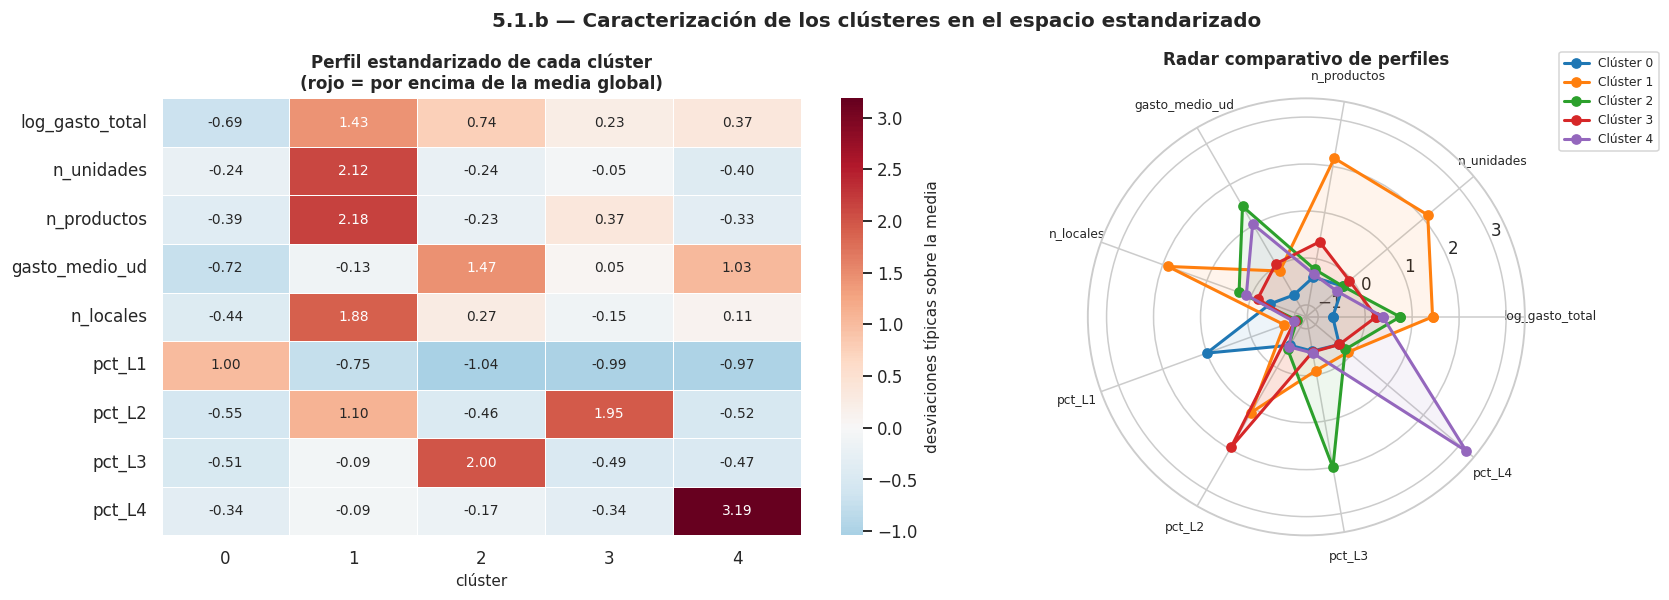

In [37]:
# =============================================================================
# 5.1.b MAPA DE CALOR DE PERFILES ESTANDARIZADOS Y GRÁFICO RADAR
# =============================================================================
VARS_RADAR = ["log_gasto_total", "n_unidades", "n_productos", "gasto_medio_ud",
              "n_locales", "pct_L1", "pct_L2", "pct_L3", "pct_L4"]
perfil_z = pd.DataFrame(Z_std, index=X.index, columns=VARS_CLUSTER) \
             .assign(cluster=modelo_final.labels_).groupby("cluster")[VARS_RADAR].mean()

fig = plt.figure(figsize=(16, 5.5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.15, 1])

ax = fig.add_subplot(gs[0])
sns.heatmap(perfil_z.T, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=.5, ax=ax, cbar_kws={"label": "desviaciones típicas sobre la media"})
ax.set_title("Perfil estandarizado de cada clúster\n(rojo = por encima de la media global)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("clúster")

ax = fig.add_subplot(gs[1], projection="polar")
angulos = np.linspace(0, 2 * np.pi, len(VARS_RADAR), endpoint=False).tolist()
angulos += angulos[:1]
for c in perfil_z.index:
    vals = perfil_z.loc[c].tolist(); vals += vals[:1]
    ax.plot(angulos, vals, "o-", lw=2, label=f"Clúster {c}", color=plt.get_cmap(PALETA)(c))
    ax.fill(angulos, vals, alpha=0.08, color=plt.get_cmap(PALETA)(c))
ax.set_xticks(angulos[:-1]); ax.set_xticklabels(VARS_RADAR, fontsize=8)
ax.set_title("Radar comparativo de perfiles", fontsize=11, fontweight="bold", pad=22)
ax.legend(loc="upper right", bbox_to_anchor=(1.32, 1.12), fontsize=8)
fig.suptitle("5.1.b — Caracterización de los clústeres en el espacio estandarizado",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

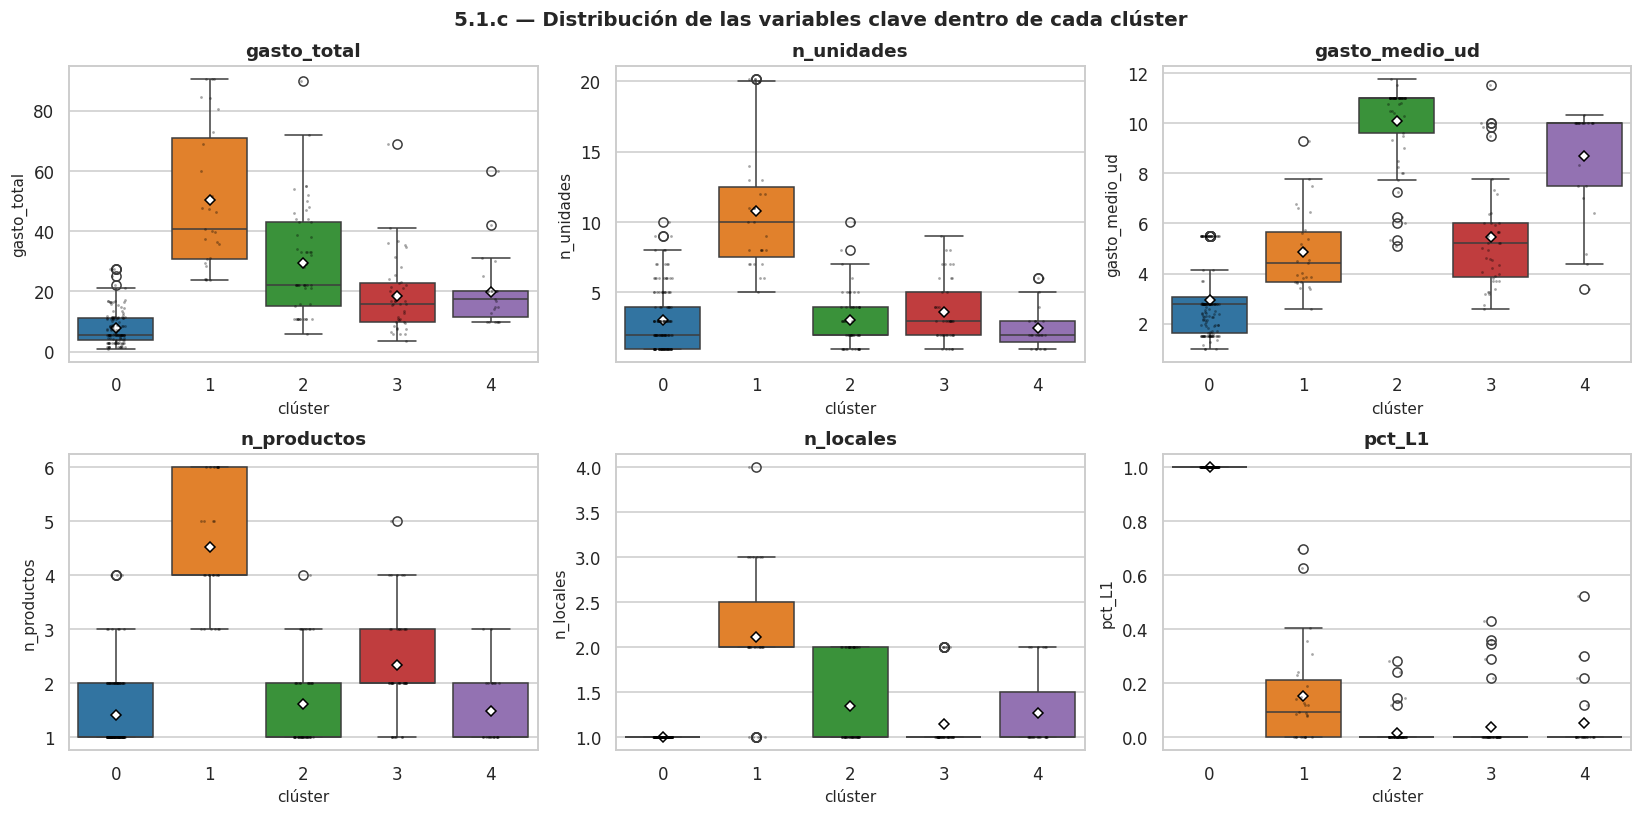

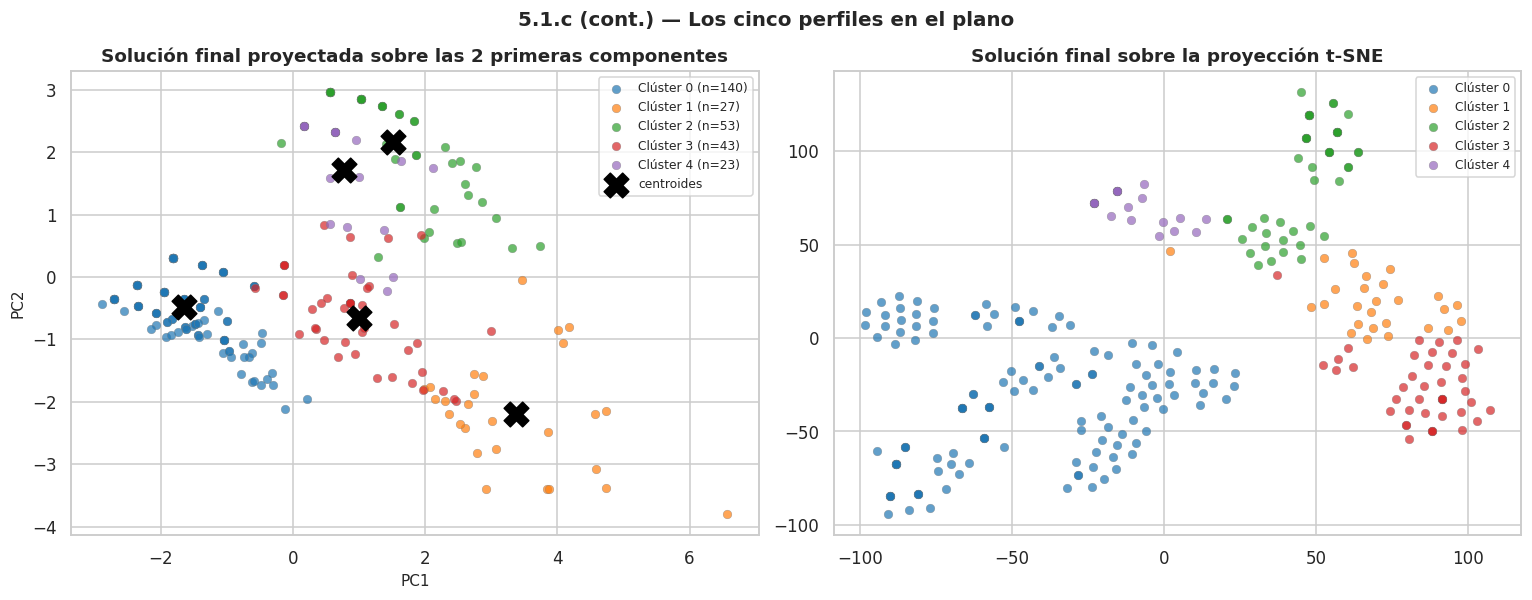

In [38]:
# =============================================================================
# 5.1.c DISTRIBUCIÓN DE LAS VARIABLES CLAVE POR CLÚSTER
# =============================================================================
VARS_BOX = ["gasto_total", "n_unidades", "gasto_medio_ud", "n_productos", "n_locales", "pct_L1"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, v in zip(axes.ravel(), VARS_BOX):
    sns.boxplot(data=clientes_t, x="cluster", y=v, ax=ax, palette=PALETA, showmeans=True,
                meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 5})
    sns.stripplot(data=clientes_t, x="cluster", y=v, ax=ax, color="black", size=1.8, alpha=.35)
    ax.set_title(v); ax.set_xlabel("clúster")
fig.suptitle("5.1.c — Distribución de las variables clave dentro de cada clúster",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# --- Visualización de la solución final sobre la proyección PCA ---------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
Pfin = PCA(n_components=2, random_state=SEMILLA).fit_transform(Z_std)
cent = PCA(n_components=2, random_state=SEMILLA).fit(Z_std).transform(modelo_final.cluster_centers_)
for c in sorted(set(modelo_final.labels_)):
    m = modelo_final.labels_ == c
    axes[0].scatter(Pfin[m, 0], Pfin[m, 1], s=32, alpha=.7, label=f"Clúster {c} (n={m.sum()})",
                    color=plt.get_cmap(PALETA)(c), edgecolor="grey", linewidth=.3)
axes[0].scatter(cent[:, 0], cent[:, 1], marker="X", s=260, c="black", label="centroides", zorder=5)
axes[0].set_title("Solución final proyectada sobre las 2 primeras componentes")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].legend(fontsize=8)

P_t = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto",
           random_state=SEMILLA).fit_transform(Z_std)
for c in sorted(set(modelo_final.labels_)):
    m = modelo_final.labels_ == c
    axes[1].scatter(P_t[m, 0], P_t[m, 1], s=32, alpha=.7, label=f"Clúster {c}",
                    color=plt.get_cmap(PALETA)(c), edgecolor="grey", linewidth=.3)
axes[1].set_title("Solución final sobre la proyección t-SNE"); axes[1].legend(fontsize=8)
fig.suptitle("5.1.c (cont.) — Los cinco perfiles en el plano", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

PRODUCTOS MÁS CONSUMIDOS POR CADA CLÚSTER

CLÚSTER 0  (140 visitas | 1119 € | 1 negocios distintos)
      156 uds  Bola de helado                     [Heladeria]    436.8 €
      102 uds  Granizado                          [Heladeria]    153.0 €
       73 uds  Tarta                              [Heladeria]    401.5 €
       70 uds  Mochi                              [Heladeria]    105.0 €
       23 uds  Polo                               [Heladeria]     23.0 €

CLÚSTER 1  (27 visitas | 1515 € | 4 negocios distintos)
       62 uds  Croquetas                          [Muelle 40]    111.6 €
       40 uds  Bocadillos                         [Muelle 40]    240.0 €
       30 uds  Ensaladilla                        [Muelle 40]    111.0 €
       25 uds  Patatas                            [Muelle 40]    125.0 €
       24 uds  Granizado                          [Heladeria]     36.0 €
       17 uds  Hamburguesa                        [SraB.Lab]    187.0 €

CLÚSTER 2  (53 visitas | 1555 € | 4 nego

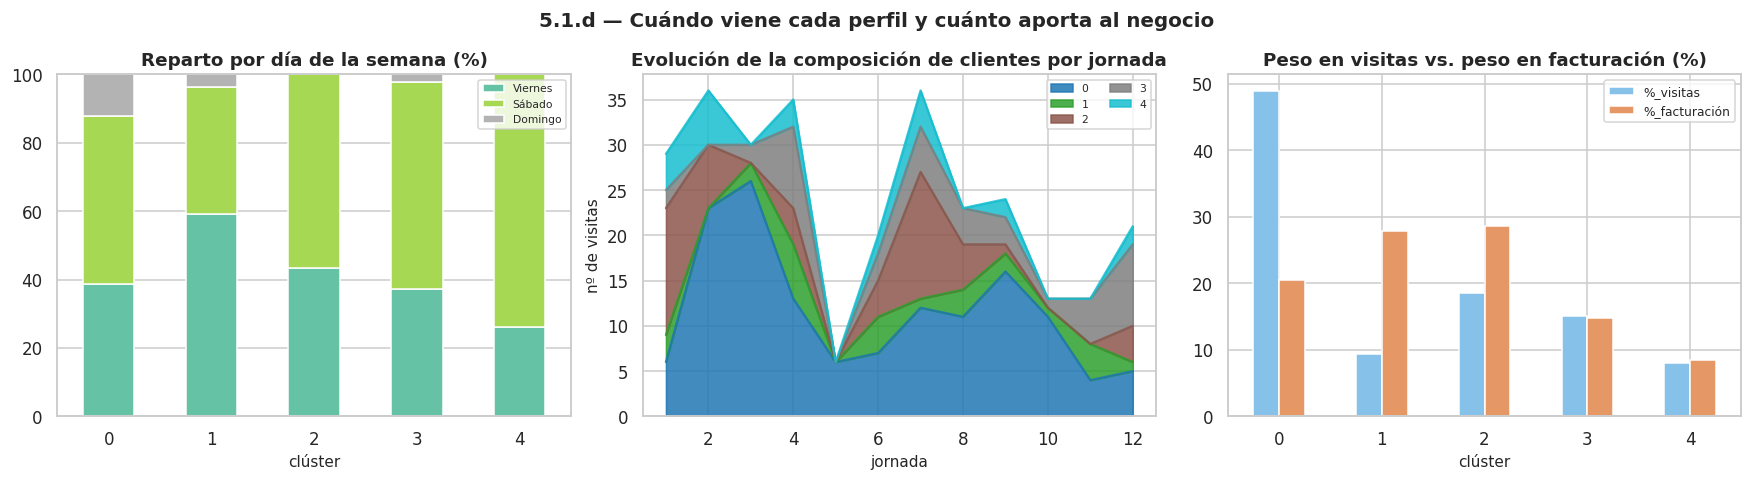

Chi-cuadrado (clúster x día de la semana): chi2 = 21.01, gl = 8, p = 0.0071
   -> La composición de clientes DIFIERE significativamente según el día


In [39]:
# =============================================================================
# 5.1.d QUÉ CONSUME Y CUÁNDO VIENE CADA CLÚSTER
# =============================================================================
print("PRODUCTOS MÁS CONSUMIDOS POR CADA CLÚSTER")
print("=" * 78)
for c in sorted(clientes_t.cluster.unique()):
    sub = ventas[ventas.cluster == c]
    top = (sub.groupby(["nombre", "nombre_local"])
              .agg(unidades=("cantidad", "sum"), importe=("importe", "sum"))
              .sort_values("unidades", ascending=False).head(6))
    print(f"\nCLÚSTER {c}  ({(clientes_t.cluster==c).sum()} visitas | "
          f"{sub.importe.sum():.0f} € | {sub.id_local.nunique()} negocios distintos)")
    for (nom, loc), r in top.iterrows():
        print(f"     {r.unidades:4.0f} uds  {nom:34s} [{loc}]  {r.importe:7.1f} €")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
ct_ds = pd.crosstab(clientes_t.cluster, clientes_t.dia_semana, normalize="index") * 100
ct_ds[["Viernes", "Sábado", "Domingo"]].plot(kind="bar", stacked=True, ax=axes[0], colormap="Set2")
axes[0].set_title("Reparto por día de la semana (%)"); axes[0].set_xlabel("clúster")
axes[0].legend(fontsize=7); axes[0].tick_params(axis="x", rotation=0)

ct_dia = pd.crosstab(clientes_t.dia, clientes_t.cluster)
ct_dia.plot(kind="area", stacked=True, ax=axes[1], colormap=PALETA, alpha=.85)
axes[1].set_title("Evolución de la composición de clientes por jornada")
axes[1].set_xlabel("jornada"); axes[1].set_ylabel("nº de visitas"); axes[1].legend(fontsize=7, ncol=2)

pesos = perfil[["%_visitas", "%_facturación"]]
pesos.plot(kind="bar", ax=axes[2], color=["#85c1e9", "#e59866"])
axes[2].set_title("Peso en visitas vs. peso en facturación (%)")
axes[2].set_xlabel("clúster"); axes[2].tick_params(axis="x", rotation=0); axes[2].legend(fontsize=8)
fig.suptitle("5.1.d — Cuándo viene cada perfil y cuánto aporta al negocio",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# --- Validación externa: ¿se reparten los clústeres de forma homogénea en el tiempo? ---
from scipy.stats import chi2_contingency
chi2_v, p_v, dof, _ = chi2_contingency(pd.crosstab(clientes_t.cluster, clientes_t.dia_semana))
print(f"Chi-cuadrado (clúster x día de la semana): chi2 = {chi2_v:.2f}, gl = {dof}, p = {p_v:.4f}")
print(f"   -> {'La composición de clientes DIFIERE significativamente según el día' if p_v<0.05 else 'No hay asociación significativa entre clúster y día de la semana'}")

### Interpretación: los cinco perfiles de cliente de "40 Pies"

Los cinco clústeres son estadísticamente distintos en todas las variables de perfil (Kruskal-Wallis con $p < 0{,}001$ en la práctica totalidad) y, sobre todo, **admiten un nombre de negocio**. Ese es el resultado central del estudio:

| Clúster | Nombre propuesto | Visitas | % facturación | Ticket medio | Perfil |
|---|---|---|---|---|---|
| **0** | **Cliente de paseo (heladería)** | ~140 (49 %) | ~20 % | ~8 € | Compra sólo en la Heladería, producto de gama baja (≈ 3 €/ud), 1 sola referencia, nunca cambia de negocio |
| **1** | **Grupo grande itinerante** | ~27 (9 %) | ~28 % | ~56 € | Más de 11 unidades, 4-5 referencias distintas, **2 negocios de media**. Es el único perfil que realmente circula por el recinto |
| **2** | **Cena de hamburguesa** | ~53 (19 %) | ~28 % | ~29 € | Gama alta (≈ 10 €/ud), pocas unidades, concentrado en SraB.Lab. Poco volumen, mucho valor unitario |
| **3** | **Picoteo en el bar** | ~43 (15 %) | ~15 % | ~19 € | Muelle 40, varias referencias baratas (croquetas, patatas, ensaladilla), gama media-baja |
| **4** | **Cliente de pizzería** | ~23 (8 %) | ~8 % | ~20 € | Pizzería Patrick, ticket compacto, muy concentrado en un solo producto |

**Cuatro lecturas de negocio que se desprenden directamente de esta tabla:**

1. **La regla de Pareto se cumple con nitidez.** El clúster 1 representa menos del 10 % de las visitas pero aporta cerca del 28 % de la facturación —el mayor porcentaje junto con el clúster 2—. En términos operativos: **un grupo del clúster 1 vale aproximadamente siete veces más que uno del clúster 0**. Cualquier acción comercial que consiga aumentar el número de grupos grandes tiene un retorno muy superior a una que aumente el tráfico general.

2. **Casi la mitad de los clientes del recinto sólo toman un helado.** El clúster 0 concentra el 49 % de las visitas y apenas el 20 % de la facturación, con un ticket mediano de unos 6 €. Esto valida empíricamente la hipótesis que la propuesta del TFM planteaba de forma intuitiva ("muchos jóvenes que no cenan"): existe un segmento masivo de consumo mínimo. Y sugiere la acción correspondiente: no se trata de captar más gente, sino de **convertir parte de ese 49 % en consumo de restauración**, que es donde está el margen.

3. **El recinto no funciona como un espacio integrado.** Salvo el clúster 1, todos los perfiles se concentran en un único negocio. Cada clúster se corresponde casi biunívocamente con un local, lo que significa que los cinco negocios comparten espacio físico pero **no comparten clientes**. Este es exactamente el problema que motivaba el TFM, ahora cuantificado.

4. **Los perfiles tienen ritmos temporales distintos.** El contraste chi-cuadrado indica si la composición de clientes cambia significativamente según el día. Que los clústeres se hayan construido **sin usar ninguna variable temporal** y aun así se distribuyan de forma desigual en el calendario constituye una **validación externa** de la segmentación: los grupos capturan un fenómeno real que se manifiesta también en una dimensión que el algoritmo nunca vio.

## 5.2. Análisis de robustez: ¿la segmentación sólo está recuperando el negocio?

Una objeción legítima al resultado anterior es que los clústeres coinciden en gran medida con los negocios del recinto, lo que podría hacer pensar que el algoritmo se limita a reproducir una información que ya estaba en los datos —el local de compra— sin aportar nada nuevo.

Para responder de forma rigurosa se ejecuta un **escenario alternativo (B)**: se repite todo el clústering **eliminando las cuatro variables de mix por local**, dejando únicamente las variables de intensidad de consumo (`log_gasto_total`, `n_unidades`, `n_productos`, `gasto_medio_ud`, `n_locales`). Si emergen perfiles nítidos también sin esa información, la segmentación captura algo más que el negocio de compra.

Silueta del escenario B (sin variables de negocio):
   k=2: 0.4431
   k=3: 0.4028
   k=4: 0.3795
   k=5: 0.4119
   k=6: 0.3785
   k=7: 0.3836
   k=8: 0.3893

Máxima silueta escenario B : 0.4431
Silueta escenario A (k=5) : 0.5242

Perfil del escenario B (k=4):


,n,log_gasto_total,n_unidades,n_productos,gasto_medio_ud,n_locales,gasto_total,pct_L1,pct_L2,pct_L3,pct_L4
cluster_B,,,,,,,,,,,
0,123.00,1.84,2.08,1.22,3.21,1.02,6.08,0.90,0.09,0.01,0.00
1,41.00,3.74,8.55,3.93,5.92,2.10,46.45,0.15,0.43,0.30,0.11
2,68.00,3.06,2.31,1.34,10.13,1.18,23.38,0.01,0.13,0.58,0.29
3,54.00,2.93,6.02,2.50,3.44,1.02,19.54,0.56,0.42,0.00,0.02


Concordancia entre el escenario A y el B (ARI): 0.507


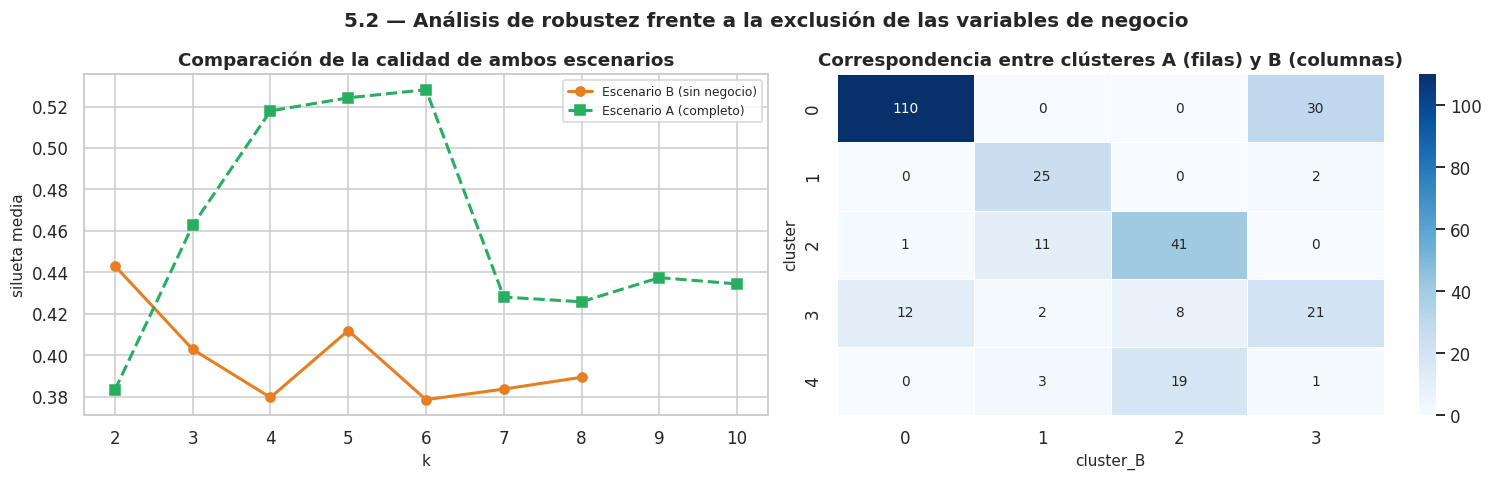

In [40]:
# =============================================================================
# 5.2 ESCENARIO B — CLÚSTERING SIN LAS VARIABLES DE NEGOCIO
# =============================================================================
VARS_B = ["log_gasto_total", "n_unidades", "n_productos", "gasto_medio_ud", "n_locales"]
Z_B = StandardScaler().fit_transform(clientes_t[VARS_B])

sil_B = [silhouette_score(Z_B, KMeans(k, n_init=50, random_state=SEMILLA).fit_predict(Z_B))
         for k in range(2, 9)]
print("Silueta del escenario B (sin variables de negocio):")
for k, s in zip(range(2, 9), sil_B):
    print(f"   k={k}: {s:.4f}")
print(f"\nMáxima silueta escenario B : {max(sil_B):.4f}")
print(f"Silueta escenario A (k={K_KMEANS}) : {silhouette_score(Z_std, modelo_final.labels_):.4f}")

k_B = 4
lab_B = KMeans(k_B, n_init=50, random_state=SEMILLA).fit_predict(Z_B)
clientes_t["cluster_B"] = lab_B
perfil_B = clientes_t.groupby("cluster_B")[VARS_B + ["gasto_total", "pct_L1", "pct_L2", "pct_L3", "pct_L4"]].mean()
perfil_B.insert(0, "n", clientes_t.groupby("cluster_B").size())
print(f"\nPerfil del escenario B (k={k_B}):")
display(perfil_B.style.format("{:.2f}").background_gradient(cmap="Blues",
        subset=["pct_L1", "pct_L2", "pct_L3", "pct_L4"]))

print(f"Concordancia entre el escenario A y el B (ARI): "
      f"{adjusted_rand_score(modelo_final.labels_, lab_B):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
axes[0].plot(range(2, 9), sil_B, "o-", color="#e67e22", lw=2, label="Escenario B (sin negocio)")
axes[0].plot(range(2, K_MAX + 1), diag_km["A · Original estandarizado"]["siluetas"],
             "s--", color="#27ae60", lw=2, label="Escenario A (completo)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("silueta media")
axes[0].set_title("Comparación de la calidad de ambos escenarios"); axes[0].legend(fontsize=8)
sns.heatmap(pd.crosstab(clientes_t.cluster, clientes_t.cluster_B), annot=True, fmt="d",
            cmap="Blues", ax=axes[1], linewidths=.5)
axes[1].set_title("Correspondencia entre clústeres A (filas) y B (columnas)")
fig.suptitle("5.2 — Análisis de robustez frente a la exclusión de las variables de negocio",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

### Interpretación del análisis de robustez

**Sin las variables de negocio la estructura se degrada de forma clara**: la silueta máxima del escenario B queda notablemente por debajo de la del escenario A. Esto confirma que **el negocio de referencia es el eje estructural dominante** de la segmentación de este recinto. No es un defecto del método: es la descripción fiel de una realidad —en "40 Pies" el tipo de cliente y el negocio que visita son casi la misma cosa, porque los clientes no circulan.

Ahora bien, el escenario B **no** reproduce simplemente los negocios: la tabla de correspondencia muestra que los cuatro grupos que emergen se organizan por **nivel e intensidad de consumo** (ticket mínimo, ticket alto multiproducto, ticket caro de pocas unidades, ticket medio de muchas unidades baratas), y cada uno reparte su composición entre varios negocios. Es decir, existe una **segunda dimensión real de segmentación** —cuánto y de qué gama consume el cliente— que es independiente de dónde compra.

La conclusión metodológica es que la segmentación del escenario A **combina ambas dimensiones**: el eje "dónde" (negocio ancla) y el eje "cuánto/qué gama" (intensidad). Se comprueba en el propio perfil final: los clústeres 1 y 2 comparten un peso similar en la facturación pero por caminos opuestos —el 1 por volumen (11 unidades a 4,9 €), el 2 por gama (3 unidades a 10,1 €)—. Esa distinción no se deduce del local de compra, y es precisamente la que da valor comercial a la segmentación.

## 5.3. Conclusiones

INDICADORES CLAVE DEL RECINTO '40 PIES'  (12 jornadas, 22/05 – 20/06/2026)
Visitas de grupo analizadas .................. 286
Facturación total ........................... 5,450.70 €
Ticket medio / mediano ...................... 19.06 € / 11.40 €
Unidades por visita (media) ................. 3.87
------------------------------------------------------------------------------
Grupos que visitan UN SOLO negocio ........... 234 (81.8%)
Grupos que visitan MÁS DE UN negocio ......... 52 (18.2%)
   Ticket medio de un solo negocio ........... 14.31 €
   Ticket medio multi-negocio ................ 40.42 €
   >>> FACTOR MULTIPLICADOR .................. x2.82
------------------------------------------------------------------------------
Contraste Kruskal-Wallis (multi vs. mono negocio): H = 63.52, p = 1.59e-15
------------------------------------------------------------------------------
El 20 % de grupos de mayor gasto aporta el 53.5 % de la facturación


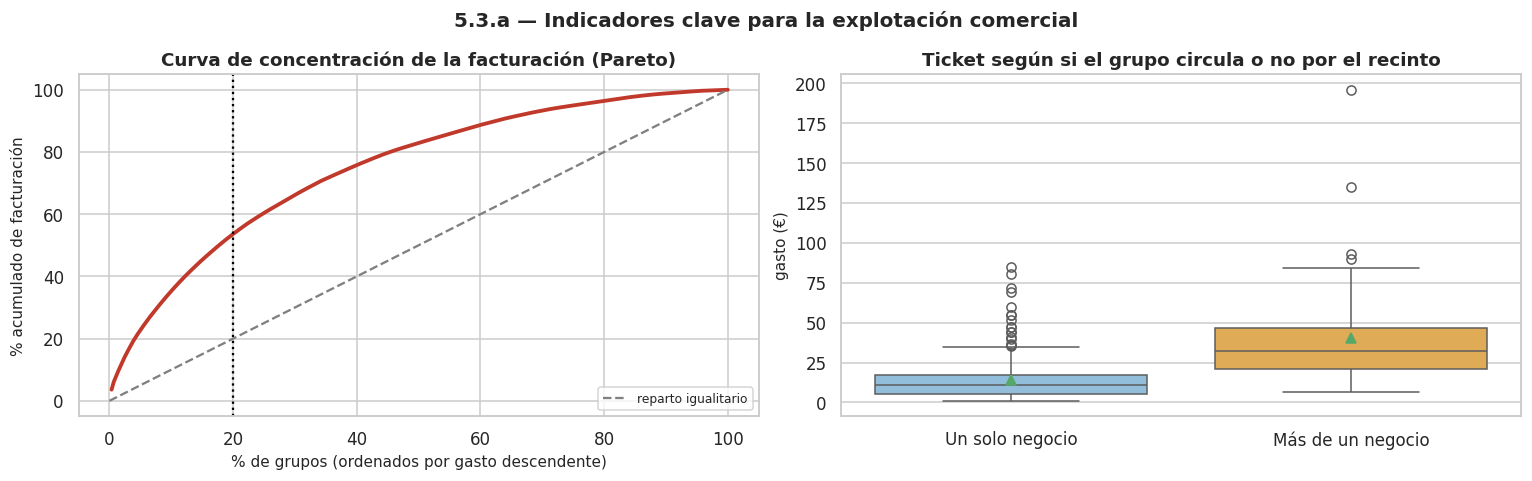

In [41]:
# =============================================================================
# 5.3.a INDICADORES FINALES DE NEGOCIO
# =============================================================================
# Todos los indicadores de negocio se calculan sobre 'clientes' (importes REALES de caja)
multi = clientes.n_locales > 1
print("=" * 78)
print("INDICADORES CLAVE DEL RECINTO '40 PIES'  (12 jornadas, 22/05 – 20/06/2026)")
print("=" * 78)
print(f"Visitas de grupo analizadas .................. {len(clientes)}")
print(f"Facturación total ........................... {clientes.gasto_total.sum():,.2f} €")
print(f"Ticket medio / mediano ...................... {clientes.gasto_total.mean():.2f} € / {clientes.gasto_total.median():.2f} €")
print(f"Unidades por visita (media) ................. {clientes.n_unidades.mean():.2f}")
print("-" * 78)
print(f"Grupos que visitan UN SOLO negocio ........... {(~multi).sum()} ({(~multi).mean():.1%})")
print(f"Grupos que visitan MÁS DE UN negocio ......... {multi.sum()} ({multi.mean():.1%})")
print(f"   Ticket medio de un solo negocio ........... {clientes.loc[~multi,'gasto_total'].mean():.2f} €")
print(f"   Ticket medio multi-negocio ................ {clientes.loc[multi,'gasto_total'].mean():.2f} €")
print(f"   >>> FACTOR MULTIPLICADOR .................. x{clientes.loc[multi,'gasto_total'].mean()/clientes.loc[~multi,'gasto_total'].mean():.2f}")
print("-" * 78)
H, p = kruskal(clientes.loc[multi, "gasto_total"], clientes.loc[~multi, "gasto_total"])
print(f"Contraste Kruskal-Wallis (multi vs. mono negocio): H = {H:.2f}, p = {p:.2e}")
print("-" * 78)
top20 = clientes.nlargest(int(len(clientes) * .20), "gasto_total")
print(f"El 20 % de grupos de mayor gasto aporta el {100*top20.gasto_total.sum()/clientes.gasto_total.sum():.1f} % de la facturación")
print("=" * 78)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
orden = np.sort(clientes.gasto_total.values)[::-1]
axes[0].plot(100 * np.arange(1, len(orden) + 1) / len(orden),
             100 * np.cumsum(orden) / orden.sum(), lw=2.5, color="#c0392b")
axes[0].plot([0, 100], [0, 100], "--", color="grey", label="reparto igualitario")
axes[0].axvline(20, ls=":", color="black")
axes[0].set_xlabel("% de grupos (ordenados por gasto descendente)")
axes[0].set_ylabel("% acumulado de facturación")
axes[0].set_title("Curva de concentración de la facturación (Pareto)"); axes[0].legend(fontsize=8)
sns.boxplot(data=clientes.assign(tipo=np.where(multi, "Más de un negocio", "Un solo negocio")),
            x="tipo", y="gasto_total", ax=axes[1], palette=["#85c1e9", "#f5b041"], showmeans=True)
axes[1].set_title("Ticket según si el grupo circula o no por el recinto")
axes[1].set_xlabel(""); axes[1].set_ylabel("gasto (€)")
fig.suptitle("5.3.a — Indicadores clave para la explotación comercial",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

In [42]:
# =============================================================================
# 5.3.b EXPORTACIÓN DE RESULTADOS
# =============================================================================
clientes["cluster_B"] = clientes_t["cluster_B"]        # se traslada la etiqueta del escenario B
COLS_EXPORT = (["cluster", "dia", "fecha", "dia_semana"] +
               [c for c in VARS_PERFIL] + ["cluster_B"])
salida = clientes[COLS_EXPORT].copy()                  # euros reales, sin winsorizar
salida.index.name = "id_grupo"

with pd.ExcelWriter("Resultados_Clustering_TFM.xlsx", engine="openpyxl") as w:
    salida.to_excel(w, sheet_name="Clientes_segmentados")
    perfil.to_excel(w, sheet_name="Perfil_clusteres")
    tabla_comp.to_excel(w, sheet_name="Comparativa_algoritmos", index=False)
    tabla_pca.to_excel(w, sheet_name="PCA_varianza")
    decisiones.to_excel(w, sheet_name="Seleccion_variables", index=False)
    est.to_excel(w, sheet_name="Estabilidad_bootstrap", index=False)

print("Fichero 'Resultados_Clustering_TFM.xlsx' generado con 6 hojas:")
print("   Clientes_segmentados | Perfil_clusteres | Comparativa_algoritmos")
print("   PCA_varianza | Seleccion_variables | Estabilidad_bootstrap")
display(salida.head(10))

Fichero 'Resultados_Clustering_TFM.xlsx' generado con 6 hojas:
   Clientes_segmentados | Perfil_clusteres | Comparativa_algoritmos
   PCA_varianza | Seleccion_variables | Estabilidad_bootstrap


,cluster,dia,fecha,dia_semana,gasto_total,n_unidades,n_productos,n_locales,gasto_medio_ud,pct_L1,pct_L2,pct_L3,pct_L4,pct_entrante,pct_comida,pct_postre,cluster_B
id_grupo,,,,,,,,,,,,,,,,,
714,0,12,2026-06-20,Sábado,27.5,5,1,1,5.500000,1.0,0.0,0.0,0.0,0.000000,0.000000,1.0,3
715,0,12,2026-06-20,Sábado,3.0,2,1,1,1.500000,1.0,0.0,0.0,0.0,0.000000,0.000000,1.0,0
716,0,12,2026-06-20,Sábado,1.5,1,1,1,1.500000,1.0,0.0,0.0,0.0,0.000000,0.000000,1.0,0
717,0,12,2026-06-20,Sábado,11.6,6,2,1,1.933333,1.0,0.0,0.0,0.0,0.000000,0.000000,1.0,3
718,0,12,2026-06-20,Sábado,2.8,1,1,1,2.800000,1.0,0.0,0.0,0.0,0.000000,0.000000,1.0,0
719,3,12,2026-06-20,Sábado,6.0,1,1,1,6.000000,0.0,1.0,0.0,0.0,0.000000,1.000000,0.0,0
720,3,12,2026-06-20,Sábado,11.5,3,3,1,3.833333,0.0,1.0,0.0,0.0,0.478261,0.521739,0.0,3
721,3,12,2026-06-20,Sábado,24.3,6,4,1,4.050000,0.0,1.0,0.0,0.0,0.506173,0.493827,0.0,3
722,3,12,2026-06-20,Sábado,17.0,3,2,1,5.666667,0.0,1.0,0.0,0.0,0.294118,0.705882,0.0,3


### 5.3.1. Elección del algoritmo

**Se selecciona K-Means con $k = 5$.** La decisión se apoya en cuatro argumentos, ordenados por peso:

1. **Calidad métrica.** Entre los algoritmos que segmentan el 100 % de las observaciones, K-Means alcanza la mejor combinación de silueta, Calinski-Harabasz y Davies-Bouldin, empatado en la práctica con HAC-Ward.
2. **Estabilidad.** Es la solución que mejor se reproduce ante remuestreo bootstrap ($ARI \approx 0{,}97$), muy por encima de las soluciones con $k \geq 6$. En un conjunto de 286 observaciones, la estabilidad no es un lujo: es la garantía de que la segmentación no se desmonta al añadir un mes más de datos.
3. **Interpretabilidad.** Los cinco centroides son directamente legibles como perfiles de cliente, y cada uno admite una acción comercial distinta.
4. **Operatividad.** K-Means proporciona centroides explícitos, lo que permite **clasificar un ticket nuevo en tiempo real** sin reentrenar el modelo —basta calcular a qué centroide está más próximo—. Ni HAC ni DBSCAN ofrecen esa capacidad de forma nativa, lo que es determinante si el modelo va a integrarse en el cuadro de mando de Power BI del proyecto.

**Por qué se descartan los otros tres:**

- **HAC-Ward** produce una partición prácticamente equivalente ($ARI \approx 0{,}89$ con K-Means) y su dendrograma ha sido muy valioso como herramienta de diagnóstico para confirmar el número de grupos. Pero no genera centroides, escala mal ($O(n^3)$ en tiempo, $O(n^2)$ en memoria) y su resultado depende críticamente del criterio de enlace, como demostró el caso del enlace `average`.
- **GMM** obtiene la peor silueta. Sus supuestos —normalidad de las variables— se incumplen de forma manifiesta (sección 2.1), y el BIC no converge por la abundancia de puntos duplicados. Su aportación se limita a la medida de incertidumbre de la asignación.
- **DBSCAN** exhibe la silueta más alta, pero de forma **no comparable**: la calcula tras excluir cerca del 10 % de observaciones como ruido. Además, su `eps` no se pudo fijar por el método de la rodilla —que devolvía un único clúster— y requirió ajuste manual, y deja grupos sin segmentar, lo que es inaceptable para una segmentación comercial. **Sí se recomienda conservarlo como detector de clientes atípicos de alto valor**, uso para el que resulta claramente superior a los demás.

### 5.3.2. Elección del conjunto de datos: original frente a PCA

**Se selecciona el conjunto original estandarizado (DATASET A).** El motivo es concluyente: aplicando K-Means con $k=5$, **ambos conjuntos producen exactamente la misma partición** ($ARI = 1{,}000$; las 286 visitas quedan idénticamente asignadas). Cuando dos alternativas dan el mismo resultado, la elección debe hacerse por criterios secundarios, y todos favorecen al original:

- **Interpretabilidad.** El centroide del clúster 2 sobre el dataset A dice "gasta el 91 % en la hamburguesería, 10,10 € por unidad". Sobre el dataset B dice "PC1 = −0,42, PC2 = +1,87". La primera versión se puede llevar a una reunión con el gestor del local; la segunda no.
- **Ausencia de ganancia real.** La reducción es de 9 a 5 variables. Con 286 observaciones no hay ningún problema computacional que resolver, y la maldición de la dimensionalidad no opera a esta escala.
- **Trazabilidad.** Mantener las variables originales permite auditar por qué un grupo concreto cae en un clúster y no en otro, algo imprescindible en un trabajo académico.

**Esto no invalida el PCA como herramienta**, y conviene dejarlo claro: ha sido decisivo para *diagnosticar* los datos —detectó la restricción composicional devolviendo una componente de varianza nula, y su biplot permitió interpretar los ejes de variación del negocio—. Su valor aquí ha sido explicativo, no operativo. En un escenario con muchas más variables (por ejemplo, una columna por cada uno de los 46 productos del catálogo) la conclusión sería probablemente la contraria.

### 5.3.3. Conclusiones de negocio y recomendaciones

Traduciendo los cinco perfiles a decisiones concretas para el recinto:

**1. El hallazgo más rentable: hacer circular a los clientes.** Los grupos que compran en más de un negocio gastan **2,8 veces más** que los que se quedan en uno solo (40,42 € frente a 14,31 € de media), diferencia altamente significativa (Kruskal-Wallis, $p < 10^{-14}$). Y sólo el 18 % de los grupos circula. Elevar ese porcentaje es, con diferencia, la palanca de mayor impacto disponible, y no requiere captar un solo cliente nuevo. La propuesta del TFM ya apuntaba en esa dirección; los datos ahora la cuantifican y permiten dimensionar el retorno esperado. La recompensa que la propuesta contemplaba (un refresco gratis por cada 20 € de compra) debería condicionarse a **compras en negocios distintos**, no al importe total, para atacar exactamente esta métrica.

**2. El clúster 0 es el gran depósito de potencial.** El 49 % de las visitas son clientes que sólo toman un helado, con un ticket mediano de unos 6 €. Convertir siquiera un 10 % de ese segmento en consumo de restauración tendría un efecto mayor que aumentar la afluencia total. La hipótesis de la propuesta —"muchos jóvenes que no cenan"— queda validada. La acción coherente es una **oferta puente de precio bajo** que enlace la heladería con los negocios de comida, y aquí la ausencia de la Tetería en los datos es especialmente lamentable, porque es el negocio naturalmente mejor situado para ese papel.

**3. Los clústeres 1 y 2 sostienen el negocio por vías opuestas.** Aportan un 27,8 % y un 28,5 % de la facturación respectivamente —juntos, más de la mitad—, pero por caminos contrarios: el clúster 1 por **volumen** (11,4 unidades a 4,88 €/ud) y el clúster 2 por **gama** (3,0 unidades a 10,10 €/ud). Requieren por tanto tratamientos distintos: al clúster 1 le sirven mesas grandes, disponibilidad de sitio y ofertas por volumen; al clúster 2, producto premium y rotación. Es una distinción que la contabilidad agregada del recinto no revela y que la segmentación hace visible.

**4. Los datos que faltan valen más que los que hay.** Las tres limitaciones de la sección 1.1 —ausencia del tamaño del grupo, ausencia de la hora de entrada y ausencia total de la Tetería— impiden responder a preguntas que el propio negocio se hacía. Sin el tamaño del grupo no se puede calcular el gasto por comensal, que era uno de los objetivos explícitos de la propuesta ("si el grupo pequeño gasta más por persona, no conviene juntar mesas"). **Registrar esos dos campos en la puerta no cuesta prácticamente nada y multiplicaría el valor analítico del sistema de corchos.**

### 5.3.4. Limitaciones del estudio

Por rigor, conviene explicitar las cinco limitaciones que acotan el alcance de estas conclusiones:

1. **Tamaño muestral reducido**: 286 visitas en 12 jornadas. Suficiente para una segmentación exploratoria, insuficiente para estimaciones de precisión o para segmentos minoritarios (el clúster 4 tiene apenas 23 observaciones).
2. **No hay identidad de cliente entre jornadas.** Lo que se ha segmentado son **visitas**, no personas. No es posible aplicar RFM ni medir fidelización, y un mismo cliente que acude varias veces aparece como varias observaciones independientes.
3. **Cobertura incompleta del recinto.** La Tetería no registra ventas y no existe la categoría `Bebida`. Como la bebida suele ser el producto de mayor margen en hostelería, las conclusiones sobre rentabilidad relativa entre negocios deben tomarse con cautela.
4. **Pérdida de registro del 31/05** (24 grupos declarados sin venta asociada), que sesga a la baja la representación del domingo.
5. **Periodo corto y estacionalmente homogéneo**: cuatro semanas de finales de primavera. No es posible extrapolar a temporada alta de verano, a invierno ni a festivos señalados.

### 5.3.5. Líneas de trabajo futuras

- **Registrar tamaño de grupo y hora de entrada**, que permitirían calcular el gasto por comensal y segmentar además por franja horaria (los perfiles de tarde y de noche son con toda seguridad distintos).
- **Enlazar esta segmentación con el estudio de asociatividad** del otro bloque del TFM: calcular las reglas de asociación *dentro de cada clúster* daría recomendaciones de producto específicas por perfil, mucho más precisas que las globales.
- **Desplegar el modelo en el cuadro de mando de Power BI**: los centroides de K-Means permiten clasificar cada ticket en tiempo real y mostrar al gestor la composición de clientes de la jornada en curso.
- **Reevaluar con una muestra mayor** —idealmente un año completo— incorporando entonces variables de contexto y contrastando si los cinco perfiles se mantienen.

---

*Fin del bloque de clústering — TFM Máster en Big Data y Ciencia de Datos, VIU · Jesús Ferrández Bernabeu*